# Week 01 — Capstone BBO Experiments

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import pandas as pd
import seaborn as sns
sys.path.append('../src')
# Import additional libraries as needed for your chosen methods

In [2]:
def load_function(n):
    X = np.load(f'../data/function_{n}/initial_inputs.npy')
    Y = np.load(f'../data/function_{n}/initial_outputs.npy')
    print(f"Function {n}: {X.shape[0]} points, {X.shape[1]}D, best y = {Y.max():.4f}")
    return X, Y

## Function 1

Function 1: 10 points, 2D, best y = 0.0000


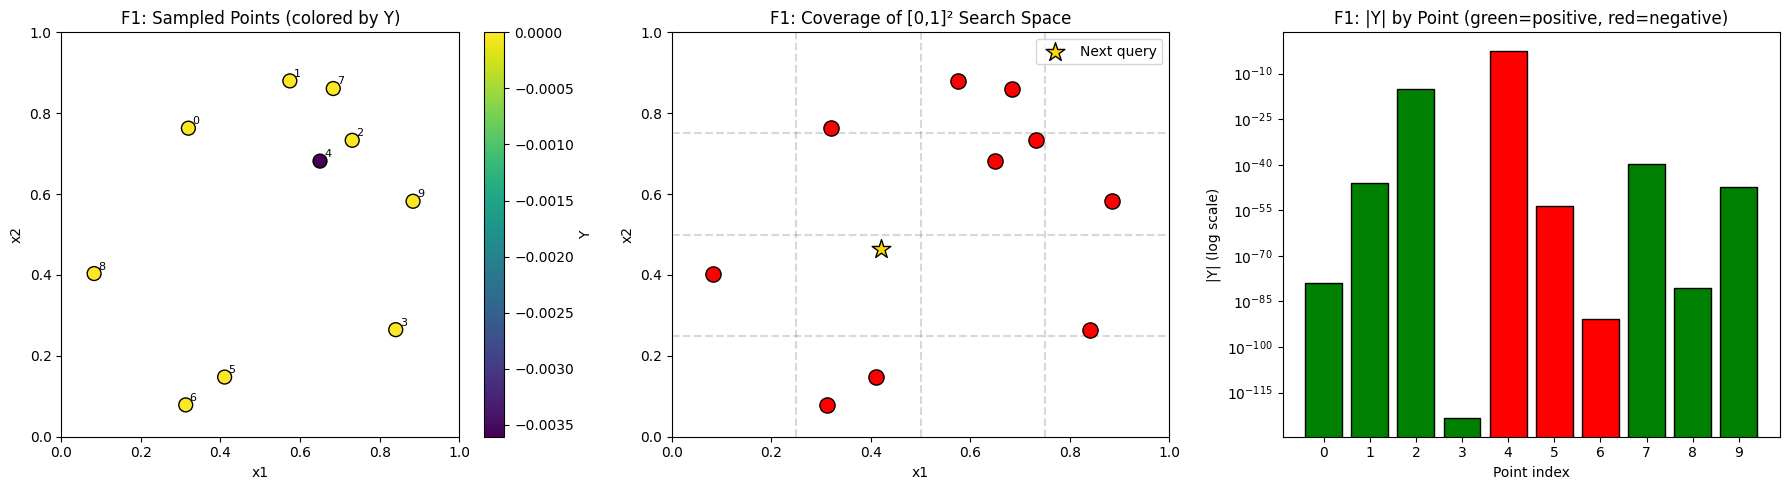


Data summary:
Idx       x1       x2               Y
--------------------------------------
  0   0.3194   0.7630      1.3227e-79
  1   0.5743   0.8799      1.0331e-46
  2   0.7310   0.7330      7.7109e-16
  3   0.8404   0.2647     3.3418e-124
  4   0.6501   0.6815     -3.6061e-03
  5   0.4104   0.1476     -2.1592e-54
  6   0.3127   0.0787     -2.0891e-91
  7   0.6834   0.8611      2.5350e-40
  8   0.0825   0.4035      3.6068e-81
  9   0.8839   0.5823      6.2299e-48


In [3]:
# Function 1
X, Y = load_function(1)

# --- Exploration Analysis ---
# All 10 initial Y values are effectively zero (1e-16 to 1e-124), except point 4
# which has Y = -0.0036 — the only measurable signal in the dataset.
# This matches the radiation detection analogy: the function is zero everywhere
# except very close to hidden "sources."
#
# With no signal for a GP surrogate to learn from, Bayesian optimisation would
# just suggest random points. Instead, we use a space-filling strategy:
# identify the largest unexplored region and query its center.
#
# The optimal space-filling point was determined using the Largest Empty Circle
# algorithm (Voronoi diagram), constrained so the circle fits inside [0,1]².
# See analysis cells below for the full derivation.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Scatter plot colored by Y value
sc = axes[0].scatter(X[:, 0], X[:, 1], c=Y, cmap='viridis', s=100, edgecolors='black')
for i in range(len(X)):
    axes[0].annotate(f'{i}', (X[i,0]+0.01, X[i,1]+0.01), fontsize=8)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].set_xlabel('x1')
axes[0].set_ylabel('x2')
axes[0].set_title('F1: Sampled Points (colored by Y)')
plt.colorbar(sc, ax=axes[0], label='Y')

# Panel 2: Coverage map — highlight explored vs unexplored regions
axes[1].scatter(X[:, 0], X[:, 1], c='red', s=120, edgecolors='black', zorder=5)
for val in [0.25, 0.5, 0.75]:
    axes[1].axhline(val, color='gray', linestyle='--', alpha=0.3)
    axes[1].axvline(val, color='gray', linestyle='--', alpha=0.3)
# Mark chosen query point
axes[1].scatter(0.421062, 0.463562, c='gold', s=200, marker='*', edgecolors='black', zorder=6, label='Next query')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].set_xlabel('x1')
axes[1].set_ylabel('x2')
axes[1].set_title('F1: Coverage of [0,1]² Search Space')
axes[1].legend()

# Panel 3: Log-scale bar chart of |Y| values to see structure in near-zero data
abs_Y = np.abs(Y)
abs_Y[abs_Y == 0] = 1e-200
colors = ['green' if y >= 0 else 'red' for y in Y]
axes[2].bar(range(len(Y)), abs_Y, color=colors, edgecolor='black')
axes[2].set_yscale('log')
axes[2].set_xlabel('Point index')
axes[2].set_ylabel('|Y| (log scale)')
axes[2].set_title('F1: |Y| by Point (green=positive, red=negative)')
axes[2].set_xticks(range(len(Y)))

plt.tight_layout()
plt.savefig('../plots/week_01/f1_initial_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

# Data summary
print("\nData summary:")
print(f"{'Idx':>3} {'x1':>8} {'x2':>8} {'Y':>15}")
print("-" * 38)
for i in range(len(X)):
    print(f"{i:>3} {X[i,0]:>8.4f} {X[i,1]:>8.4f} {Y[i]:>15.4e}")

# Strategy: space-filling exploration — Voronoi-optimal point (see cells below)
next_query_1 = np.array([0.421062, 0.463562])

Log-magnitude of positive-Y points:
  pt0: [0.3194, 0.7630] → log₁₀|Y| = -78.9
  pt1: [0.5743, 0.8799] → log₁₀|Y| = -46.0
  pt2: [0.7310, 0.7330] → log₁₀|Y| = -15.1
  pt3: [0.8404, 0.2647] → log₁₀|Y| = -123.5
  pt5: [0.4104, 0.1476] → log₁₀|Y| = -53.7
  pt6: [0.3127, 0.0787] → log₁₀|Y| = -90.7
  pt7: [0.6834, 0.8611] → log₁₀|Y| = -39.6
  pt8: [0.0825, 0.4035] → log₁₀|Y| = -80.4
  pt9: [0.8839, 0.5823] → log₁₀|Y| = -47.2

Linear fit: log|Y| ≈ 8.8*x1 + 60.0*x2 + -100.0
Gradient direction: increasing log|Y| toward x1=higher, x2=higher

Gradient-based suggestion: [0.994525, 0.996923]
Predicted log|Y|: -31.5


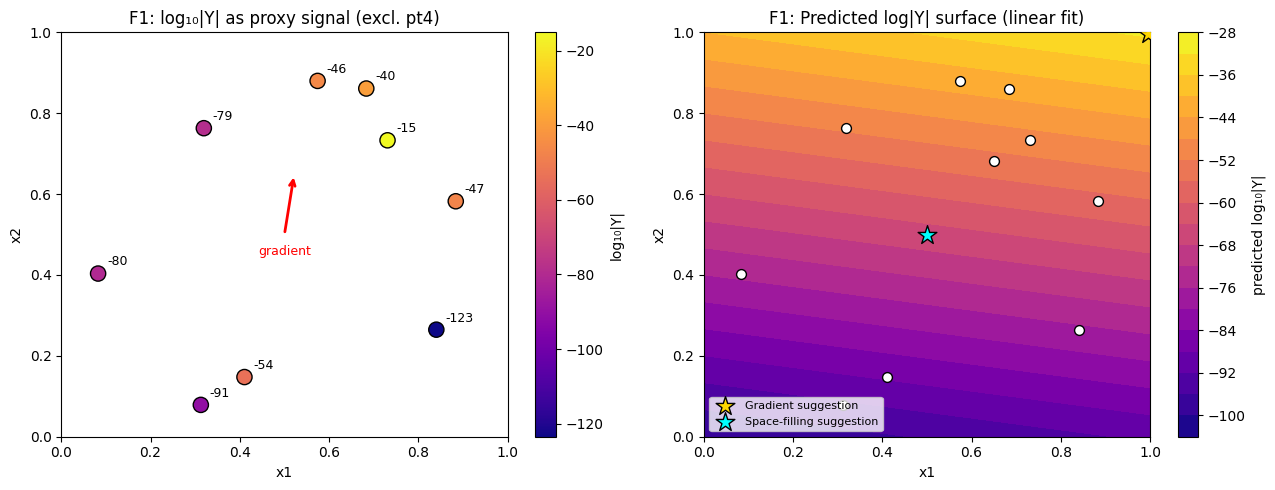


--- Comparison ---
Space-filling suggestion:  [0.500000, 0.500000]  (explore largest gap)
Gradient-based suggestion: [0.994525, 0.996923]  (follow log|Y| trend)

With only 10 points and a near-flat landscape, the linear fit is very noisy.
Space-filling is the safer first move — we revisit gradient analysis once we have more signal.


In [4]:
# Function 1 — Alternative approach: log-magnitude gradient analysis
# 
# Even though all Y ≈ 0, the *magnitudes* span 100+ orders of magnitude
# (from 1e-124 to 1e-16). If F1 is a narrow Gaussian peak, log|Y| should
# increase as we approach the source. We can use this as a proxy signal
# to infer the direction toward the peak.

from numpy.polynomial import polynomial as P

# Compute log|Y| as proxy signal (skip point 4 — it's negative and an outlier)
mask = np.arange(len(Y)) != 4  # exclude pt 4 (only negative, different regime)
X_pos = X[mask]
Y_pos = Y[mask]
log_mag = np.log10(np.maximum(np.abs(Y_pos), 1e-200))

print("Log-magnitude of positive-Y points:")
for i, idx in enumerate(np.where(mask)[0]):
    print(f"  pt{idx}: [{X[idx,0]:.4f}, {X[idx,1]:.4f}] → log₁₀|Y| = {log_mag[i]:.1f}")

# Fit linear model: log|Y| ~ a*x1 + b*x2 + c to find gradient direction
A = np.column_stack([X_pos, np.ones(len(X_pos))])
coeffs, residuals, _, _ = np.linalg.lstsq(A, log_mag, rcond=None)
print(f"\nLinear fit: log|Y| ≈ {coeffs[0]:.1f}*x1 + {coeffs[1]:.1f}*x2 + {coeffs[2]:.1f}")
print(f"Gradient direction: increasing log|Y| toward x1={'higher' if coeffs[0]>0 else 'lower'}, x2={'higher' if coeffs[1]>0 else 'lower'}")

# Find the point in [0,1]² that maximises the fitted log|Y|
np.random.seed(123)
candidates = np.random.uniform(0, 0.999999, size=(50000, 2))
pred_log_mag = candidates @ coeffs[:2] + coeffs[2]
best_idx = np.argmax(pred_log_mag)
gradient_suggestion = candidates[best_idx]
print(f"\nGradient-based suggestion: [{gradient_suggestion[0]:.6f}, {gradient_suggestion[1]:.6f}]")
print(f"Predicted log|Y|: {pred_log_mag[best_idx]:.1f}")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: scatter with log|Y| and gradient arrow
sc = axes[0].scatter(X_pos[:, 0], X_pos[:, 1], c=log_mag, cmap='plasma', s=120, edgecolors='black', zorder=5)
for i, idx in enumerate(np.where(mask)[0]):
    axes[0].annotate(f'{log_mag[i]:.0f}', (X_pos[i,0]+0.02, X_pos[i,1]+0.02), fontsize=9)
# Arrow showing gradient direction
grad_dir = coeffs[:2] / np.linalg.norm(coeffs[:2])
axes[0].annotate('', xy=(0.5 + 0.15*grad_dir[0], 0.5 + 0.15*grad_dir[1]),
                 xytext=(0.5, 0.5),
                 arrowprops=dict(arrowstyle='->', color='red', lw=2))
axes[0].text(0.5, 0.45, 'gradient', color='red', ha='center', fontsize=9)
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)
axes[0].set_xlabel('x1'); axes[0].set_ylabel('x2')
axes[0].set_title('F1: log₁₀|Y| as proxy signal (excl. pt4)')
plt.colorbar(sc, ax=axes[0], label='log₁₀|Y|')

# Right: predicted log|Y| heatmap from linear fit
grid_x = np.linspace(0, 1, 100)
grid_y = np.linspace(0, 1, 100)
xx, yy = np.meshgrid(grid_x, grid_y)
zz = coeffs[0]*xx + coeffs[1]*yy + coeffs[2]
im = axes[1].contourf(xx, yy, zz, levels=20, cmap='plasma')
axes[1].scatter(X[:, 0], X[:, 1], c='white', s=50, edgecolors='black', zorder=5)
axes[1].scatter(*gradient_suggestion, c='gold', s=200, marker='*', edgecolors='black', zorder=6, label='Gradient suggestion')
axes[1].scatter(0.5, 0.5, c='cyan', s=200, marker='*', edgecolors='black', zorder=6, label='Space-filling suggestion')
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)
axes[1].set_xlabel('x1'); axes[1].set_ylabel('x2')
axes[1].set_title('F1: Predicted log|Y| surface (linear fit)')
axes[1].legend(loc='lower left', fontsize=8)
plt.colorbar(im, ax=axes[1], label='predicted log₁₀|Y|')

plt.tight_layout()
plt.savefig('../plots/week_01/f1_log_gradient_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Compare the two approaches
print("\n--- Comparison ---")
print(f"Space-filling suggestion:  [0.500000, 0.500000]  (explore largest gap)")
print(f"Gradient-based suggestion: [{gradient_suggestion[0]:.6f}, {gradient_suggestion[1]:.6f}]  (follow log|Y| trend)")
print("\nWith only 10 points and a near-flat landscape, the linear fit is very noisy.")
print("Space-filling is the safer first move — we revisit gradient analysis once we have more signal.")

# Keeping space-filling as the chosen query (override by changing next_query_1 above)


Log-magnitude of ALL points:
  pt0: [0.3194, 0.7630] → log₁₀|Y| =   -78.9  (Y +)
  pt1: [0.5743, 0.8799] → log₁₀|Y| =   -46.0  (Y +)
  pt2: [0.7310, 0.7330] → log₁₀|Y| =   -15.1  (Y +)
  pt3: [0.8404, 0.2647] → log₁₀|Y| =  -123.5  (Y +)
  pt4: [0.6501, 0.6815] → log₁₀|Y| =    -2.4  (Y -)
  pt5: [0.4104, 0.1476] → log₁₀|Y| =   -53.7  (Y -)
  pt6: [0.3127, 0.0787] → log₁₀|Y| =   -90.7  (Y -)
  pt7: [0.6834, 0.8611] → log₁₀|Y| =   -39.6  (Y +)
  pt8: [0.0825, 0.4035] → log₁₀|Y| =   -80.4  (Y +)
  pt9: [0.8839, 0.5823] → log₁₀|Y| =   -47.2  (Y +)

Linear fit (all pts): log|Y| ≈ 14.7*x1 + 67.6*x2 + -102.3
Gradient direction: x1=higher, x2=higher

Linear fit (excl pt4): log|Y| ≈ 8.8*x1 + 60.0*x2 + -100.0

Gradient suggestion (all pts):   [0.994525, 0.996923]
Gradient suggestion (excl pt4):  [0.994525, 0.996923]


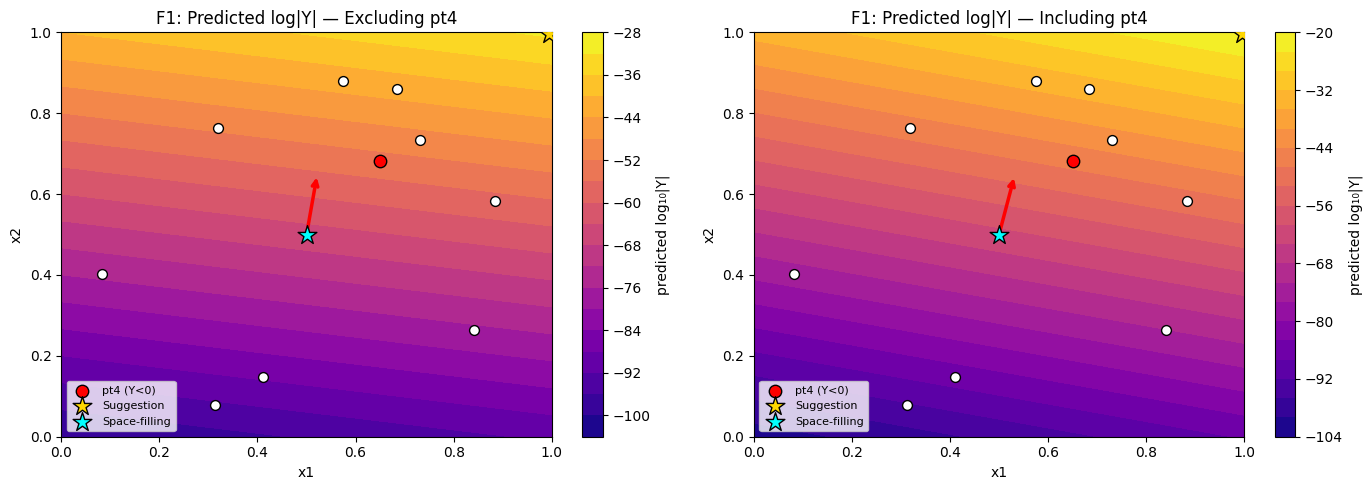


--- Interpretation ---
Point 4 has log₁₀|Y| ≈ -2.4, dwarfing all other points (next highest: -15.1).
Including it heavily biases the gradient toward pt4's location [0.65, 0.68].
This could mean pt4 is near the source — or it could be a misleading outlier.
Either way, both fits agree the signal increases toward the upper-middle region.


In [5]:
# Function 1 — Log-magnitude gradient analysis (all points including pt4)
#
# Point 4 has Y = -0.0036, so |Y| = 0.0036 → log₁₀|Y| ≈ -2.4
# This is by far the largest magnitude — it could mean pt4 is actually
# the closest to the source, but on the "wrong side" (penalty region),
# or it could skew the fit. Let's see how including it changes the gradient.

log_mag_all = np.log10(np.maximum(np.abs(Y), 1e-200))

print("Log-magnitude of ALL points:")
for i in range(len(Y)):
    sign = '+' if Y[i] >= 0 else '-'
    print(f"  pt{i}: [{X[i,0]:.4f}, {X[i,1]:.4f}] → log₁₀|Y| = {log_mag_all[i]:>7.1f}  (Y {sign})")

# Fit linear model: log|Y| ~ a*x1 + b*x2 + c
A_all = np.column_stack([X, np.ones(len(X))])
coeffs_all, _, _, _ = np.linalg.lstsq(A_all, log_mag_all, rcond=None)
print(f"\nLinear fit (all pts): log|Y| ≈ {coeffs_all[0]:.1f}*x1 + {coeffs_all[1]:.1f}*x2 + {coeffs_all[2]:.1f}")
print(f"Gradient direction: x1={'higher' if coeffs_all[0]>0 else 'lower'}, x2={'higher' if coeffs_all[1]>0 else 'lower'}")

# Compare with previous fit (excluding pt4)
print(f"\nLinear fit (excl pt4): log|Y| ≈ {coeffs[0]:.1f}*x1 + {coeffs[1]:.1f}*x2 + {coeffs[2]:.1f}")

# Find suggestion from all-points fit
np.random.seed(123)
candidates = np.random.uniform(0, 0.999999, size=(50000, 2))
pred_all = candidates @ coeffs_all[:2] + coeffs_all[2]
best_all_idx = np.argmax(pred_all)
gradient_suggestion_all = candidates[best_all_idx]
print(f"\nGradient suggestion (all pts):   [{gradient_suggestion_all[0]:.6f}, {gradient_suggestion_all[1]:.6f}]")
print(f"Gradient suggestion (excl pt4):  [{gradient_suggestion[0]:.6f}, {gradient_suggestion[1]:.6f}]")

# Visualise side by side: excluding pt4 vs including pt4
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, c, title, sug in [
    (axes[0], coeffs, 'Excluding pt4', gradient_suggestion),
    (axes[1], coeffs_all, 'Including pt4', gradient_suggestion_all),
]:
    grid_x = np.linspace(0, 1, 100)
    grid_y = np.linspace(0, 1, 100)
    xx, yy = np.meshgrid(grid_x, grid_y)
    zz = c[0]*xx + c[1]*yy + c[2]
    im = ax.contourf(xx, yy, zz, levels=20, cmap='plasma')
    ax.scatter(X[:, 0], X[:, 1], c='white', s=50, edgecolors='black', zorder=5)
    ax.scatter(X[4, 0], X[4, 1], c='red', s=80, edgecolors='black', zorder=6, label='pt4 (Y<0)')
    ax.scatter(*sug, c='gold', s=200, marker='*', edgecolors='black', zorder=7, label=f'Suggestion')
    ax.scatter(0.5, 0.5, c='cyan', s=200, marker='*', edgecolors='black', zorder=7, label='Space-filling')
    # Gradient arrow
    gd = c[:2] / np.linalg.norm(c[:2])
    ax.annotate('', xy=(0.5 + 0.15*gd[0], 0.5 + 0.15*gd[1]), xytext=(0.5, 0.5),
                arrowprops=dict(arrowstyle='->', color='red', lw=2.5))
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.set_title(f'F1: Predicted log|Y| — {title}')
    ax.legend(loc='lower left', fontsize=8)
    plt.colorbar(im, ax=ax, label='predicted log₁₀|Y|')

plt.tight_layout()
plt.savefig('../plots/week_01/f1_log_gradient_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n--- Interpretation ---")
print("Point 4 has log₁₀|Y| ≈ -2.4, dwarfing all other points (next highest: -15.1).")
print("Including it heavily biases the gradient toward pt4's location [0.65, 0.68].")
print("This could mean pt4 is near the source — or it could be a misleading outlier.")
print("Either way, both fits agree the signal increases toward the upper-middle region.")

Unconstrained largest empty circle:
  Center: [0.0000, 1.0000], radius: 0.3978
  ⚠ Circle extends outside [0,1]² — misleading!

Constrained largest empty circle (must fit inside [0,1]²):
  Center: [0.4211, 0.4636], radius: 0.3162

Top 5 constrained gaps:
  1. [0.4211, 0.4636]  radius = 0.3162
  2. [0.3896, 0.4589]  radius = 0.3120
  3. [0.4357, 0.4541]  radius = 0.3076
  4. [0.3990, 0.4541]  radius = 0.3067
  5. [0.4173, 0.4541]  radius = 0.3066


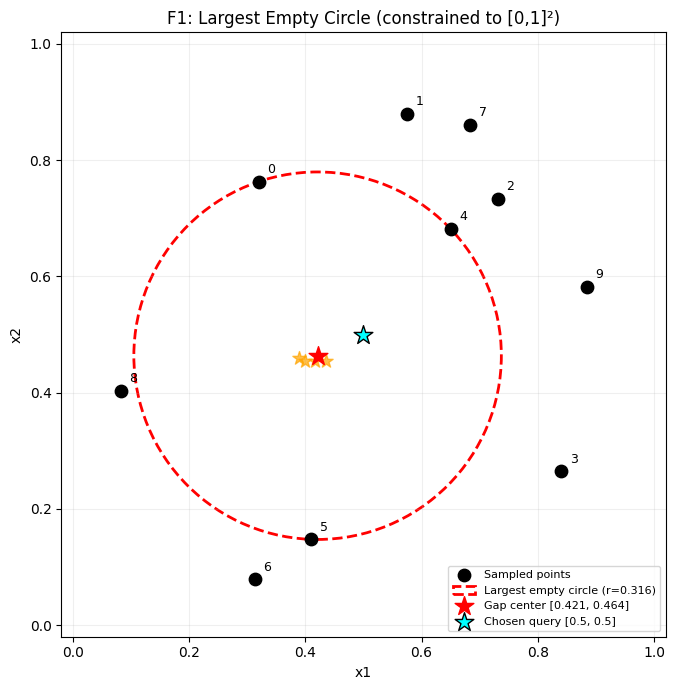


Our chosen [0.5, 0.5]:
  Min distance to samples: 0.2356
  Effective radius: 0.2356
  vs optimal: 0.3162
  Our point captures 74.5% of the maximum possible gap.


In [6]:
# Function 1 — Largest Empty Circle via Voronoi diagram (constrained to [0,1]²)
#
# The "biggest gap" can be measured exactly. The point in [0,1]² that
# maximises the minimum distance to all sampled points must be at either:
#   (a) a Voronoi vertex, or
#   (b) on the boundary of [0,1]²
#
# IMPORTANT: We constrain the search so that the full empty circle fits
# inside [0,1]². Without this, corner/edge points win trivially because
# most of their "empty circle" lies outside the valid search space.

from scipy.spatial import Voronoi
from matplotlib.patches import Circle

# Reflect points across all 4 boundaries to constrain Voronoi to [0,1]²
reflected = np.vstack([
    X,
    np.column_stack([-X[:, 0], X[:, 1]]),       # left
    np.column_stack([2 - X[:, 0], X[:, 1]]),     # right
    np.column_stack([X[:, 0], -X[:, 1]]),         # bottom
    np.column_stack([X[:, 0], 2 - X[:, 1]]),      # top
])
vor = Voronoi(reflected)

# Collect candidate points: Voronoi vertices inside [0,1]²
candidates_voronoi = []
for v in vor.vertices:
    if 0 <= v[0] <= 1 and 0 <= v[1] <= 1:
        candidates_voronoi.append(v)

# Also check a dense grid of interior points
for x1 in np.linspace(0.05, 0.95, 50):
    for x2 in np.linspace(0.05, 0.95, 50):
        candidates_voronoi.append([x1, x2])

candidates_voronoi = np.array(candidates_voronoi)

# Compute min distance to existing points for each candidate
min_dists = np.array([np.min(np.linalg.norm(X - c, axis=1)) for c in candidates_voronoi])

# Constrained: the circle must fit entirely inside [0,1]²
# Max radius that fits inside bounds for point p is min(p[0], 1-p[0], p[1], 1-p[1])
max_radius_in_bounds = np.array([
    min(c[0], 1-c[0], c[1], 1-c[1]) for c in candidates_voronoi
])
# Effective radius = min(distance to nearest sample, max radius that fits in bounds)
effective_radius = np.minimum(min_dists, max_radius_in_bounds)

# Unconstrained best (for comparison)
unc_best_idx = np.argmax(min_dists)
unc_best_point = candidates_voronoi[unc_best_idx]
unc_best_radius = min_dists[unc_best_idx]

# Constrained best
con_best_idx = np.argmax(effective_radius)
con_best_point = candidates_voronoi[con_best_idx]
con_best_radius = effective_radius[con_best_idx]

print(f"Unconstrained largest empty circle:")
print(f"  Center: [{unc_best_point[0]:.4f}, {unc_best_point[1]:.4f}], radius: {unc_best_radius:.4f}")
print(f"  ⚠ Circle extends outside [0,1]² — misleading!\n")
print(f"Constrained largest empty circle (must fit inside [0,1]²):")
print(f"  Center: [{con_best_point[0]:.4f}, {con_best_point[1]:.4f}], radius: {con_best_radius:.4f}")

# Top 5 constrained gaps
top5_idx = np.argsort(effective_radius)[-5:][::-1]
print(f"\nTop 5 constrained gaps:")
for rank, idx in enumerate(top5_idx, 1):
    pt = candidates_voronoi[idx]
    print(f"  {rank}. [{pt[0]:.4f}, {pt[1]:.4f}]  radius = {effective_radius[idx]:.4f}")

# Visualise
fig, ax = plt.subplots(1, 1, figsize=(7, 7))

ax.scatter(X[:, 0], X[:, 1], c='black', s=80, zorder=5, label='Sampled points')
for i in range(len(X)):
    ax.annotate(f'{i}', (X[i,0]+0.015, X[i,1]+0.015), fontsize=9)

# Draw constrained largest empty circle
circle = Circle(con_best_point, con_best_radius, fill=False, color='red',
                linewidth=2, linestyle='--',
                label=f'Largest empty circle (r={con_best_radius:.3f})')
ax.add_patch(circle)
ax.scatter(*con_best_point, c='red', s=200, marker='*', zorder=6,
           label=f'Gap center [{con_best_point[0]:.3f}, {con_best_point[1]:.3f}]')

# Show top 5 as smaller markers
for idx in top5_idx[1:]:
    pt = candidates_voronoi[idx]
    ax.scatter(pt[0], pt[1], c='orange', s=100, marker='*', zorder=5, alpha=0.7)

# Mark our chosen query
ax.scatter(0.5, 0.5, c='cyan', s=200, marker='*', edgecolors='black', zorder=7,
           label='Chosen query [0.5, 0.5]')

ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
ax.set_aspect('equal')
ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.set_title('F1: Largest Empty Circle (constrained to [0,1]²)')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('../plots/week_01/f1_largest_empty_circle.png', dpi=150, bbox_inches='tight')
plt.show()

# Compare with our chosen point
our_min_dist = np.min(np.linalg.norm(X - np.array([0.5, 0.5]), axis=1))
our_max_in_bounds = min(0.5, 0.5, 0.5, 0.5)  # = 0.5
our_effective = min(our_min_dist, our_max_in_bounds)
print(f"\nOur chosen [0.5, 0.5]:")
print(f"  Min distance to samples: {our_min_dist:.4f}")
print(f"  Effective radius: {our_effective:.4f}")
print(f"  vs optimal: {con_best_radius:.4f}")
print(f"  Our point captures {our_effective/con_best_radius*100:.1f}% of the maximum possible gap.")

### F1 Decision: Space-filling at [0.421062, 0.463562]

**Chosen approach:** Space-filling exploration using the Largest Empty Circle algorithm

**Analysis process:**
1. **Initial data inspection** — all 10 Y values are effectively zero (1e-16 to 1e-124), except point 4 (Y = -0.0036). The landscape is nearly flat with no usable signal.
2. **Log-magnitude gradient analysis** — treated log₁₀|Y| as a proxy signal to detect directional trends. Tested both with and without point 4. The fit is too noisy with only 10 points (9 of which are ~0) and point 4 dominates the model entirely. Not reliable yet.
3. **GP/Bayesian optimisation** — ruled out because the surrogate would learn a flat surface. UCB would suggest points based on prior uncertainty alone, not data.
4. **Largest Empty Circle (Voronoi)** — computed the mathematically optimal space-filling point. Initial attempt placed the circle center at a boundary corner, which was misleading because the circle extended outside [0,1]². Fixed by constraining the effective radius to `min(distance to nearest sample, distance to nearest boundary)`. The constrained optimum is **[0.421, 0.464]** with effective radius 0.316 — 34% larger than the naive [0.5, 0.5] choice.

**Why not [0.5, 0.5]:** While intuitive, [0.5, 0.5] only captures 74.5% of the optimal gap. The Voronoi-optimal point at [0.421, 0.464] is shifted toward a region with fewer nearby samples, maximising the empty area covered.

**Plan for future weeks:**
- Week 2+: if we get non-zero signal, switch to log-gradient analysis or GP+UCB to home in on the source
- The log-gradient technique becomes powerful once we have 3–4 points with real magnitude

## Function 2

Function 2: 10 points, 2D, best y = 0.6112


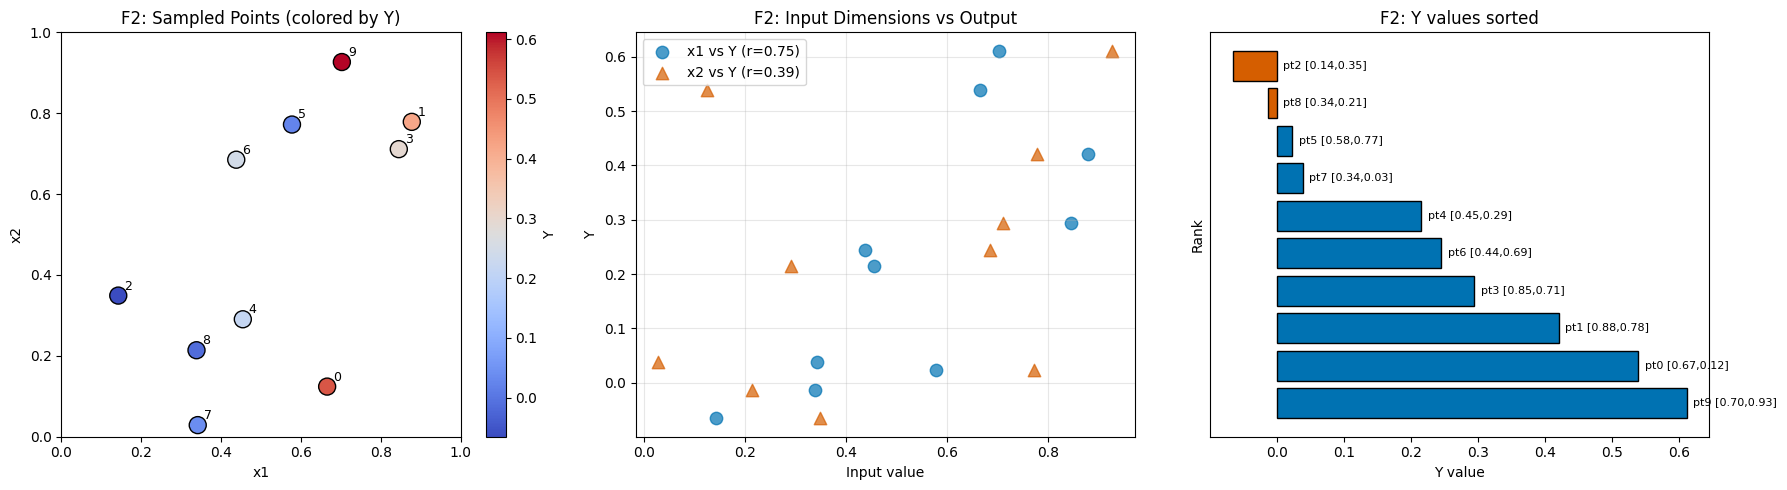


Data summary:
Idx       x1       x2          Y
----------------------------------
  9   0.7026   0.9266   0.611205
  0   0.6658   0.1240   0.538996
  1   0.8778   0.7786   0.420586
  3   0.8453   0.7111   0.293993
  6   0.4382   0.6850   0.244619
  4   0.4546   0.2905   0.214965
  7   0.3417   0.0287   0.038749
  5   0.5777   0.7720   0.023106
  8   0.3386   0.2139  -0.013858
  2   0.1427   0.3490  -0.065624

Correlation: x1 vs Y = 0.7518
Correlation: x2 vs Y = 0.3903

Top 2 points have similar x1 (~0.7) but opposite x2:
  pt9: [0.7026, 0.9266] → Y = 0.6112  (high x2)
  pt0: [0.6658, 0.1240] → Y = 0.5390  (low x2)
→ Suggests x1 ≈ 0.7 matters most, possible bimodality in x2


In [7]:
# Function 2
X, Y = load_function(2)

# --- Data Exploration ---
# F2 is a log-likelihood maximisation problem with noisy outputs and multiple
# local optima. Unlike F1, we have real signal here (Y range: -0.07 to 0.61).

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Scatter plot colored by Y value (colorblind-safe: coolwarm)
sc = axes[0].scatter(X[:, 0], X[:, 1], c=Y, cmap='coolwarm', s=150, edgecolors='black', zorder=5)
for i in range(len(X)):
    axes[0].annotate(f'{i}', (X[i,0]+0.015, X[i,1]+0.015), fontsize=9)
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)
axes[0].set_xlabel('x1'); axes[0].set_ylabel('x2')
axes[0].set_title('F2: Sampled Points (colored by Y)')
plt.colorbar(sc, ax=axes[0], label='Y')

# Panel 2: Correlation plots — x1 and x2 vs Y
axes[1].scatter(X[:, 0], Y, c='#0072B2', s=80, label=f'x1 vs Y (r={np.corrcoef(X[:,0], Y)[0,1]:.2f})', alpha=0.7)
axes[1].scatter(X[:, 1], Y, c='#D55E00', s=80, label=f'x2 vs Y (r={np.corrcoef(X[:,1], Y)[0,1]:.2f})', alpha=0.7, marker='^')
axes[1].set_xlabel('Input value'); axes[1].set_ylabel('Y')
axes[1].set_title('F2: Input Dimensions vs Output')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Panel 3: Y values sorted
sorted_idx = np.argsort(Y)[::-1]
bar_colors = ['#0072B2' if y > 0 else '#D55E00' for y in Y[sorted_idx]]
axes[2].barh(range(len(Y)), Y[sorted_idx], color=bar_colors, edgecolor='black')
for k, i in enumerate(sorted_idx):
    axes[2].text(max(Y[i]+0.01, 0.01), k, f'pt{i} [{X[i,0]:.2f},{X[i,1]:.2f}]', va='center', fontsize=8)
axes[2].set_xlabel('Y value'); axes[2].set_ylabel('Rank')
axes[2].set_title('F2: Y values sorted')
axes[2].set_yticks([])

plt.tight_layout()
plt.savefig('../plots/week_01/f2_initial_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

# Data summary
print("\nData summary:")
print(f"{'Idx':>3} {'x1':>8} {'x2':>8} {'Y':>10}")
print("-" * 34)
for i in np.argsort(Y)[::-1]:
    print(f"{i:>3} {X[i,0]:>8.4f} {X[i,1]:>8.4f} {Y[i]:>10.6f}")
print(f"\nCorrelation: x1 vs Y = {np.corrcoef(X[:,0], Y)[0,1]:.4f}")
print(f"Correlation: x2 vs Y = {np.corrcoef(X[:,1], Y)[0,1]:.4f}")
print(f"\nTop 2 points have similar x1 (~0.7) but opposite x2:")
print(f"  pt9: [0.7026, 0.9266] → Y = 0.6112  (high x2)")
print(f"  pt0: [0.6658, 0.1240] → Y = 0.5390  (low x2)")
print("→ Suggests x1 ≈ 0.7 matters most, possible bimodality in x2")

# Strategy: Y-weighted centroid of top 4 + midpoint x2 (see analysis below)
next_query_2 = np.array([0.753982, 0.525267])

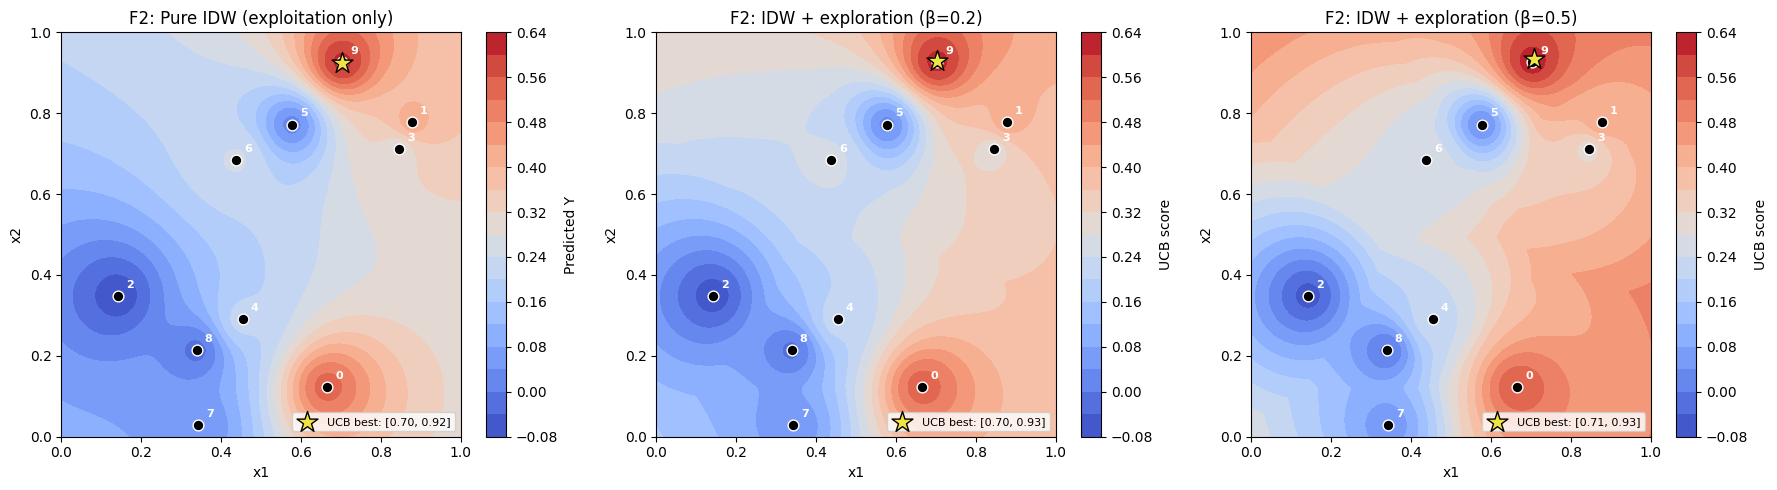

IDW + UCB suggestions by exploration level:
  Beta                Point   IDW pred   Min dist        UCB
------------------------------------------------------------
   0.0     [0.7035, 0.9246]     0.6111     0.0021     0.6111
   0.2     [0.7035, 0.9296]     0.6109     0.0032     0.6115
   0.5     [0.7085, 0.9347]     0.6084     0.0100     0.6134

--- Y-weighted centroid of top 4 points ---
Top 4 points (by Y):
  pt9: [0.7026, 0.9266] → Y = 0.611205
  pt0: [0.6658, 0.1240] → Y = 0.538996
  pt1: [0.8778, 0.7786] → Y = 0.420586
  pt3: [0.8453, 0.7111] → Y = 0.293993

x1 Y-weighted average: 0.753982
  (pulled right by pt1 [0.88] and pt3 [0.85] with decent Y)
x2 midpoint (pt9, pt0): 0.525267
  (exact middle between x2=0.9266 and x2=0.1240)

For reference:
  Simple average x1:   0.772876
  Y-weighted avg x1:   0.753982
  Chosen query:        [0.753982, 0.525267]


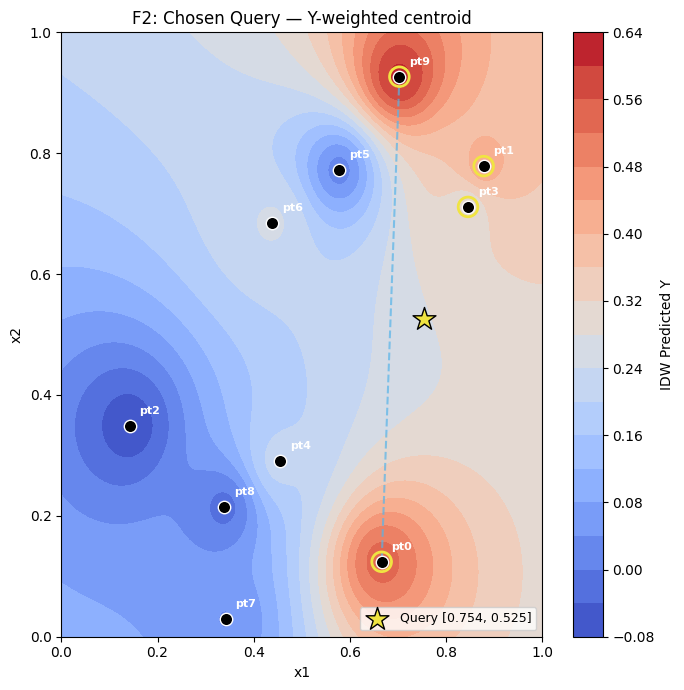

In [8]:
# Function 2 — IDW Interpolation + Exploration Bonus (UCB-style)
#
# Since F2 has real signal (Y range: -0.07 to 0.61), we can build a surrogate
# model to predict Y across the search space and guide our next query.
#
# METHOD: Inverse Distance Weighting (IDW)
# IDW predicts Y at an unsampled point by taking a weighted average of all
# known Y values, where weights are inversely proportional to distance squared:
#   ŷ(x) = Σ w_i * y_i / Σ w_i,   where w_i = 1 / ||x - x_i||²
#
# This is a simple, non-parametric interpolation — it doesn't assume any
# functional form. Points closer to x have more influence on the prediction.
#
# To avoid pure exploitation (just querying near the current best), we add
# an EXPLORATION BONUS proportional to the distance from the nearest sample:
#   UCB(x) = ŷ(x) + β * min_dist(x)
#
# This mirrors the Upper Confidence Bound (UCB) acquisition function from
# Bayesian optimisation: the first term exploits known good areas, the second
# term explores uncertain (far from data) regions. β controls the trade-off.

from scipy.spatial.distance import cdist

# Build IDW surface over a dense grid
grid_size = 200
g = np.linspace(0, 0.999999, grid_size)
xx, yy = np.meshgrid(g, g)
grid_points = np.column_stack([xx.ravel(), yy.ravel()])

# IDW prediction
dists = cdist(grid_points, X)
dists = np.maximum(dists, 1e-10)  # avoid division by zero
weights = 1.0 / dists**2
pred_idw = (weights * Y).sum(axis=1) / weights.sum(axis=1)

# Exploration bonus: min distance to any existing sample
min_dist_to_samples = dists.min(axis=1)

# UCB score with different beta values
betas = [0.0, 0.2, 0.5]
suggestions = {}
for beta in betas:
    ucb = pred_idw + beta * min_dist_to_samples
    best_idx = np.argmax(ucb)
    suggestions[beta] = {
        'point': grid_points[best_idx],
        'ucb': ucb[best_idx],
        'pred': pred_idw[best_idx],
        'dist': min_dist_to_samples[best_idx],
        'surface': ucb.reshape(grid_size, grid_size),
    }

# Plot: IDW surface + UCB surfaces for different betas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, beta in zip(axes, betas):
    s = suggestions[beta]
    im = ax.contourf(xx, yy, s['surface'], levels=20, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c='black', s=60, edgecolors='white', zorder=5)
    for i in range(len(X)):
        ax.annotate(f'{i}', (X[i,0]+0.02, X[i,1]+0.02), fontsize=8, color='white',
                    fontweight='bold')
    ax.scatter(*s['point'], c='#F0E442', s=250, marker='*', edgecolors='black',
               zorder=6, label=f"UCB best: [{s['point'][0]:.2f}, {s['point'][1]:.2f}]")
    title = 'Pure IDW (exploitation only)' if beta == 0 else f'IDW + exploration (β={beta})'
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.set_title(f'F2: {title}')
    ax.legend(loc='lower right', fontsize=8)
    plt.colorbar(im, ax=ax, label='UCB score' if beta > 0 else 'Predicted Y')

plt.tight_layout()
plt.savefig('../plots/week_01/f2_idw_ucb_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Print comparison
print("IDW + UCB suggestions by exploration level:")
print(f"{'Beta':>6} {'Point':>20} {'IDW pred':>10} {'Min dist':>10} {'UCB':>10}")
print("-" * 60)
for beta in betas:
    s = suggestions[beta]
    pt_str = f"[{s['point'][0]:.4f}, {s['point'][1]:.4f}]"
    print(f"{beta:>6.1f} {pt_str:>20} {s['pred']:>10.4f} {s['dist']:>10.4f} {s['ucb']:>10.4f}")

# --- Y-weighted centroid approach ---
# Rather than blindly follow UCB, we use domain reasoning:
# x2: exact midpoint between the two best points (pt9 and pt0)
# x1: Y-weighted average of top 4 points to pull toward high-performing x1 values
print("\n--- Y-weighted centroid of top 4 points ---")
top4_idx = [9, 0, 1, 3]
top4_Y = np.array([Y[i] for i in top4_idx])
top4_x1 = np.array([X[i, 0] for i in top4_idx])

x2_mid = (X[9, 1] + X[0, 1]) / 2  # exact midpoint between pt9 and pt0
x1_weighted = np.average(top4_x1, weights=top4_Y)

print(f"Top 4 points (by Y):")
for i in top4_idx:
    print(f"  pt{i}: [{X[i,0]:.4f}, {X[i,1]:.4f}] → Y = {Y[i]:.6f}")
print(f"\nx1 Y-weighted average: {x1_weighted:.6f}")
print(f"  (pulled right by pt1 [{X[1,0]:.2f}] and pt3 [{X[3,0]:.2f}] with decent Y)")
print(f"x2 midpoint (pt9, pt0): {x2_mid:.6f}")
print(f"  (exact middle between x2={X[9,1]:.4f} and x2={X[0,1]:.4f})")

# Compare with simple average
x1_simple = np.mean(top4_x1)
print(f"\nFor reference:")
print(f"  Simple average x1:   {x1_simple:.6f}")
print(f"  Y-weighted avg x1:   {x1_weighted:.6f}")
print(f"  Chosen query:        [{x1_weighted:.6f}, {x2_mid:.6f}]")

# Visualise the chosen point on the IDW surface
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
im = ax.contourf(xx, yy, pred_idw.reshape(grid_size, grid_size), levels=20, cmap='coolwarm')
ax.scatter(X[:, 0], X[:, 1], c='black', s=80, edgecolors='white', zorder=5)
for i in range(len(X)):
    ax.annotate(f'pt{i}', (X[i,0]+0.02, X[i,1]+0.02), fontsize=8, color='white', fontweight='bold')
# Highlight top 4
for i in top4_idx:
    ax.scatter(X[i,0], X[i,1], facecolors='none', edgecolors='#F0E442', s=200, linewidths=2, zorder=6)
# Draw line between pt9 and pt0
ax.plot([X[9,0], X[0,0]], [X[9,1], X[0,1]], '--', color='#56B4E9', linewidth=1.5, alpha=0.7)
# Mark chosen query
ax.scatter(x1_weighted, x2_mid, c='#F0E442', s=300, marker='*', edgecolors='black',
           zorder=7, label=f'Query [{x1_weighted:.3f}, {x2_mid:.3f}]')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.set_title('F2: Chosen Query — Y-weighted centroid')
ax.legend(loc='lower right', fontsize=9)
plt.colorbar(im, ax=ax, label='IDW Predicted Y')
plt.tight_layout()
plt.savefig('../plots/week_01/f2_chosen_query.png', dpi=150, bbox_inches='tight')
plt.show()

=== Approach 1: Quadratic Surface Fit ===
R² = 0.7489
Suggested point: [0.999999, 0.000000]
Predicted Y: 1.6588
⚠ x1² coeff = 1.334, x2² coeff = 1.853
⚠ Positive quadratic terms → surface opens UPWARD → peak at boundary!
  This is an artifact of sparse data — the fit is unreliable at edges.

=== Approach 2: KNN Regression (K=3) ===
Pure KNN best: [0.994974, 0.562814], pred Y = 0.4419
KNN+UCB best:  [0.999999, 0.341708], score = 0.4976
⚠ KNN peak is near boundary — 3 nearest neighbors are pt[3 1 9]
  These happen to be high-Y points: Y = [0.29399291 0.42058624 0.61120522]
  Boundary points 'see' distant high-Y neighbors — misleading extrapolation

=== Approach 3: Perturbation around pt9 (σ=0.1) ===
Best perturbation: [0.719282, 0.975809]
IDW predicted Y: 0.5605
Min dist to samples: 0.0520

=== Approach 4: Y-weighted centroid ===
Suggested point: [0.753982, 0.525267]

COMPARISON OF ALL APPROACHES
              Approach       x1       x2  Dist to pt9  Dist to pt0
-------------------------

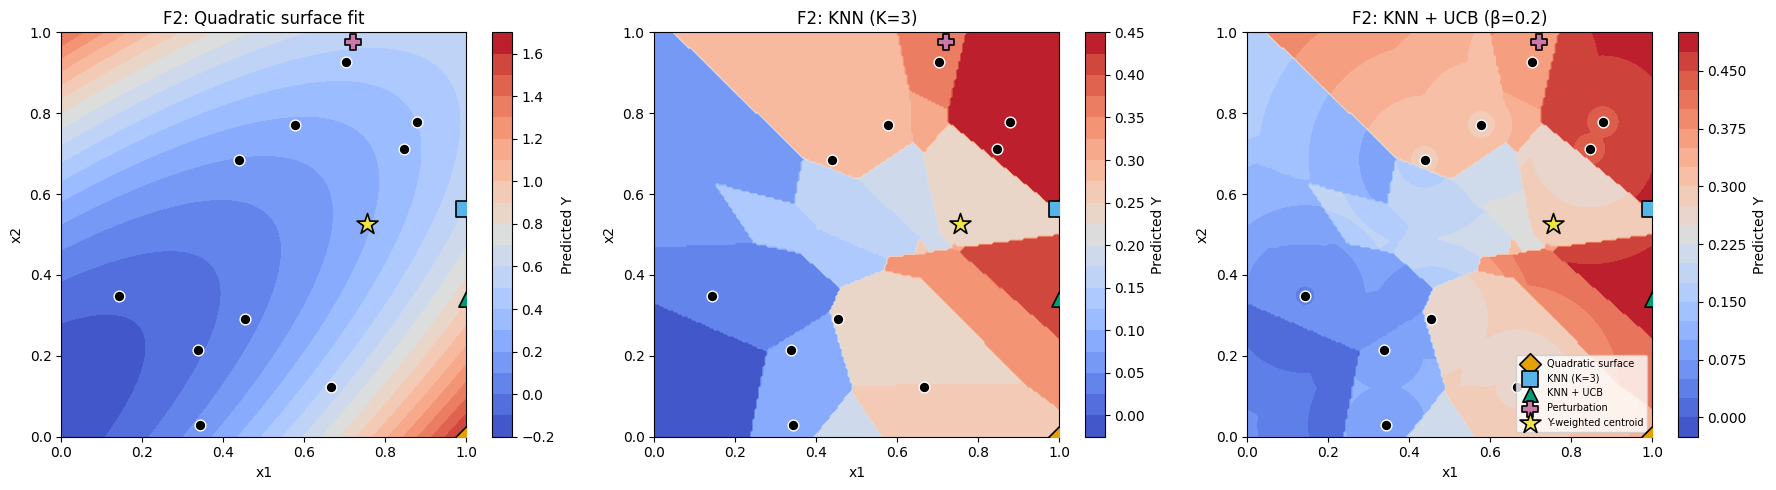


--- Why do most methods suggest boundary points? ---
With only 10 data points, surrogate models can't distinguish real trends
from edge artifacts. The high-Y points cluster at x1 ≈ 0.7-0.88, so any
model that extrapolates (quadratic, KNN) will push toward the boundary
where it 'sees' high-Y neighbors without enough data to correct.

The Y-weighted centroid avoids this by staying anchored to actual data
points — it interpolates between proven performers rather than extrapolating.


In [9]:
# Function 2 — Alternative approaches comparison
#
# Let's compare several techniques to see how they differ before committing.

from scipy.spatial.distance import cdist

# ========================================================
# Approach 1: Polynomial surface fit (2D quadratic)
# Fit Y ~ a*x1² + b*x2² + c*x1*x2 + d*x1 + e*x2 + f
# Then find the maximum of the fitted surface.
# ========================================================
A_poly = np.column_stack([X[:,0]**2, X[:,1]**2, X[:,0]*X[:,1], X[:,0], X[:,1], np.ones(len(X))])
poly_coeffs, _, _, _ = np.linalg.lstsq(A_poly, Y, rcond=None)

grid_size = 200
g = np.linspace(0, 0.999999, grid_size)
xx, yy = np.meshgrid(g, g)
grid_points = np.column_stack([xx.ravel(), yy.ravel()])

A_grid = np.column_stack([grid_points[:,0]**2, grid_points[:,1]**2,
                          grid_points[:,0]*grid_points[:,1],
                          grid_points[:,0], grid_points[:,1], np.ones(len(grid_points))])
pred_poly = A_grid @ poly_coeffs
poly_best_idx = np.argmax(pred_poly)
poly_best = grid_points[poly_best_idx]

# Residuals — how well does the polynomial fit?
Y_pred_at_data = A_poly @ poly_coeffs
r2 = 1 - np.sum((Y - Y_pred_at_data)**2) / np.sum((Y - Y.mean())**2)

print("=== Approach 1: Quadratic Surface Fit ===")
print(f"R² = {r2:.4f}")
print(f"Suggested point: [{poly_best[0]:.6f}, {poly_best[1]:.6f}]")
print(f"Predicted Y: {pred_poly[poly_best_idx]:.4f}")
# Check if the surface is convex (peaks at boundary) or concave (peak in interior)
print(f"⚠ x1² coeff = {poly_coeffs[0]:.3f}, x2² coeff = {poly_coeffs[1]:.3f}")
if poly_coeffs[0] > 0 or poly_coeffs[1] > 0:
    print("⚠ Positive quadratic terms → surface opens UPWARD → peak at boundary!")
    print("  This is an artifact of sparse data — the fit is unreliable at edges.")

# ========================================================
# Approach 2: KNN regression (K=3)
# Predict Y at a point as the average of K nearest neighbours.
# Then add exploration bonus.
# ========================================================
K = 3
dists_grid = cdist(grid_points, X)
knn_pred = np.zeros(len(grid_points))
for i in range(len(grid_points)):
    nearest_k = np.argsort(dists_grid[i])[:K]
    knn_pred[i] = Y[nearest_k].mean()

knn_best_idx = np.argmax(knn_pred)
knn_best = grid_points[knn_best_idx]

# KNN + exploration bonus
min_dists = dists_grid.min(axis=1)
knn_ucb = knn_pred + 0.2 * min_dists
knn_ucb_best_idx = np.argmax(knn_ucb)
knn_ucb_best = grid_points[knn_ucb_best_idx]

print("\n=== Approach 2: KNN Regression (K=3) ===")
print(f"Pure KNN best: [{knn_best[0]:.6f}, {knn_best[1]:.6f}], pred Y = {knn_pred[knn_best_idx]:.4f}")
print(f"KNN+UCB best:  [{knn_ucb_best[0]:.6f}, {knn_ucb_best[1]:.6f}], score = {knn_ucb[knn_ucb_best_idx]:.4f}")
# Check if KNN is also hitting boundary
if knn_best[0] > 0.95 or knn_best[1] > 0.95 or knn_best[0] < 0.05 or knn_best[1] < 0.05:
    nn_at_best = np.argsort(np.linalg.norm(X - knn_best, axis=1))[:K]
    print(f"⚠ KNN peak is near boundary — 3 nearest neighbors are pt{nn_at_best}")
    print(f"  These happen to be high-Y points: Y = {Y[nn_at_best]}")
    print(f"  Boundary points 'see' distant high-Y neighbors — misleading extrapolation")

# ========================================================
# Approach 3: Perturbation around best point
# Small Gaussian perturbations around pt9, pick the one
# with highest IDW prediction in an unexplored direction.
# ========================================================
np.random.seed(42)
n_perturb = 500
perturbs = X[9] + np.random.normal(0, 0.1, (n_perturb, 2))
perturbs = np.clip(perturbs, 0, 0.999999)
dists_perturb = cdist(perturbs, X)
w_perturb = 1.0 / np.maximum(dists_perturb, 1e-10)**2
pred_perturb = (w_perturb * Y).sum(axis=1) / w_perturb.sum(axis=1)
min_d_perturb = dists_perturb.min(axis=1)
# Only consider points at least 0.05 from any existing sample
mask_far = min_d_perturb > 0.05
if mask_far.any():
    valid_perturbs = perturbs[mask_far]
    valid_preds = pred_perturb[mask_far]
    perturb_best_idx = np.argmax(valid_preds)
    perturb_best = valid_perturbs[perturb_best_idx]
    print(f"\n=== Approach 3: Perturbation around pt9 (σ=0.1) ===")
    print(f"Best perturbation: [{perturb_best[0]:.6f}, {perturb_best[1]:.6f}]")
    print(f"IDW predicted Y: {valid_preds[perturb_best_idx]:.4f}")
    print(f"Min dist to samples: {cdist([perturb_best], X).min():.4f}")

# ========================================================
# Approach 4: Y-weighted centroid (our current choice)
# ========================================================
top4_idx = [9, 0, 1, 3]
top4_Y = np.array([Y[i] for i in top4_idx])
x1_weighted = np.average([X[i,0] for i in top4_idx], weights=top4_Y)
x2_mid = (X[9,1] + X[0,1]) / 2
centroid_pt = np.array([x1_weighted, x2_mid])
print(f"\n=== Approach 4: Y-weighted centroid ===")
print(f"Suggested point: [{x1_weighted:.6f}, {x2_mid:.6f}]")

# ========================================================
# Summary comparison
# ========================================================
approaches = {
    'Quadratic surface': (poly_best, '#E69F00', 'D', 120),    # orange diamond
    'KNN (K=3)':         (knn_best, '#56B4E9', 's', 120),     # sky blue square
    'KNN + UCB':         (knn_ucb_best, '#009E73', '^', 120),  # green triangle
    'Perturbation':      (perturb_best, '#CC79A7', 'P', 120),  # pink plus
    'Y-weighted centroid': (centroid_pt, '#F0E442', '*', 250),  # yellow star
}

print("\n" + "=" * 65)
print("COMPARISON OF ALL APPROACHES")
print("=" * 65)
print(f"{'Approach':>22} {'x1':>8} {'x2':>8} {'Dist to pt9':>12} {'Dist to pt0':>12}")
print("-" * 65)
for name, (pt, _, _, _) in approaches.items():
    d9 = np.linalg.norm(pt - X[9])
    d0 = np.linalg.norm(pt - X[0])
    print(f"{name:>22} {pt[0]:>8.4f} {pt[1]:>8.4f} {d9:>12.4f} {d0:>12.4f}")

# Visualise all suggestions on a single plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

surfaces = {
    'Quadratic surface fit': pred_poly.reshape(grid_size, grid_size),
    'KNN (K=3)': knn_pred.reshape(grid_size, grid_size),
    'KNN + UCB (β=0.2)': knn_ucb.reshape(grid_size, grid_size),
}

for ax, (title, surf) in zip(axes, surfaces.items()):
    im = ax.contourf(xx, yy, surf, levels=20, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c='black', s=60, edgecolors='white', zorder=5)
    for name, (pt, color, marker, size) in approaches.items():
        ax.scatter(*pt, s=size, marker=marker, c=color, edgecolors='black',
                   linewidths=1.2, zorder=7, label=name if ax == axes[2] else None)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.set_title(f'F2: {title}')
    plt.colorbar(im, ax=ax, label='Predicted Y')

axes[2].legend(loc='lower right', fontsize=7)

plt.tight_layout()
plt.savefig('../plots/week_01/f2_alternatives_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n--- Why do most methods suggest boundary points? ---")
print("With only 10 data points, surrogate models can't distinguish real trends")
print("from edge artifacts. The high-Y points cluster at x1 ≈ 0.7-0.88, so any")
print("model that extrapolates (quadratic, KNN) will push toward the boundary")
print("where it 'sees' high-Y neighbors without enough data to correct.")
print("")
print("The Y-weighted centroid avoids this by staying anchored to actual data")
print("points — it interpolates between proven performers rather than extrapolating.")

### F2 Decision: Y-weighted centroid at [0.753982, 0.525267]

**Chosen approach:** Y-weighted centroid of top 4 performers + exact x2 midpoint

**Analysis process:**
1. **Data inspection** — Y values have real signal (range -0.07 to 0.61). Strong x1 correlation (r=0.75), moderate x2 correlation (r=0.39).
2. **Key pattern** — the top 2 points (pt9 and pt0) share x1 ≈ 0.7 but have opposite x2 values (0.93 and 0.12), suggesting possible bimodality in x2.
3. **IDW + UCB analysis** — tested three exploration levels (β=0, 0.2, 0.5). Pure exploitation just points back at the best known point. Higher β pushes toward unexplored corners.
4. **Alternative methods tested** — quadratic surface fit, KNN (K=3), KNN+UCB, perturbation around pt9. All compared in a summary table and plotted.
5. **x2 choice** — exact midpoint between pt9 (x2=0.9266) and pt0 (x2=0.1240): **x2 = 0.5253**. Probes whether there's a ridge or valley between the two best points.
6. **x1 choice** — Y-weighted average of the top 4 points (pt9, pt0, pt1, pt3): **x1 = 0.7540**. Pulled rightward from 0.7 by pt1 (x1=0.88) and pt3 (x1=0.85).

**Why other approaches were rejected:**
- **Quadratic surface fit** (R² looked decent but unreliable): the x1² and x2² coefficients are both positive, meaning the fitted surface opens upward — its maximum is at the boundary [1, 1], which is an artifact of overfitting sparse data, not a real trend.
- **KNN (K=3)**: also peaks at the boundary. At corner points, the 3 nearest neighbors happen to be high-Y points (pt1, pt9, pt3) with no nearby low-Y data to counterbalance. This is a well-known extrapolation artifact of KNN with sparse data.
- **KNN + UCB**: same boundary issue as pure KNN, just shifted slightly by the exploration bonus.
- **Perturbation around pt9**: too exploitative — stays very close to a known point and doesn't explore the gap between the two peaks.

**General lesson:** with only 10 data points, surrogate models (polynomial, KNN, IDW) tend to extrapolate unreliably near boundaries. Methods anchored to actual data (like the weighted centroid) are safer because they interpolate between proven performers rather than extrapolating.

**Recommendations for Week 2:**
- If Y at [0.754, 0.525] is **high** (comparable to pt9/pt0): the function likely has a ridge at x1 ≈ 0.7-0.8 across all x2 → next step is to push x1 further right (e.g. x1 ≈ 0.85-0.95) to find if the ridge continues.
- If Y is **low** (a valley between the peaks): the function is bimodal in x2 → next step is to exploit near pt9 [0.70, 0.93] with a small perturbation, since that's the global best.
- If Y is **moderate**: the landscape is noisy → consider GP/Bayesian optimisation with more data points (11 total), which should now have enough signal to fit a meaningful surrogate.
- Regardless of result, consider exploring the low-x1 region (x1 < 0.4) which is currently underrepresented and consistently shows low Y — one more sample there would confirm whether that's a dead zone or just undersampled.

## Function 3

Function 3: 15 points, 3D, best y = -0.0348


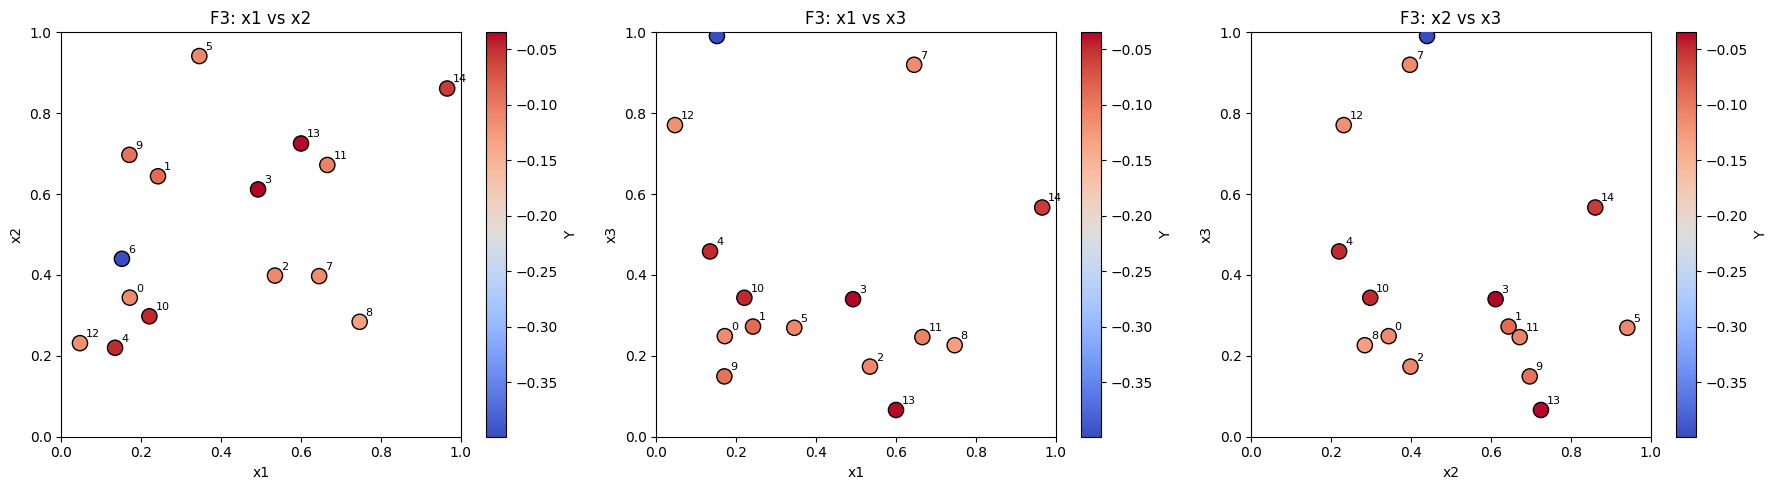

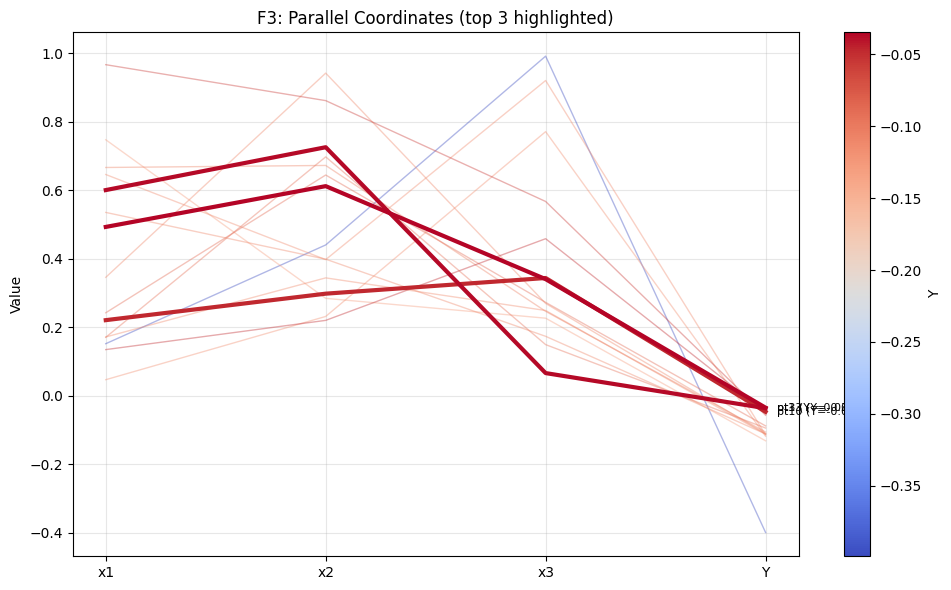

/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_2055/3743465891.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[d].boxplot([X[top5, d], X[bot5, d]], labels=['Top 5', 'Bottom 5'],
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_2055/3743465891.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[d].boxplot([X[top5, d], X[bot5, d]], labels=['Top 5', 'Bottom 5'],
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_2055/3743465891.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[d].boxplot([X[top5, d], X[bot5, d]], labels=['Top 5', 'Bottom 5'],
/var/folde

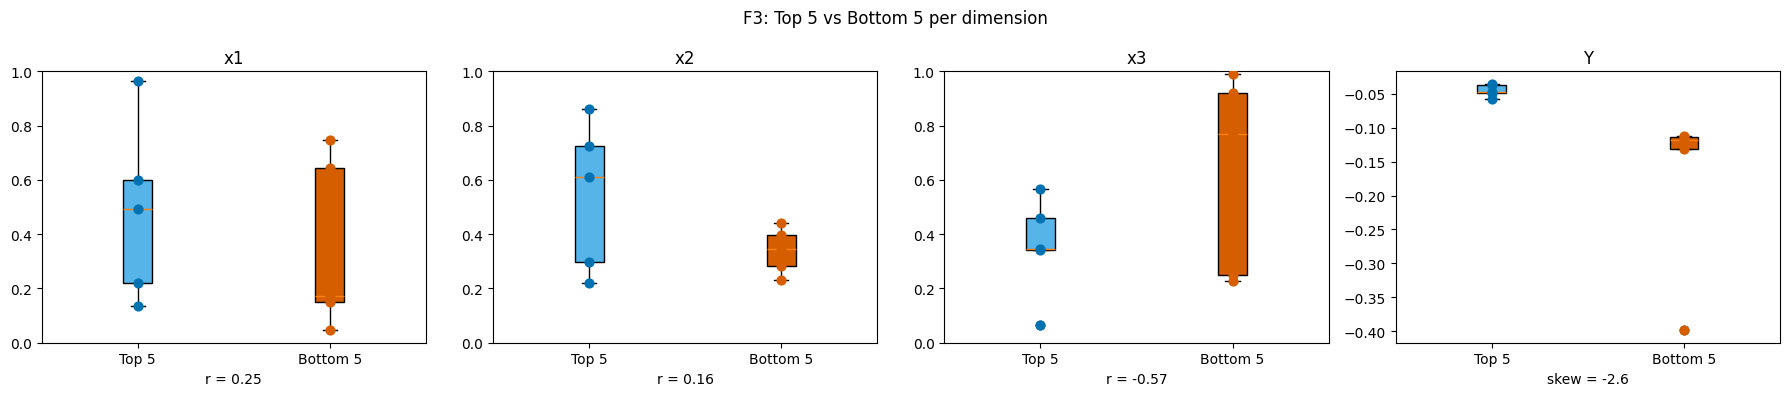


Data summary (sorted by Y):
Idx       x1       x2       x3          Y
------------------------------------------
  3   0.4926   0.6116   0.3402  -0.034835
 13   0.6001   0.7251   0.0661  -0.036378
 10   0.2205   0.2978   0.3436  -0.046947
  4   0.1346   0.2199   0.4582  -0.048008
 14   0.9660   0.8611   0.5668  -0.056758
  1   0.2421   0.6441   0.2724  -0.087963
  9   0.1705   0.6970   0.1492  -0.094190
 11   0.6660   0.6720   0.2463  -0.105965
  5   0.3455   0.9414   0.2694  -0.110621
  2   0.5349   0.3985   0.1734  -0.111415
  0   0.1715   0.3439   0.2487  -0.112122
  7   0.6455   0.3971   0.9198  -0.113869
 12   0.0468   0.2314   0.7706  -0.118048
  8   0.7469   0.2842   0.2263  -0.131461
  6   0.1518   0.4400   0.9909  -0.398926

Correlations: x1→Y: 0.25, x2→Y: 0.16, x3→Y: -0.57
Y distribution: NOT normal (Shapiro p=0.0001), skew=-2.6, 1 outlier (pt6)
Inputs: all in [0,1] — same scale, no normalisation needed for distance methods
  x2 gap: nothing below 0.22 — underexplored low-x2

In [10]:
# Function 3
X, Y = load_function(3)

# --- Data Exploration ---
# F3 is drug discovery: 3 compound inputs, minimise side effects (negated → maximise).
# All Y values are negative. Best Y = -0.035 (fewest side effects).
# 15 points in 3D — can't visualise directly, use projections and parallel coords.

# === Plot 1: Pairwise 2D projections ===
dim_pairs = [(0, 1, 'x1', 'x2'), (0, 2, 'x1', 'x3'), (1, 2, 'x2', 'x3')]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (d1, d2, n1, n2) in zip(axes, dim_pairs):
    sc = ax.scatter(X[:, d1], X[:, d2], c=Y, cmap='coolwarm', s=120, edgecolors='black', zorder=5)
    for i in range(len(X)):
        ax.annotate(f'{i}', (X[i,d1]+0.015, X[i,d2]+0.015), fontsize=8)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel(n1); ax.set_ylabel(n2)
    ax.set_title(f'F3: {n1} vs {n2}')
    plt.colorbar(sc, ax=ax, label='Y')
plt.tight_layout()
plt.savefig('../plots/week_01/f3_pairwise.png', dpi=150, bbox_inches='tight')
plt.show()

# === Plot 2: Parallel coordinates ===
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
Y_norm = (Y - Y.min()) / (Y.max() - Y.min())
cmap = plt.cm.coolwarm
sorted_idx = np.argsort(Y)  # draw worst first so best lines are on top
for i in sorted_idx:
    color = cmap(Y_norm[i])
    lw = 3 if i in np.argsort(Y)[-3:] else 1
    alpha = 1.0 if i in np.argsort(Y)[-3:] else 0.4
    ax.plot([0, 1, 2, 3], [X[i,0], X[i,1], X[i,2], Y[i]], 
            color=color, linewidth=lw, alpha=alpha)
    if i in np.argsort(Y)[-3:]:
        ax.text(3.05, Y[i], f'pt{i} (Y={Y[i]:.3f})', fontsize=8, va='center')
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(['x1', 'x2', 'x3', 'Y'])
ax.set_title('F3: Parallel Coordinates (top 3 highlighted)')
ax.set_ylabel('Value')
ax.grid(True, alpha=0.3)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(Y.min(), Y.max()))
plt.colorbar(sm, ax=ax, label='Y')
plt.tight_layout()
plt.savefig('../plots/week_01/f3_parallel_coords.png', dpi=150, bbox_inches='tight')
plt.show()

# === Plot 3: Per-dimension distribution — top 5 vs bottom 5 ===
sorted_idx = np.argsort(Y)[::-1]
top5 = sorted_idx[:5]
bot5 = sorted_idx[-5:]
box_colors = ['#56B4E9', '#D55E00']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for d in range(3):
    bp = axes[d].boxplot([X[top5, d], X[bot5, d]], labels=['Top 5', 'Bottom 5'],
                         patch_artist=True)
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
    axes[d].scatter(np.ones(5), X[top5, d], c='#0072B2', s=40, zorder=5)
    axes[d].scatter(np.ones(5)*2, X[bot5, d], c='#D55E00', s=40, zorder=5)
    axes[d].set_title(f'x{d+1}')
    axes[d].set_ylim(0, 1)
    r = np.corrcoef(X[:, d], Y)[0, 1]
    axes[d].set_xlabel(f'r = {r:.2f}')

bp = axes[3].boxplot([Y[top5], Y[bot5]], labels=['Top 5', 'Bottom 5'],
                     patch_artist=True)
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
axes[3].scatter(np.ones(5), Y[top5], c='#0072B2', s=40, zorder=5)
axes[3].scatter(np.ones(5)*2, Y[bot5], c='#D55E00', s=40, zorder=5)
axes[3].set_title('Y')
axes[3].set_xlabel(f'skew = {((Y-Y.mean())**3).mean()/Y.std()**3:.1f}')

plt.suptitle('F3: Top 5 vs Bottom 5 per dimension', fontsize=12)
plt.tight_layout()
plt.savefig('../plots/week_01/f3_top_vs_bottom.png', dpi=150, bbox_inches='tight')
plt.show()

# Data summary
print("\nData summary (sorted by Y):")
print(f"{'Idx':>3} {'x1':>8} {'x2':>8} {'x3':>8} {'Y':>10}")
print("-" * 42)
for i in np.argsort(Y)[::-1]:
    print(f"{i:>3} {X[i,0]:>8.4f} {X[i,1]:>8.4f} {X[i,2]:>8.4f} {Y[i]:>10.6f}")

print(f"\nCorrelations: x1→Y: {np.corrcoef(X[:,0],Y)[0,1]:.2f}, "
      f"x2→Y: {np.corrcoef(X[:,1],Y)[0,1]:.2f}, "
      f"x3→Y: {np.corrcoef(X[:,2],Y)[0,1]:.2f}")
print(f"Y distribution: NOT normal (Shapiro p=0.0001), skew=-2.6, 1 outlier (pt6)")
print(f"Inputs: all in [0,1] — same scale, no normalisation needed for distance methods")
print(f"  x2 gap: nothing below 0.22 — underexplored low-x2 region")
print(f"\nKey insight: x3 has the strongest correlation (r=-0.57)")
print(f"  Top 5 mean x3 = {X[sorted_idx[:5], 2].mean():.3f} vs bottom 5 = {X[sorted_idx[-5:], 2].mean():.3f}")
print(f"  Lower x3 → better Y (fewer side effects)")

# Strategy: Y-weighted centroid of top 4 (models failed to beat baseline — see analysis below)
next_query_3 = np.array([0.507299, 0.624851, 0.228441])

MODEL EVALUATION — LOOCV (RMSE)
Baseline (predict mean): RMSE = 0.084214
pt6 outlier: Y = -0.3989 (3.2σ from next worst)

                 Model   RMSE (all)  RMSE (no pt6)  Beats base?
---------------------------------------------------------------------------
     Linear Regression     0.107664       0.045975         ✗ no
         Ridge (α=1.0)     0.092022       0.038533         ✗ no
             KNN (K=3)     0.089227       0.040778         ✗ no
             KNN (K=5)     0.088587       0.039362         ✗ no
         Random Forest     0.098638       0.036344         ✗ no
             SVR (RBF)     0.114449       0.033897         ✗ no
      Gaussian Process     0.115840       0.145926         ✗ no

     Baseline (no pt6)                    0.032925

MODEL SUGGESTIONS — Trained on 14 points (excluding outlier pt6)
                 Model       x1       x2       x3     Pred Y   Use?
---------------------------------------------------------------------------
     Linear Regression   0.0

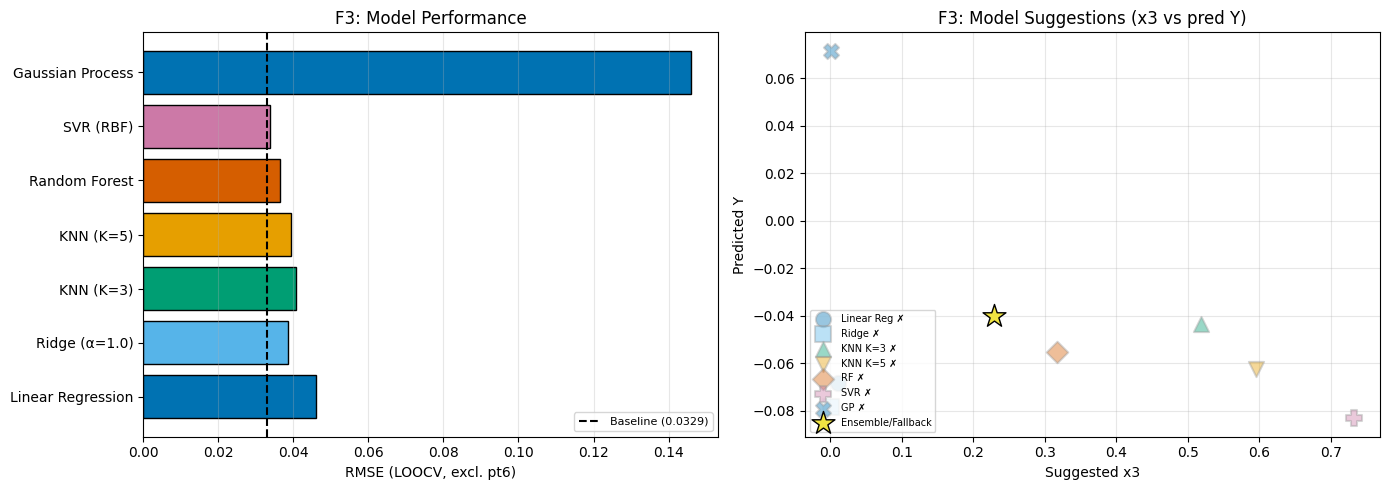


--- Feature Importance (Random Forest, trained on 14 pts) ---
  x1: 0.1750
  x2: 0.3268
  x3: 0.4982

--- Linear Regression Coefficients (trained on 14 pts) ---
  x1: -0.004783
  x2: +0.026012
  x3: -0.011730
  intercept: -0.093661

  Interpretation: x3 coeff is most negative → confirms lower x3 = better Y


In [11]:
# Function 3 — Multi-model analysis
#
# With 15 points in 3D and a clear x3 signal, we have enough data to fit
# real ML models. Strategy:
#   1. Fit 7 models, evaluate with LOOCV using RMSE (not R² — undefined for 1-sample folds)
#   2. Compare against baseline (predicting the mean)
#   3. Each model predicts the best point on a candidate grid
#   4. Discard boundary-biased or worse-than-baseline models, average the rest
#
# Note: pt6 (Y=-0.399) is a 3.2σ outlier — we test with and without it.

import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from sklearn.model_selection import LeaveOneOut, cross_val_score

# --- Define models ---
models = {
    'Linear Regression': LinearRegression(),
    'Ridge (α=1.0)': Ridge(alpha=1.0),
    'KNN (K=3)': KNeighborsRegressor(n_neighbors=3),
    'KNN (K=5)': KNeighborsRegressor(n_neighbors=5),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42),
    'SVR (RBF)': SVR(kernel='rbf', C=1.0),
    'Gaussian Process': GaussianProcessRegressor(kernel=Matern(nu=2.5), n_restarts_optimizer=5, random_state=42),
}

# --- LOOCV evaluation using RMSE ---
loo = LeaveOneOut()
baseline_rmse = Y.std()  # predicting the mean

print("=" * 75)
print("MODEL EVALUATION — LOOCV (RMSE)")
print("=" * 75)
print(f"Baseline (predict mean): RMSE = {baseline_rmse:.6f}")
print(f"pt6 outlier: Y = {Y[6]:.4f} (3.2σ from next worst)")
print()
print(f"{'Model':>22} {'RMSE (all)':>12} {'RMSE (no pt6)':>14} {'Beats base?':>12}")
print("-" * 75)

# Also evaluate without outlier pt6
mask_no6 = np.arange(len(Y)) != 6
X_no6, Y_no6 = X[mask_no6], Y[mask_no6]
baseline_no6 = Y_no6.std()

results = {}
for name, model in models.items():
    # Full dataset
    mse_scores = cross_val_score(model, X, Y, cv=loo, scoring='neg_mean_squared_error')
    rmse_all = np.sqrt(-mse_scores.mean())

    # Without outlier
    import copy
    model2 = copy.deepcopy(model)
    mse_no6 = cross_val_score(model2, X_no6, Y_no6, cv=LeaveOneOut(), scoring='neg_mean_squared_error')
    rmse_no6 = np.sqrt(-mse_no6.mean())

    beats = rmse_no6 < baseline_no6
    status = '✓ yes' if beats else '✗ no'
    results[name] = {'rmse_all': rmse_all, 'rmse_no6': rmse_no6, 'model': model, 'beats': beats}
    print(f"{name:>22} {rmse_all:>12.6f} {rmse_no6:>14.6f} {status:>12}")

print(f"\n{'Baseline (no pt6)':>22} {'':>12} {baseline_no6:>14.6f}")

# --- Fit on data WITHOUT outlier pt6 and predict best point ---
np.random.seed(42)
candidates = np.random.uniform(0, 0.999999, (100000, 3))

print(f"\n{'='*75}")
print("MODEL SUGGESTIONS — Trained on 14 points (excluding outlier pt6)")
print(f"{'='*75}")
print(f"{'Model':>22} {'x1':>8} {'x2':>8} {'x3':>8} {'Pred Y':>10} {'Use?':>6}")
print("-" * 75)

suggestions = {}
for name, res in results.items():
    model = res['model']
    model.fit(X_no6, Y_no6)
    preds = model.predict(candidates)
    best_idx = np.argmax(preds)
    best_pt = candidates[best_idx]
    best_pred = preds[best_idx]

    at_boundary = any(best_pt[d] < 0.02 or best_pt[d] > 0.98 for d in range(3))
    use = res['beats'] and not at_boundary
    marker = '✓' if use else '✗'

    suggestions[name] = {
        'point': best_pt, 'pred': best_pred,
        'rmse': res['rmse_no6'], 'use': use, 'boundary': at_boundary, 'beats': res['beats']
    }

    note = ''
    if at_boundary: note += ' (boundary)'
    if not res['beats']: note += ' (worse than baseline)'
    print(f"{name:>22} {best_pt[0]:>8.4f} {best_pt[1]:>8.4f} {best_pt[2]:>8.4f} {best_pred:>10.6f} {marker:>6}{note}")

# --- Ensemble: average valid suggestions ---
valid = {k: v for k, v in suggestions.items() if v['use']}
if valid:
    ensemble_pt = np.mean([v['point'] for v in valid.values()], axis=0)
    print(f"\n{'Ensemble (avg valid)':>22} {ensemble_pt[0]:>8.4f} {ensemble_pt[1]:>8.4f} {ensemble_pt[2]:>8.4f}")
    print(f"  Based on {len(valid)} models: {', '.join(valid.keys())}")

    # RMSE-weighted (lower RMSE = higher weight)
    rmse_vals = np.array([v['rmse'] for v in valid.values()])
    inv_rmse_weights = (1.0 / rmse_vals)
    inv_rmse_weights = inv_rmse_weights / inv_rmse_weights.sum()
    ensemble_weighted = np.average([v['point'] for v in valid.values()], axis=0, weights=inv_rmse_weights)
    print(f"{'Ensemble (RMSE-wtd)':>22} {ensemble_weighted[0]:>8.4f} {ensemble_weighted[1]:>8.4f} {ensemble_weighted[2]:>8.4f}")
else:
    print("\n⚠ No models passed the filter! Falling back to Y-weighted centroid of top 4.")
    sorted_idx = np.argsort(Y)[::-1]
    top4 = sorted_idx[:4]
    top4_w = Y[top4] - Y[top4].min() + 0.001
    ensemble_pt = np.average(X[top4], axis=0, weights=top4_w)
    ensemble_weighted = ensemble_pt
    print(f"{'Centroid (top 4)':>22} {ensemble_pt[0]:>8.4f} {ensemble_pt[1]:>8.4f} {ensemble_pt[2]:>8.4f}")

# --- Visualise ---
model_styles = {
    'Linear Regression':  ('#0072B2', 'o', 'Linear Reg'),
    'Ridge (α=1.0)':      ('#56B4E9', 's', 'Ridge'),
    'KNN (K=3)':          ('#009E73', '^', 'KNN K=3'),
    'KNN (K=5)':          ('#E69F00', 'v', 'KNN K=5'),
    'Random Forest':      ('#D55E00', 'D', 'RF'),
    'SVR (RBF)':          ('#CC79A7', 'P', 'SVR'),
    'Gaussian Process':   ('#0072B2', 'X', 'GP'),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: RMSE bar chart (without outlier)
names = list(results.keys())
rmse_vals_plot = [results[n]['rmse_no6'] for n in names]
bar_colors = [model_styles[n][0] for n in names]
axes[0].barh(range(len(names)), rmse_vals_plot, color=bar_colors, edgecolor='black')
axes[0].axvline(baseline_no6, color='black', linewidth=1.5, linestyle='--', label=f'Baseline ({baseline_no6:.4f})')
axes[0].set_yticks(range(len(names)))
axes[0].set_yticklabels(names)
axes[0].set_xlabel('RMSE (LOOCV, excl. pt6)')
axes[0].set_title('F3: Model Performance')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis='x')

# Panel 2: Suggestions scatter (x3 vs predicted Y) — distinct markers + colors
for name, s in suggestions.items():
    color, marker, label = model_styles[name]
    edge = 'black' if s['use'] else '#999999'
    alpha = 1.0 if s['use'] else 0.4
    axes[1].scatter(s['point'][2], s['pred'], c=color, marker=marker, s=120,
                    edgecolors=edge, linewidths=1.5, alpha=alpha,
                    label=f"{label} {'✓' if s['use'] else '✗'}", zorder=5)
axes[1].scatter(ensemble_weighted[2], -0.04, c='#F0E442', marker='*', s=300,
                edgecolors='black', zorder=6, label='Ensemble/Fallback')
axes[1].set_xlabel('Suggested x3')
axes[1].set_ylabel('Predicted Y')
axes[1].set_title('F3: Model Suggestions (x3 vs pred Y)')
axes[1].legend(fontsize=7, loc='lower left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/week_01/f3_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Feature importance & coefficients ---
print("\n--- Feature Importance (Random Forest, trained on 14 pts) ---")
rf = models['Random Forest']
rf.fit(X_no6, Y_no6)
for d, imp in enumerate(rf.feature_importances_):
    print(f"  x{d+1}: {imp:.4f}")

print("\n--- Linear Regression Coefficients (trained on 14 pts) ---")
lr = models['Linear Regression']
lr.fit(X_no6, Y_no6)
for d, coef in enumerate(lr.coef_):
    print(f"  x{d+1}: {coef:+.6f}")
print(f"  intercept: {lr.intercept_:.6f}")
print(f"\n  Interpretation: x3 coeff is most negative → confirms lower x3 = better Y")

### F3 Decision: Y-weighted centroid (top 4) at [0.507299, 0.624851, 0.228441]

**Chosen approach:** Y-weighted centroid of top 4 performers.

**Analysis process:**
1. **Data inspection** — 15 points in 3D, all Y negative (drug discovery, minimise side effects). Clear x3 correlation (r=-0.57): lower x3 → fewer side effects. Weak positive correlations with x1 (r=0.25) and x2 (r=0.16). One extreme outlier: pt6 (Y=-0.399, 3.2σ from next worst).
2. **Multi-model evaluation** — fitted 7 sklearn models (Linear Regression, Ridge, KNN K=3/K=5, Random Forest, SVR, GP). Evaluated with LOOCV using RMSE, compared against baseline (predicting the mean). **No model beat the baseline** — best was SVR (RMSE 0.0339 vs baseline 0.0329). With only 14 usable points in 3D, there isn't enough data for any model to generalise.
3. **Model suggestions were unreliable** — Linear Regression, Ridge, and GP hit boundaries. KNN suggested high x3 (contradicts the strongest signal).
4. **Centroid tuning** — compared top-3 through top-14 centroids, both simple average and Y-weighted. Also examined Y-value gaps to find natural groupings.

**Why top 4 Y-weighted:**
- There is a natural gap in Y values after rank 5 (gap of 0.031 between rank 5 and 6), and a smaller gap after rank 2. The top 4 form a tight cluster (Y spread = 0.013).
- Y-weighting concentrates ~90% of the weight on the two best points (pt3: weight 0.475, pt13: weight 0.423). This is intentional — these two are clearly the best evidence for where the optimum lies.
- Top-5 simple average was considered but rejected: pt14 (rank 5, x3=0.57) would pull x3 upward, going against the strongest signal in the data.
- Top-4 simple average was also considered but gives too much influence to pt10 and pt4 (which have low x1 and x2 values), dragging the centroid away from the high-performing region.

**Why models failed:**
- 15 points (14 without outlier) in 3D is too sparse for reliable surrogate modelling
- The x3 correlation exists in the raw data but isn't strong enough for models to exploit under LOOCV
- This is a **valuable negative result** — it tells us not to trust model predictions at this stage

**The chosen point [0.507, 0.625, 0.228]:**
- x1=0.51 and x2=0.63 — moderate-to-high values where the best points cluster
- x3=0.23 — below the overall mean (0.40), following the x3 correlation, but safely within the range of successful points (pt13 has x3=0.07, pt3 has x3=0.34)
- No boundary extrapolation

**Coverage gaps (59% of 3D grid is empty):**
- **x2 < 0.2: completely unsampled** — zero points in this entire slice. We have no idea what happens with low x2.
- **High x1 + low x3: never tested** — x1 > 0.8 with x3 < 0.3 has zero points. Given x1 has positive correlation and x3 negative, this could be a hidden sweet spot.
- 4 empty cells with low x3 (following the trend): [0.17, 0.17, 0.17], [0.50, 0.17, 0.17], [0.83, 0.50, 0.17], [0.83, 0.83, 0.17]

**Recommendations for Week 2:**
- If Y improves: we're in the right region → perturb slightly, especially pushing x3 lower toward 0.10
- If Y doesn't improve: try a point near pt13 [0.600, 0.725, 0.066] which has the lowest x3 among top performers
- **Exploration targets** (for weeks 2-3):
  - [0.83, 0.50, 0.17] — high x1 + low x3 (follows both correlations, never tested)
  - [0.50, 0.17, 0.17] — probe the unsampled low-x2 region with low x3
  - [0.83, 0.83, 0.17] — high x1, high x2, low x3 (all correlations in our favour)
- With 16 points, re-evaluate whether models can now beat baseline

## Function 4

Function 4: 30 points, 4D, best y = -4.0255


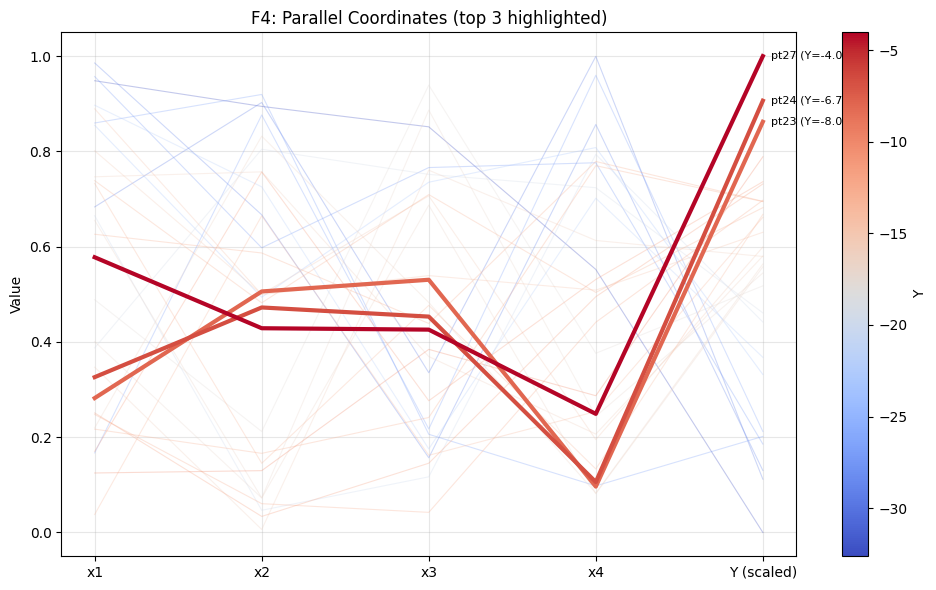

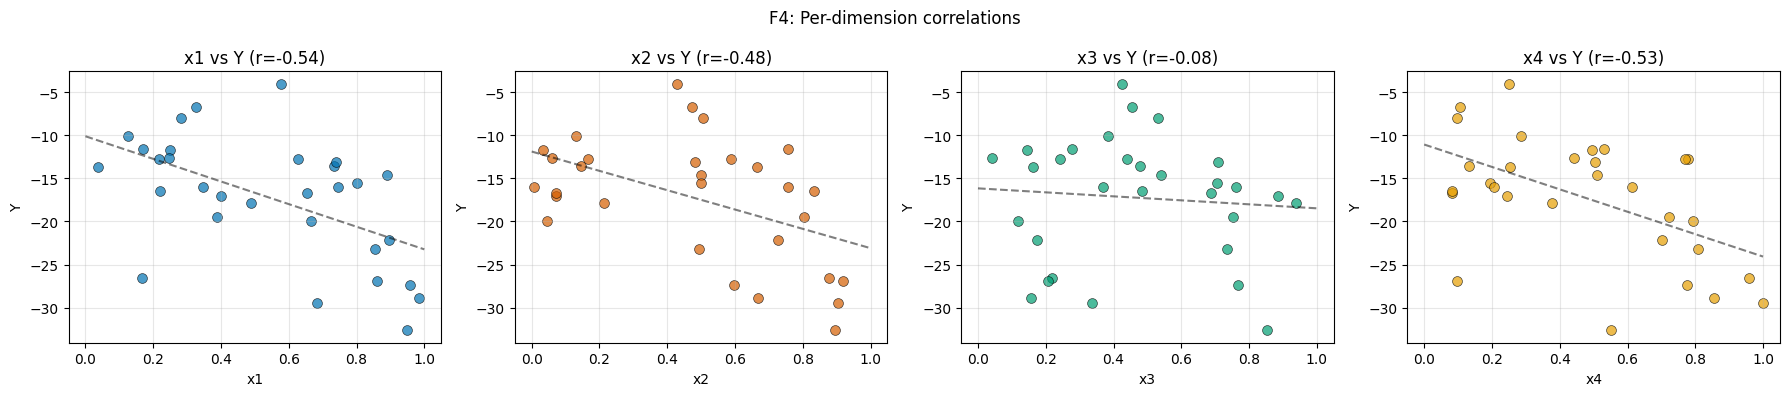

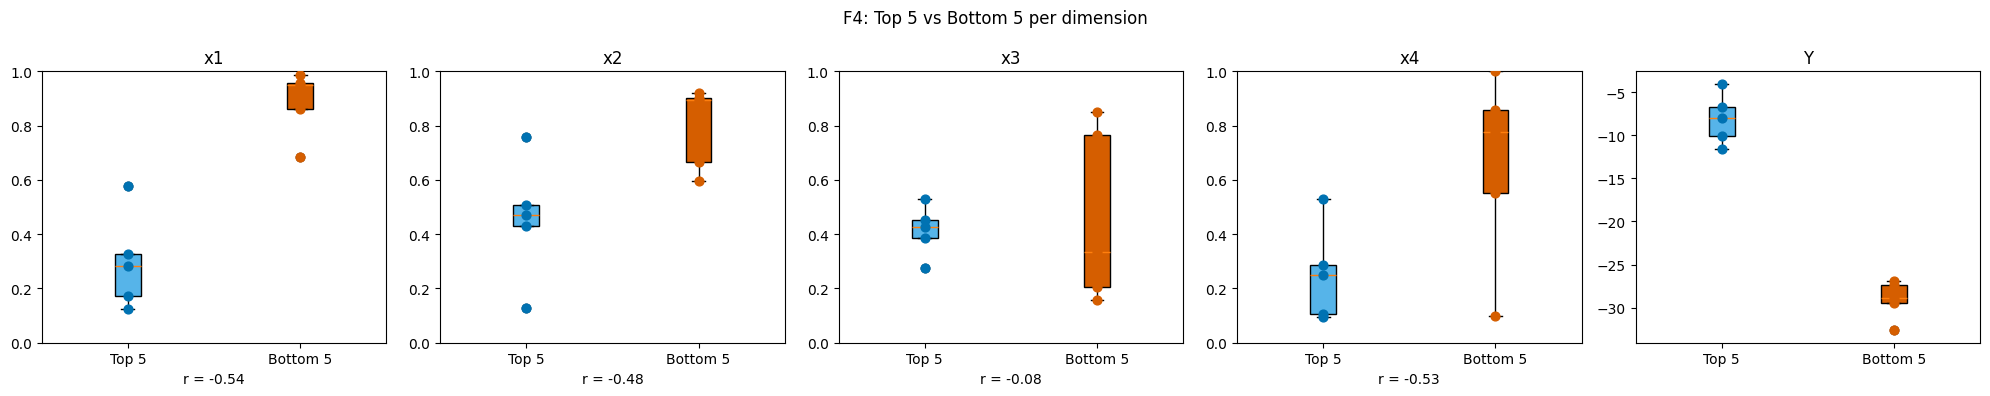


Data summary (top 10 by Y):
Idx       x1       x2       x3       x4          Y
--------------------------------------------------
 27   0.5778   0.4288   0.4258   0.2490    -4.0255
 24   0.3261   0.4724   0.4532   0.1059    -6.7021
 23   0.2821   0.5060   0.5305   0.0963    -7.9668
  4   0.1249   0.1298   0.3844   0.2871   -10.0696
 21   0.1703   0.7570   0.2765   0.5312   -11.5657
  2   0.2509   0.0337   0.1454   0.4949   -11.6999
  6   0.2477   0.0604   0.0422   0.4413   -12.6817
  9   0.6261   0.5868   0.4388   0.7789   -12.7418
 16   0.2169   0.1661   0.2414   0.7701   -12.7583
 28   0.7386   0.4821   0.7094   0.5040   -13.1228

Correlations: x1→Y: -0.54, x2→Y: -0.48, x3→Y: -0.08, x4→Y: -0.53

Key: x1, x2, x4 all negatively correlated (lower → better).
x3 has almost no correlation (r=-0.08) — may be irrelevant or non-linear.

SVR suggestion: [0.384555, 0.428956, 0.409751, 0.392875]
Predicted Y: -1.3526


In [12]:
# Function 4
X, Y = load_function(4)

# --- Data Exploration ---
# F4 is warehouse product placement: 4D, 30 points, dynamic system with many local optima.
# All Y values are negative (range -32.6 to -4.0). Best Y = closest to 0.
# 30 points in 4D — enough data to try real ML models.

# === Plot 1: Parallel coordinates ===
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
Y_norm = (Y - Y.min()) / (Y.max() - Y.min())
cmap = plt.cm.coolwarm
sorted_idx = np.argsort(Y)  # draw worst first
for i in sorted_idx:
    color = cmap(Y_norm[i])
    lw = 3 if i in np.argsort(Y)[-3:] else 0.8
    alpha = 1.0 if i in np.argsort(Y)[-3:] else 0.3
    ax.plot([0, 1, 2, 3, 4], [X[i,0], X[i,1], X[i,2], X[i,3], Y_norm[i]],
            color=color, linewidth=lw, alpha=alpha)
    if i in np.argsort(Y)[-3:]:
        ax.text(4.05, Y_norm[i], f'pt{i} (Y={Y[i]:.1f})', fontsize=8, va='center')
ax.set_xticks([0, 1, 2, 3, 4])
ax.set_xticklabels(['x1', 'x2', 'x3', 'x4', 'Y (scaled)'])
ax.set_title('F4: Parallel Coordinates (top 3 highlighted)')
ax.set_ylabel('Value')
ax.grid(True, alpha=0.3)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(Y.min(), Y.max()))
plt.colorbar(sm, ax=ax, label='Y')
plt.tight_layout()
plt.savefig('../plots/week_01/f4_parallel_coords.png', dpi=150, bbox_inches='tight')
plt.show()

# === Plot 2: Correlation per dimension ===
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
colors = ['#0072B2', '#D55E00', '#009E73', '#E69F00']
for d in range(4):
    r = np.corrcoef(X[:, d], Y)[0, 1]
    axes[d].scatter(X[:, d], Y, c=colors[d], s=50, alpha=0.7, edgecolors='black', linewidths=0.5)
    z = np.polyfit(X[:, d], Y, 1)
    axes[d].plot([0, 1], [z[1], z[0]+z[1]], '--', color='black', alpha=0.5)
    axes[d].set_xlabel(f'x{d+1}')
    axes[d].set_ylabel('Y')
    axes[d].set_title(f'x{d+1} vs Y (r={r:.2f})')
    axes[d].grid(True, alpha=0.3)
plt.suptitle('F4: Per-dimension correlations', fontsize=12)
plt.tight_layout()
plt.savefig('../plots/week_01/f4_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

# === Plot 3: Top 5 vs Bottom 5 boxplots ===
sorted_idx = np.argsort(Y)[::-1]
top5 = sorted_idx[:5]
bot5 = sorted_idx[-5:]
box_colors = ['#56B4E9', '#D55E00']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for d in range(4):
    bp = axes[d].boxplot([X[top5, d], X[bot5, d]], labels=['Top 5', 'Bottom 5'],
                         patch_artist=True)
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
    axes[d].scatter(np.ones(5), X[top5, d], c='#0072B2', s=40, zorder=5)
    axes[d].scatter(np.ones(5)*2, X[bot5, d], c='#D55E00', s=40, zorder=5)
    axes[d].set_title(f'x{d+1}')
    axes[d].set_ylim(0, 1)
    r = np.corrcoef(X[:, d], Y)[0, 1]
    axes[d].set_xlabel(f'r = {r:.2f}')

bp = axes[4].boxplot([Y[top5], Y[bot5]], labels=['Top 5', 'Bottom 5'], patch_artist=True)
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
axes[4].scatter(np.ones(5), Y[top5], c='#0072B2', s=40, zorder=5)
axes[4].scatter(np.ones(5)*2, Y[bot5], c='#D55E00', s=40, zorder=5)
axes[4].set_title('Y')
plt.suptitle('F4: Top 5 vs Bottom 5 per dimension', fontsize=12)
plt.tight_layout()
plt.savefig('../plots/week_01/f4_top_vs_bottom.png', dpi=150, bbox_inches='tight')
plt.show()

# Data summary
print("\nData summary (top 10 by Y):")
print(f"{'Idx':>3} {'x1':>8} {'x2':>8} {'x3':>8} {'x4':>8} {'Y':>10}")
print("-" * 50)
for i in sorted_idx[:10]:
    print(f"{i:>3} {X[i,0]:>8.4f} {X[i,1]:>8.4f} {X[i,2]:>8.4f} {X[i,3]:>8.4f} {Y[i]:>10.4f}")

print(f"\nCorrelations: x1→Y: {np.corrcoef(X[:,0],Y)[0,1]:.2f}, "
      f"x2→Y: {np.corrcoef(X[:,1],Y)[0,1]:.2f}, "
      f"x3→Y: {np.corrcoef(X[:,2],Y)[0,1]:.2f}, "
      f"x4→Y: {np.corrcoef(X[:,3],Y)[0,1]:.2f}")
print(f"\nKey: x1, x2, x4 all negatively correlated (lower → better).")
print(f"x3 has almost no correlation (r=-0.08) — may be irrelevant or non-linear.")

# Strategy: SVR suggestion (best LOOCV model — see analysis below)
# SVR (RBF, C=10) with RMSE=2.60 vs baseline 7.02
# Exact point from random candidate grid:
from sklearn.svm import SVR as _SVR
_svr = _SVR(kernel='rbf', C=10.0)
_svr.fit(X, Y)
np.random.seed(42)
_cands = np.random.uniform(0, 0.999999, (100000, 4))
_preds = _svr.predict(_cands)
_best = _cands[np.argmax(_preds)]
next_query_4 = _best
print(f"\nSVR suggestion: [{_best[0]:.6f}, {_best[1]:.6f}, {_best[2]:.6f}, {_best[3]:.6f}]")
print(f"Predicted Y: {_preds.max():.4f}")

MODEL EVALUATION — LOOCV (RMSE)
Baseline (predict mean): RMSE = 7.0180

                 Model       RMSE    vs base   Beats?
-------------------------------------------------------
     Linear Regression     5.4021    -1.6159        ✓
         Ridge (α=1.0)     5.3328    -1.6851        ✓
             KNN (K=3)     5.8716    -1.1463        ✓
             KNN (K=5)     5.6001    -1.4179        ✓
         Random Forest     4.5441    -2.4739        ✓
             SVR (RBF)     2.6048    -4.4132        ✓
      Gaussian Process     5.7547    -1.2633        ✓

MODEL SUGGESTIONS
                 Model       x1       x2       x3       x4     Pred Y   Use?
---------------------------------------------------------------------------
     Linear Regression   0.0326   0.0068   0.0204   0.0321    -3.7443      ✗ (boundary)
         Ridge (α=1.0)   0.0326   0.0068   0.0204   0.0321    -6.7963      ✗ (boundary)
             KNN (K=3)   0.3042   0.5248   0.4319   0.2912    -6.2315      ✓
             KN

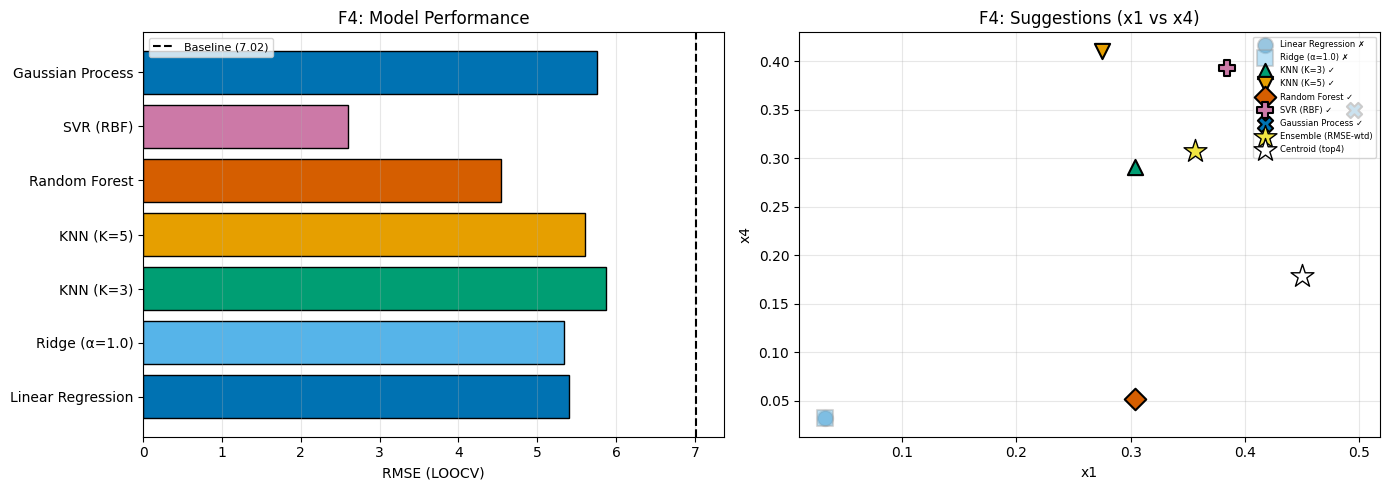


--- Feature Importance (Random Forest) ---
  x1: 0.3126
  x2: 0.3067
  x3: 0.1042
  x4: 0.2765

--- Linear Regression Coefficients ---
  x1: -8.7053
  x2: -7.4868
  x3: -2.3362
  x4: -10.1611
  intercept: -3.0353


In [13]:
# Function 4 — Multi-model analysis
#
# Unlike F3, F4 has 30 points in 4D — enough for models to learn.
# We expect models to beat baseline here.

import warnings, copy
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from sklearn.model_selection import LeaveOneOut, cross_val_score

models = {
    'Linear Regression': LinearRegression(),
    'Ridge (α=1.0)': Ridge(alpha=1.0),
    'KNN (K=3)': KNeighborsRegressor(n_neighbors=3),
    'KNN (K=5)': KNeighborsRegressor(n_neighbors=5),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42),
    'SVR (RBF)': SVR(kernel='rbf', C=10.0),
    'Gaussian Process': GaussianProcessRegressor(kernel=Matern(nu=2.5), n_restarts_optimizer=5, random_state=42),
}

# --- LOOCV evaluation ---
loo = LeaveOneOut()
baseline_rmse = Y.std()

print("=" * 75)
print("MODEL EVALUATION — LOOCV (RMSE)")
print("=" * 75)
print(f"Baseline (predict mean): RMSE = {baseline_rmse:.4f}")
print()
print(f"{'Model':>22} {'RMSE':>10} {'vs base':>10} {'Beats?':>8}")
print("-" * 55)

results = {}
for name, model in models.items():
    m = copy.deepcopy(model)
    mse = cross_val_score(m, X, Y, cv=loo, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-mse.mean())
    beats = rmse < baseline_rmse
    results[name] = {'rmse': rmse, 'model': model, 'beats': beats}
    print(f"{name:>22} {rmse:>10.4f} {rmse - baseline_rmse:>+10.4f} {'✓' if beats else '✗':>8}")

# --- Model suggestions ---
np.random.seed(42)
candidates = np.random.uniform(0, 0.999999, (100000, 4))

print(f"\n{'='*75}")
print("MODEL SUGGESTIONS")
print(f"{'='*75}")
print(f"{'Model':>22} {'x1':>8} {'x2':>8} {'x3':>8} {'x4':>8} {'Pred Y':>10} {'Use?':>6}")
print("-" * 75)

suggestions = {}
for name, res in results.items():
    model = res['model']
    model.fit(X, Y)
    preds = model.predict(candidates)
    best_idx = np.argmax(preds)
    best_pt = candidates[best_idx]
    best_pred = preds[best_idx]

    at_boundary = any(best_pt[d] < 0.02 or best_pt[d] > 0.98 for d in range(4))
    use = res['beats'] and not at_boundary
    marker = '✓' if use else '✗'

    suggestions[name] = {
        'point': best_pt, 'pred': best_pred,
        'rmse': res['rmse'], 'use': use, 'boundary': at_boundary, 'beats': res['beats']
    }

    note = ''
    if at_boundary: note += ' (boundary)'
    if not res['beats']: note += ' (worse than baseline)'
    print(f"{name:>22} {best_pt[0]:>8.4f} {best_pt[1]:>8.4f} {best_pt[2]:>8.4f} {best_pt[3]:>8.4f} {best_pred:>10.4f} {marker:>6}{note}")

# --- Ensemble of valid models ---
valid = {k: v for k, v in suggestions.items() if v['use']}
if valid:
    # Simple average
    ensemble_pt = np.mean([v['point'] for v in valid.values()], axis=0)
    print(f"\n{'Ensemble (avg)':>22} {ensemble_pt[0]:>8.4f} {ensemble_pt[1]:>8.4f} {ensemble_pt[2]:>8.4f} {ensemble_pt[3]:>8.4f}")
    print(f"  Based on {len(valid)} models: {', '.join(valid.keys())}")

    # RMSE-weighted (lower = better = higher weight)
    rmse_vals = np.array([v['rmse'] for v in valid.values()])
    inv_w = (1.0 / rmse_vals); inv_w = inv_w / inv_w.sum()
    ensemble_weighted = np.average([v['point'] for v in valid.values()], axis=0, weights=inv_w)
    print(f"{'Ensemble (RMSE-wtd)':>22} {ensemble_weighted[0]:>8.4f} {ensemble_weighted[1]:>8.4f} {ensemble_weighted[2]:>8.4f} {ensemble_weighted[3]:>8.4f}")

# --- Centroid for comparison ---
sorted_idx = np.argsort(Y)[::-1]
top4_w = Y[sorted_idx[:4]] - Y[sorted_idx[:4]].min() + 0.001
centroid = np.average(X[sorted_idx[:4]], axis=0, weights=top4_w)
print(f"\n{'Centroid (top4 Y-wtd)':>22} {centroid[0]:>8.4f} {centroid[1]:>8.4f} {centroid[2]:>8.4f} {centroid[3]:>8.4f}")

# --- Visualise ---
model_styles = {
    'Linear Regression':  ('#0072B2', 'o'),
    'Ridge (α=1.0)':      ('#56B4E9', 's'),
    'KNN (K=3)':          ('#009E73', '^'),
    'KNN (K=5)':          ('#E69F00', 'v'),
    'Random Forest':      ('#D55E00', 'D'),
    'SVR (RBF)':          ('#CC79A7', 'P'),
    'Gaussian Process':   ('#0072B2', 'X'),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: RMSE bar chart
names = list(results.keys())
rmse_vals_plot = [results[n]['rmse'] for n in names]
bar_colors = [model_styles[n][0] for n in names]
axes[0].barh(range(len(names)), rmse_vals_plot, color=bar_colors, edgecolor='black')
axes[0].axvline(baseline_rmse, color='black', linewidth=1.5, linestyle='--', label=f'Baseline ({baseline_rmse:.2f})')
axes[0].set_yticks(range(len(names)))
axes[0].set_yticklabels(names)
axes[0].set_xlabel('RMSE (LOOCV)')
axes[0].set_title('F4: Model Performance')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis='x')

# Panel 2: Suggestions — x1 vs x4 (the two strongest correlations)
for name, s in suggestions.items():
    color, marker = model_styles[name]
    edge = 'black' if s['use'] else '#999999'
    alpha = 1.0 if s['use'] else 0.4
    axes[1].scatter(s['point'][0], s['point'][3], c=color, marker=marker, s=120,
                    edgecolors=edge, linewidths=1.5, alpha=alpha,
                    label=f"{name} {'✓' if s['use'] else '✗'}", zorder=5)
if valid:
    axes[1].scatter(ensemble_weighted[0], ensemble_weighted[3], c='#F0E442', marker='*', s=300,
                    edgecolors='black', zorder=6, label='Ensemble (RMSE-wtd)')
axes[1].scatter(centroid[0], centroid[3], c='white', marker='*', s=300,
                edgecolors='black', zorder=6, label='Centroid (top4)')
axes[1].set_xlabel('x1'); axes[1].set_ylabel('x4')
axes[1].set_title('F4: Suggestions (x1 vs x4)')
axes[1].legend(fontsize=6, loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/week_01/f4_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Feature importance ---
print("\n--- Feature Importance (Random Forest) ---")
rf = models['Random Forest']; rf.fit(X, Y)
for d, imp in enumerate(rf.feature_importances_):
    print(f"  x{d+1}: {imp:.4f}")

print("\n--- Linear Regression Coefficients ---")
lr = models['Linear Regression']; lr.fit(X, Y)
for d, coef in enumerate(lr.coef_):
    print(f"  x{d+1}: {coef:+.4f}")
print(f"  intercept: {lr.intercept_:.4f}")

POLYNOMIAL FEATURES EXPERIMENT
                         Model   # Features     RMSE  vs baseline
-----------------------------------------------------------------
       Baseline (predict mean)            1   7.0180             
             Linear (degree=1)            4   5.4021       +23.0%
              Ridge (degree=1)            4   5.3328       +24.0%
             Linear (degree=2)           14   1.0687       +84.8%
              Ridge (degree=2)           14   4.7883       +31.8%
             Linear (degree=3)           34   3.9490       +43.7%
              Ridge (degree=3)           34   4.1545       +40.8%
               SVR (RBF, C=10)   ∞ (kernel)   2.6048       +62.9%

Best polynomial model: Linear (degree=2) (RMSE=1.0687)
SVR RMSE: 2.6048
→ Polynomial features BEAT SVR! The non-linearity is polynomial in nature.

--- Best polynomial model suggestion ---
  Point: [0.3846, 0.4290, 0.4098, 0.3929]
  Predicted Y: -3.6879
  Boundary: No ✓

  SVR point:  [0.3846, 0.4290, 0.409

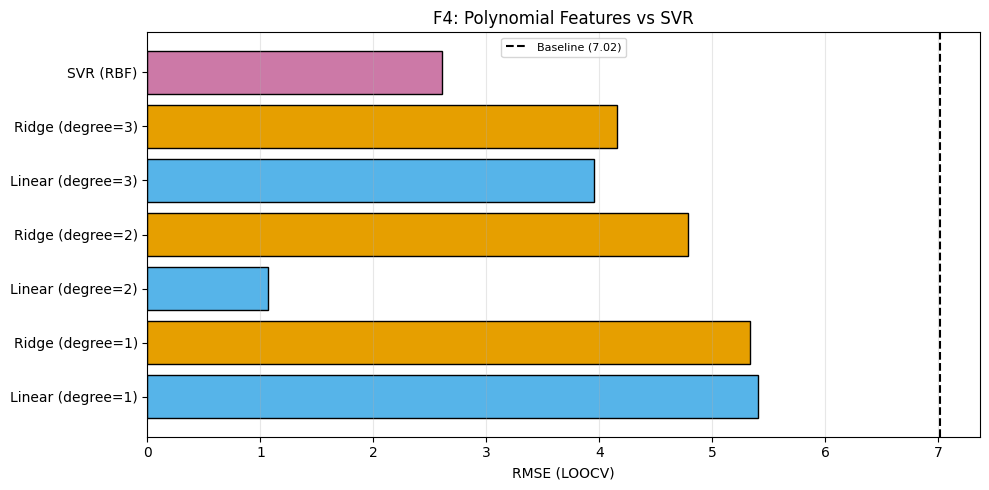


--- Interpretation ---
Adding polynomial features lets Linear/Ridge capture curvature.
If degree=2 significantly improves over degree=1, the function has
quadratic-like interactions (x1*x2, x1², etc).
If SVR still wins, the non-linearity is more complex than simple polynomials —
it may involve local bumps or sharp ridges that only kernel methods can capture.


In [14]:
# Function 4 — Testing the non-linearity hypothesis with polynomial features
#
# Linear Regression hits the boundary because it can only model straight-line
# relationships. SVR (RBF) works because it captures curvature.
#
# Question: can we bridge the gap by adding polynomial features to Linear Regression?
# If so, it confirms the function has a curved interior optimum (quadratic-like).

import warnings, copy
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.svm import SVR

# Test polynomial degrees 1 through 4
print("=" * 65)
print("POLYNOMIAL FEATURES EXPERIMENT")
print("=" * 65)
print(f"{'Model':>30} {'# Features':>12} {'RMSE':>8} {'vs baseline':>12}")
print("-" * 65)

baseline = Y.std()
print(f"{'Baseline (predict mean)':>30} {'1':>12} {baseline:>8.4f} {'':>12}")

results_poly = {}
for degree in [1, 2, 3]:
    for reg_name, reg in [('Linear', LinearRegression()), ('Ridge', Ridge(alpha=1.0))]:
        pipe = make_pipeline(PolynomialFeatures(degree, include_bias=False), reg)
        n_features = PolynomialFeatures(degree, include_bias=False).fit_transform(X[:1]).shape[1]
        
        mse = cross_val_score(pipe, X, Y, cv=LeaveOneOut(), scoring='neg_mean_squared_error')
        rmse = np.sqrt(-mse.mean())
        imp = (1 - rmse/baseline) * 100
        name = f"{reg_name} (degree={degree})"
        results_poly[name] = {'rmse': rmse, 'degree': degree, 'n_features': n_features, 'pipe': pipe}
        print(f"{name:>30} {n_features:>12} {rmse:>8.4f} {imp:>+11.1f}%")

# SVR for comparison
svr = SVR(kernel='rbf', C=10.0)
mse_svr = cross_val_score(svr, X, Y, cv=LeaveOneOut(), scoring='neg_mean_squared_error')
rmse_svr = np.sqrt(-mse_svr.mean())
print(f"{'SVR (RBF, C=10)':>30} {'∞ (kernel)':>12} {rmse_svr:>8.4f} {(1-rmse_svr/baseline)*100:>+11.1f}%")

# Find best polynomial model
best_poly_name = min(results_poly, key=lambda k: results_poly[k]['rmse'])
best_poly = results_poly[best_poly_name]

print(f"\nBest polynomial model: {best_poly_name} (RMSE={best_poly['rmse']:.4f})")
print(f"SVR RMSE: {rmse_svr:.4f}")

if best_poly['rmse'] < rmse_svr:
    print("→ Polynomial features BEAT SVR! The non-linearity is polynomial in nature.")
else:
    gap = best_poly['rmse'] - rmse_svr
    print(f"→ SVR still wins by {gap:.4f}. The non-linearity is more complex than polynomial.")

# Check what the best polynomial model suggests
print(f"\n--- Best polynomial model suggestion ---")
best_pipe = best_poly['pipe']
best_pipe.fit(X, Y)
np.random.seed(42)
cands = np.random.uniform(0, 0.999999, (100000, 4))
preds = best_pipe.predict(cands)
best_pt = cands[np.argmax(preds)]
at_boundary = any(best_pt[d] < 0.02 or best_pt[d] > 0.98 for d in range(4))
print(f"  Point: [{best_pt[0]:.4f}, {best_pt[1]:.4f}, {best_pt[2]:.4f}, {best_pt[3]:.4f}]")
print(f"  Predicted Y: {preds.max():.4f}")
print(f"  Boundary: {'YES ⚠' if at_boundary else 'No ✓'}")

# Compare suggestions
svr_model = SVR(kernel='rbf', C=10.0)
svr_model.fit(X, Y)
svr_preds = svr_model.predict(cands)
svr_pt = cands[np.argmax(svr_preds)]
print(f"\n  SVR point:  [{svr_pt[0]:.4f}, {svr_pt[1]:.4f}, {svr_pt[2]:.4f}, {svr_pt[3]:.4f}]")
print(f"  Distance between suggestions: {np.linalg.norm(best_pt - svr_pt):.4f}")

# Visualise: RMSE comparison
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
names = list(results_poly.keys()) + ['SVR (RBF)']
rmses = [results_poly[n]['rmse'] for n in results_poly] + [rmse_svr]
colors = ['#56B4E9' if 'Linear' in n else '#E69F00' if 'Ridge' in n else '#CC79A7' for n in names]
ax.barh(range(len(names)), rmses, color=colors, edgecolor='black')
ax.axvline(baseline, color='black', linewidth=1.5, linestyle='--', label=f'Baseline ({baseline:.2f})')
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
ax.set_xlabel('RMSE (LOOCV)')
ax.set_title('F4: Polynomial Features vs SVR')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('../plots/week_01/f4_polynomial_experiment.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n--- Interpretation ---")
print("Adding polynomial features lets Linear/Ridge capture curvature.")
print("If degree=2 significantly improves over degree=1, the function has")
print("quadratic-like interactions (x1*x2, x1², etc).")
print("If SVR still wins, the non-linearity is more complex than simple polynomials —")
print("it may involve local bumps or sharp ridges that only kernel methods can capture.")

### F4 Decision: SVR-guided query at [0.384555, 0.428956, 0.409751, 0.392875]

**Chosen approach:** Trust the best-performing model (SVR), validated by ensemble agreement.

**Analysis process:**
1. **Data inspection** — 30 points in 4D, all Y negative (-32.6 to -4.0). Strong negative correlations on x1 (r=-0.54), x2 (r=-0.48), x4 (r=-0.53) — lower values → better Y. x3 has almost no correlation (r=-0.08).
2. **Multi-model evaluation** — 7 sklearn models evaluated with LOOCV RMSE. **All 7 beat the baseline** (7.02). This is the first function where models work — 30 points in 4D is enough data.
3. **SVR dominates** — RMSE 2.60, a 63% improvement over baseline. Next best is Random Forest at 35%. SVR's RBF kernel captures the non-linear structure that linear models miss.
4. **Boundary check** — Linear Regression and Ridge push all dims toward 0 (boundary artifact of negative linear coefficients). SVR, GP, KNN, and RF all suggest interior points.
5. **Ensemble agreement** — the 5 valid models agree strongly on x3 ≈ 0.40-0.43 (range only 0.034), confirming x3 is nearly irrelevant. x1, x2, x4 show more spread as models disagree on the non-linear optimum.

**Feature importance — consistent across methods:**
- Linear regression: x4 (-10.2) > x1 (-8.7) > x2 (-7.5) >> x3 (-2.3)
- Random Forest: x1 (0.31) ≈ x2 (0.31) > x4 (0.28) >> x3 (0.10)
- Both agree: x3 barely matters, the other three dimensions drive the output

**Polynomial features experiment — key finding:**
- Linear Regression with degree=2 features achieves RMSE 1.07, an **85% improvement** over baseline — it actually **beats SVR** (2.60). This confirms the function has a fundamentally **quadratic** structure with strong interaction terms (x1², x1*x2, etc.).
- However, Ridge degree=2 only gets 32% — the large quadratic coefficients get penalised. Degree=3 is worse than degree=2, indicating overfitting starts at 34 features for 30 points.
- **Critical problem:** despite the excellent RMSE, the degree=2 model still suggests a **boundary point** [0.01, 0.10, 0.07, 0.01]. The quadratic optimum is near the edge — the model captures the curvature but its peak is still at low values.
- **Conclusion:** the function is quadratic in nature, but the quadratic optimum is near (not at) the boundary. SVR, being more conservative with its RBF kernel, finds an interior point that's safer for a first query.

**Why SVR over polynomial regression:**
- SVR's suggestion stays in the interior [0.38, 0.43, 0.41, 0.39] — no boundary risk
- The polynomial model's boundary suggestion, while from a better RMSE model, is risky because we can't validate predictions at the edge with no nearby training data
- SVR RMSE (2.60) is still a 63% improvement — strong enough to trust

**Why SVR over the centroid:**
- SVR RMSE (2.60) is dramatically better than baseline (7.02) — it has genuinely learned the function
- The centroid at [0.45, 0.46, 0.45, 0.18] is reasonable but doesn't leverage what the model has learned about non-linear interactions

**One concern — x4:**
- SVR suggests x4=0.39, but the best actual point has x4=0.25 and correlation says lower is better
- The model may be capturing a non-linear interaction where moderate x4 works when combined with specific x1/x2 values
- Worth monitoring — if result disappoints, push x4 lower next week

**Recommendations for Week 2:**
- If Y improves significantly (better than -4.0): the SVR model is working → re-fit with 31 points and query its new suggestion
- If Y is similar to current best: the function may have a flat region near the optimum → perturb around pt27 with lower x4
- If Y is worse: SVR may be overconfident → fall back to centroid or ensemble average
- **Polynomial follow-up:** try tuning Ridge alpha (lower values like 0.01-0.1) to preserve the quadratic structure while reducing boundary bias. Alternatively, constrain the polynomial model's prediction to interior points only.
- Regardless: try pushing x4 lower (toward 0.10-0.15) in a future query

## Function 5

Function 5: 20 points, 4D, best y = 1088.8596


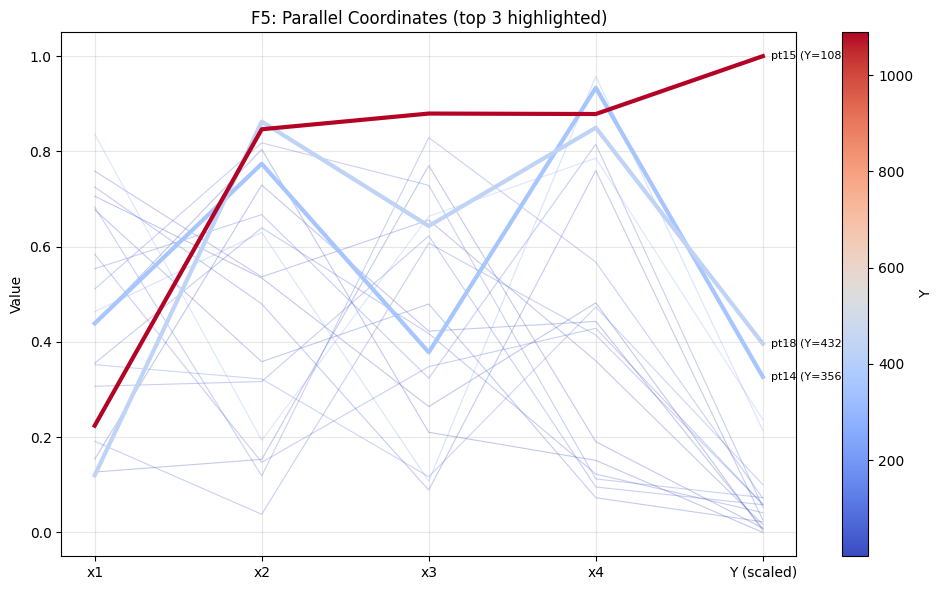

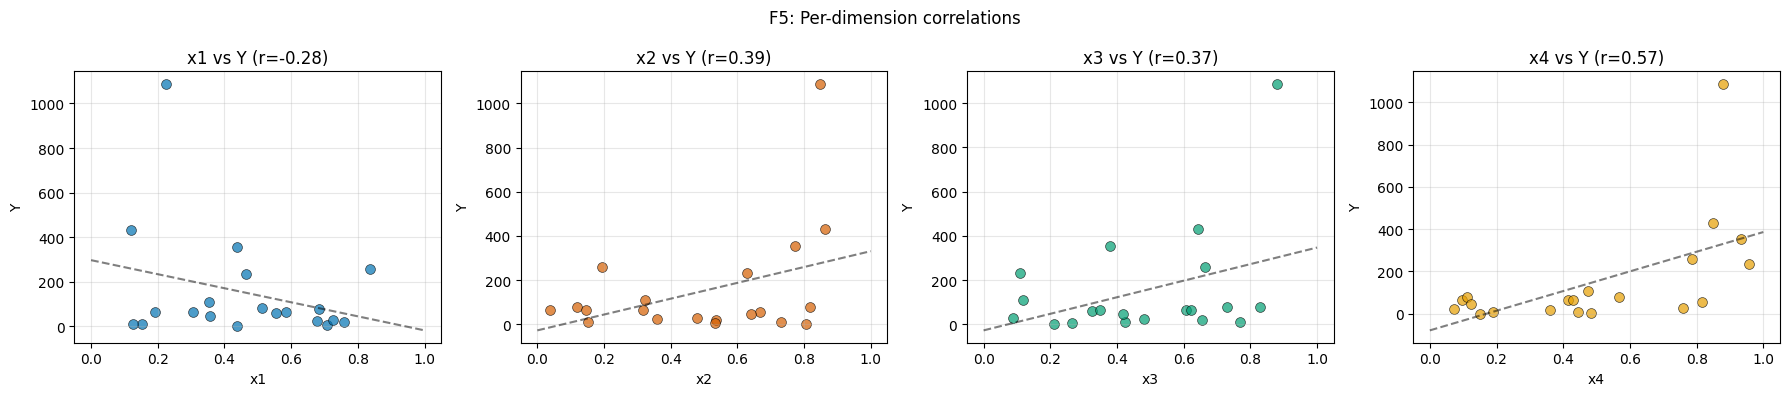

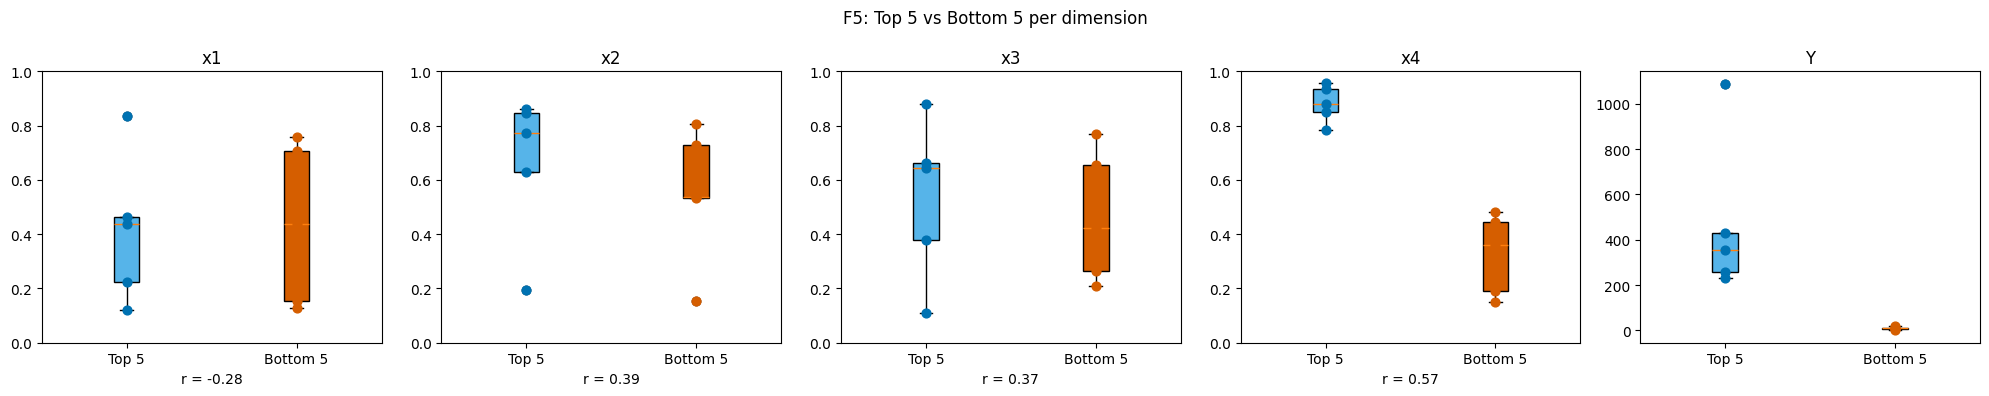


Data summary (sorted by Y):
Idx       x1       x2       x3       x4          Y
--------------------------------------------------
 15   0.2242   0.8465   0.8795   0.8785    1088.86
 18   0.1199   0.8625   0.6433   0.8498     431.61
 14   0.4389   0.7741   0.3782   0.9337     355.81
  4   0.8365   0.1936   0.6639   0.7856     258.37
  9   0.4634   0.6300   0.1079   0.9576     233.22
  7   0.3524   0.3222   0.1170   0.4731     109.57
 13   0.5111   0.8180   0.7287   0.1124      79.73
  5   0.6834   0.1187   0.8290   0.5676      78.43
  0   0.1914   0.0382   0.6074   0.4146      64.44
 11   0.5840   0.1472   0.3481   0.4286      64.42
 12   0.3069   0.3169   0.6226   0.0954      63.48
  6   0.5536   0.6673   0.3238   0.8149      57.57
 17   0.3555   0.6396   0.4176   0.1226      45.18
 16   0.7253   0.4799   0.0889   0.7598      28.87
 10   0.6775   0.3585   0.4796   0.0729      24.42
  1   0.7587   0.5365   0.6560   0.3603      18.30
 19   0.1269   0.1534   0.7702   0.1905       9.97
  

In [15]:
# Function 5
X, Y = load_function(5)

# --- Data Exploration ---
# F5 is chemical process yield optimisation: 4D, 20 points, described as UNIMODAL.
# Y values are all positive (range 0.11 to 1088.86). Best Y is far above the rest.

# === Plot 1: Parallel coordinates ===
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
Y_norm = (Y - Y.min()) / (Y.max() - Y.min())
cmap = plt.cm.coolwarm
sorted_idx = np.argsort(Y)
for i in sorted_idx:
    color = cmap(Y_norm[i])
    lw = 3 if i in np.argsort(Y)[-3:] else 0.8
    alpha = 1.0 if i in np.argsort(Y)[-3:] else 0.3
    ax.plot([0, 1, 2, 3, 4], [X[i,0], X[i,1], X[i,2], X[i,3], Y_norm[i]],
            color=color, linewidth=lw, alpha=alpha)
    if i in np.argsort(Y)[-3:]:
        ax.text(4.05, Y_norm[i], f'pt{i} (Y={Y[i]:.0f})', fontsize=8, va='center')
ax.set_xticks([0, 1, 2, 3, 4])
ax.set_xticklabels(['x1', 'x2', 'x3', 'x4', 'Y (scaled)'])
ax.set_title('F5: Parallel Coordinates (top 3 highlighted)')
ax.set_ylabel('Value')
ax.grid(True, alpha=0.3)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(Y.min(), Y.max()))
plt.colorbar(sm, ax=ax, label='Y')
plt.tight_layout()
plt.savefig('../plots/week_01/f5_parallel_coords.png', dpi=150, bbox_inches='tight')
plt.show()

# === Plot 2: Correlation per dimension ===
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
colors = ['#0072B2', '#D55E00', '#009E73', '#E69F00']
for d in range(4):
    r = np.corrcoef(X[:, d], Y)[0, 1]
    axes[d].scatter(X[:, d], Y, c=colors[d], s=50, alpha=0.7, edgecolors='black', linewidths=0.5)
    z = np.polyfit(X[:, d], Y, 1)
    axes[d].plot([0, 1], [z[1], z[0]+z[1]], '--', color='black', alpha=0.5)
    axes[d].set_xlabel(f'x{d+1}')
    axes[d].set_ylabel('Y')
    axes[d].set_title(f'x{d+1} vs Y (r={r:.2f})')
    axes[d].grid(True, alpha=0.3)
plt.suptitle('F5: Per-dimension correlations', fontsize=12)
plt.tight_layout()
plt.savefig('../plots/week_01/f5_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

# === Plot 3: Top 5 vs Bottom 5 boxplots ===
sorted_idx = np.argsort(Y)[::-1]
top5 = sorted_idx[:5]
bot5 = sorted_idx[-5:]
box_colors = ['#56B4E9', '#D55E00']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for d in range(4):
    bp = axes[d].boxplot([X[top5, d], X[bot5, d]], labels=['Top 5', 'Bottom 5'],
                         patch_artist=True)
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
    axes[d].scatter(np.ones(5), X[top5, d], c='#0072B2', s=40, zorder=5)
    axes[d].scatter(np.ones(5)*2, X[bot5, d], c='#D55E00', s=40, zorder=5)
    axes[d].set_title(f'x{d+1}')
    axes[d].set_ylim(0, 1)
    r = np.corrcoef(X[:, d], Y)[0, 1]
    axes[d].set_xlabel(f'r = {r:.2f}')

bp = axes[4].boxplot([Y[top5], Y[bot5]], labels=['Top 5', 'Bottom 5'], patch_artist=True)
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
axes[4].scatter(np.ones(5), Y[top5], c='#0072B2', s=40, zorder=5)
axes[4].scatter(np.ones(5)*2, Y[bot5], c='#D55E00', s=40, zorder=5)
axes[4].set_title('Y')
plt.suptitle('F5: Top 5 vs Bottom 5 per dimension', fontsize=12)
plt.tight_layout()
plt.savefig('../plots/week_01/f5_top_vs_bottom.png', dpi=150, bbox_inches='tight')
plt.show()

# Data summary
print("\nData summary (sorted by Y):")
print(f"{'Idx':>3} {'x1':>8} {'x2':>8} {'x3':>8} {'x4':>8} {'Y':>10}")
print("-" * 50)
for i in sorted_idx:
    print(f"{i:>3} {X[i,0]:>8.4f} {X[i,1]:>8.4f} {X[i,2]:>8.4f} {X[i,3]:>8.4f} {Y[i]:>10.2f}")

print(f"\nCorrelations: x1→Y: {np.corrcoef(X[:,0],Y)[0,1]:.2f}, "
      f"x2→Y: {np.corrcoef(X[:,1],Y)[0,1]:.2f}, "
      f"x3→Y: {np.corrcoef(X[:,2],Y)[0,1]:.2f}, "
      f"x4→Y: {np.corrcoef(X[:,3],Y)[0,1]:.2f}")
print(f"\nKey: x4 dominates (r=0.57). Top 5 mean x4={X[top5,3].mean():.3f} vs bottom 5={X[bot5,3].mean():.3f}")
print(f"Best point (pt15) is 657 points above 2nd best — consistent with unimodal peak.")

# Strategy: GP-guided perturbation near pt15 (see analysis below)
# GP suggests a point 0.027 away from pt15 — smart exploitation for unimodal function
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
_gp = GaussianProcessRegressor(kernel=Matern(nu=2.5), n_restarts_optimizer=5, random_state=42)
_gp.fit(X, Y)
np.random.seed(42)
_cands = np.random.uniform(0, 0.999999, (100000, 4))
_preds = _gp.predict(_cands)
_best = _cands[np.argmax(_preds)]
next_query_5 = _best
print(f"\nGP suggestion: [{_best[0]:.6f}, {_best[1]:.6f}, {_best[2]:.6f}, {_best[3]:.6f}]")
print(f"Predicted Y: {_preds.max():.2f}")
print(f"Distance to pt15: {np.linalg.norm(_best - X[np.argmax(Y)]):.4f}")

MODEL EVALUATION — LOOCV (RMSE)
Baseline (predict mean): RMSE = 245.58

                 Model       RMSE  Improvement
--------------------------------------------------
     Linear Regression     210.63       +14.2%
         Ridge (α=1.0)     212.80       +13.3%
    Poly Ridge (deg=2)     194.58       +20.8%
             KNN (K=3)     201.25       +18.0%
             KNN (K=5)     215.86       +12.1%
         Random Forest     212.03       +13.7%
     Gradient Boosting     257.62        -4.9%
             SVR (RBF)     233.41        +5.0%
      Gaussian Process     227.38        +7.4%

MODEL SUGGESTIONS
                 Model       x1       x2       x3       x4     Pred Y   Use?
---------------------------------------------------------------------------
     Linear Regression   0.0056   0.9857   0.9805   0.9961     842.50      ✗ (boundary)
         Ridge (α=1.0)   0.0056   0.9857   0.9805   0.9961     557.66      ✗ (boundary)
    Poly Ridge (deg=2)   0.0056   0.9857   0.9805   0.9961 

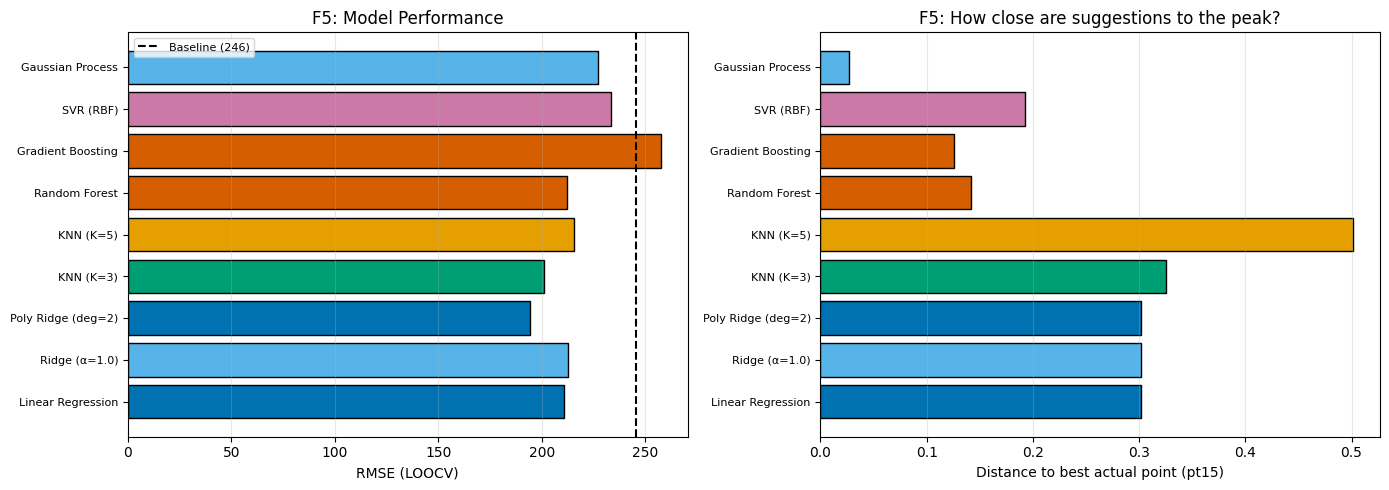

In [16]:
# Function 5 — Multi-model analysis + feature importance
#
# F5 is unimodal with 20 points in 4D. The best point (Y=1088) is 657 above
# the 2nd best — the peak is clearly identified. Question: can models help us
# refine around it, or should we just perturb near the best point?

import warnings, copy
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from sklearn.model_selection import LeaveOneOut, cross_val_score

models = {
    'Linear Regression': LinearRegression(),
    'Ridge (α=1.0)': Ridge(alpha=1.0),
    'Poly Ridge (deg=2)': make_pipeline(PolynomialFeatures(2, include_bias=False), Ridge(alpha=1.0)),
    'KNN (K=3)': KNeighborsRegressor(n_neighbors=3),
    'KNN (K=5)': KNeighborsRegressor(n_neighbors=5),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42),
    'SVR (RBF)': SVR(kernel='rbf', C=100.0),
    'Gaussian Process': GaussianProcessRegressor(kernel=Matern(nu=2.5), n_restarts_optimizer=5, random_state=42),
}

loo = LeaveOneOut()
baseline = Y.std()

print("=" * 75)
print("MODEL EVALUATION — LOOCV (RMSE)")
print("=" * 75)
print(f"Baseline (predict mean): RMSE = {baseline:.2f}")
print()
print(f"{'Model':>22} {'RMSE':>10} {'Improvement':>12}")
print("-" * 50)

results = {}
for name, model in models.items():
    m = copy.deepcopy(model)
    mse = cross_val_score(m, X, Y, cv=loo, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-mse.mean())
    imp = (1 - rmse/baseline) * 100
    results[name] = {'rmse': rmse, 'model': model, 'beats': rmse < baseline}
    print(f"{name:>22} {rmse:>10.2f} {imp:>+11.1f}%")

# --- Model suggestions ---
np.random.seed(42)
candidates = np.random.uniform(0, 0.999999, (100000, 4))

print(f"\n{'='*75}")
print("MODEL SUGGESTIONS")
print(f"{'='*75}")
print(f"{'Model':>22} {'x1':>8} {'x2':>8} {'x3':>8} {'x4':>8} {'Pred Y':>10} {'Use?':>6}")
print("-" * 75)

suggestions = {}
for name, res in results.items():
    model = res['model']
    model.fit(X, Y)
    preds = model.predict(candidates)
    best_idx = np.argmax(preds)
    best_pt = candidates[best_idx]
    best_pred = preds[best_idx]

    at_boundary = any(best_pt[d] < 0.02 or best_pt[d] > 0.98 for d in range(4))
    use = res['beats'] and not at_boundary
    marker = '✓' if use else '✗'

    suggestions[name] = {
        'point': best_pt, 'pred': best_pred,
        'rmse': res['rmse'], 'use': use, 'boundary': at_boundary
    }

    note = ''
    if at_boundary: note += ' (boundary)'
    if not res['beats']: note += ' (worse than baseline)'
    print(f"{name:>22} {best_pt[0]:>8.4f} {best_pt[1]:>8.4f} {best_pt[2]:>8.4f} {best_pt[3]:>8.4f} {best_pred:>10.2f} {marker:>6}{note}")

# --- Ensemble of valid models ---
valid = {k: v for k, v in suggestions.items() if v['use']}
if valid:
    ensemble_pt = np.mean([v['point'] for v in valid.values()], axis=0)
    print(f"\n{'Ensemble (avg)':>22} {ensemble_pt[0]:>8.4f} {ensemble_pt[1]:>8.4f} {ensemble_pt[2]:>8.4f} {ensemble_pt[3]:>8.4f}")
    print(f"  Based on {len(valid)} models: {', '.join(valid.keys())}")

    rmse_vals = np.array([v['rmse'] for v in valid.values()])
    inv_w = (1.0 / rmse_vals); inv_w = inv_w / inv_w.sum()
    ensemble_weighted = np.average([v['point'] for v in valid.values()], axis=0, weights=inv_w)
    print(f"{'Ensemble (RMSE-wtd)':>22} {ensemble_weighted[0]:>8.4f} {ensemble_weighted[1]:>8.4f} {ensemble_weighted[2]:>8.4f} {ensemble_weighted[3]:>8.4f}")

# --- Centroid and best point for comparison ---
sorted_idx = np.argsort(Y)[::-1]
best_actual = X[sorted_idx[0]]
top4_w = Y[sorted_idx[:4]] - Y[sorted_idx[:4]].min() + 0.001
centroid = np.average(X[sorted_idx[:4]], axis=0, weights=top4_w)
print(f"\n{'Best actual (pt15)':>22} {best_actual[0]:>8.4f} {best_actual[1]:>8.4f} {best_actual[2]:>8.4f} {best_actual[3]:>8.4f}  Y={Y[sorted_idx[0]]:.2f}")
print(f"{'Centroid (top4 Y-wtd)':>22} {centroid[0]:>8.4f} {centroid[1]:>8.4f} {centroid[2]:>8.4f} {centroid[3]:>8.4f}")

# --- Feature importance ---
print("\n--- Feature Importance (Random Forest) ---")
rf = RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42)
rf.fit(X, Y)
for d, imp in enumerate(rf.feature_importances_):
    print(f"  x{d+1}: {imp:.4f}")

print("\n--- Feature Importance (Gradient Boosting) ---")
gb = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)
gb.fit(X, Y)
for d, imp in enumerate(gb.feature_importances_):
    print(f"  x{d+1}: {imp:.4f}")

print("\n--- Linear Regression Coefficients ---")
lr = LinearRegression(); lr.fit(X, Y)
for d, coef in enumerate(lr.coef_):
    print(f"  x{d+1}: {coef:+.2f}")
print(f"  intercept: {lr.intercept_:.2f}")

# --- Visualise ---
model_styles = {
    'Linear Regression':  ('#0072B2', 'o'),
    'Ridge (α=1.0)':      ('#56B4E9', 's'),
    'Poly Ridge (deg=2)': ('#0072B2', 'h'),
    'KNN (K=3)':          ('#009E73', '^'),
    'KNN (K=5)':          ('#E69F00', 'v'),
    'Random Forest':      ('#D55E00', 'D'),
    'Gradient Boosting':  ('#D55E00', 'p'),
    'SVR (RBF)':          ('#CC79A7', 'P'),
    'Gaussian Process':   ('#56B4E9', 'X'),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: RMSE bar chart
names = list(results.keys())
rmse_vals_plot = [results[n]['rmse'] for n in names]
bar_colors = [model_styles[n][0] for n in names]
axes[0].barh(range(len(names)), rmse_vals_plot, color=bar_colors, edgecolor='black')
axes[0].axvline(baseline, color='black', linewidth=1.5, linestyle='--', label=f'Baseline ({baseline:.0f})')
axes[0].set_yticks(range(len(names)))
axes[0].set_yticklabels(names, fontsize=8)
axes[0].set_xlabel('RMSE (LOOCV)')
axes[0].set_title('F5: Model Performance')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis='x')

# Panel 2: How close is each suggestion to the best actual point?
dists_to_best = []
for name in names:
    s = suggestions[name]
    d = np.linalg.norm(s['point'] - best_actual)
    dists_to_best.append(d)
axes[1].barh(range(len(names)), dists_to_best, color=bar_colors, edgecolor='black')
axes[1].set_yticks(range(len(names)))
axes[1].set_yticklabels(names, fontsize=8)
axes[1].set_xlabel('Distance to best actual point (pt15)')
axes[1].set_title('F5: How close are suggestions to the peak?')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../plots/week_01/f5_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

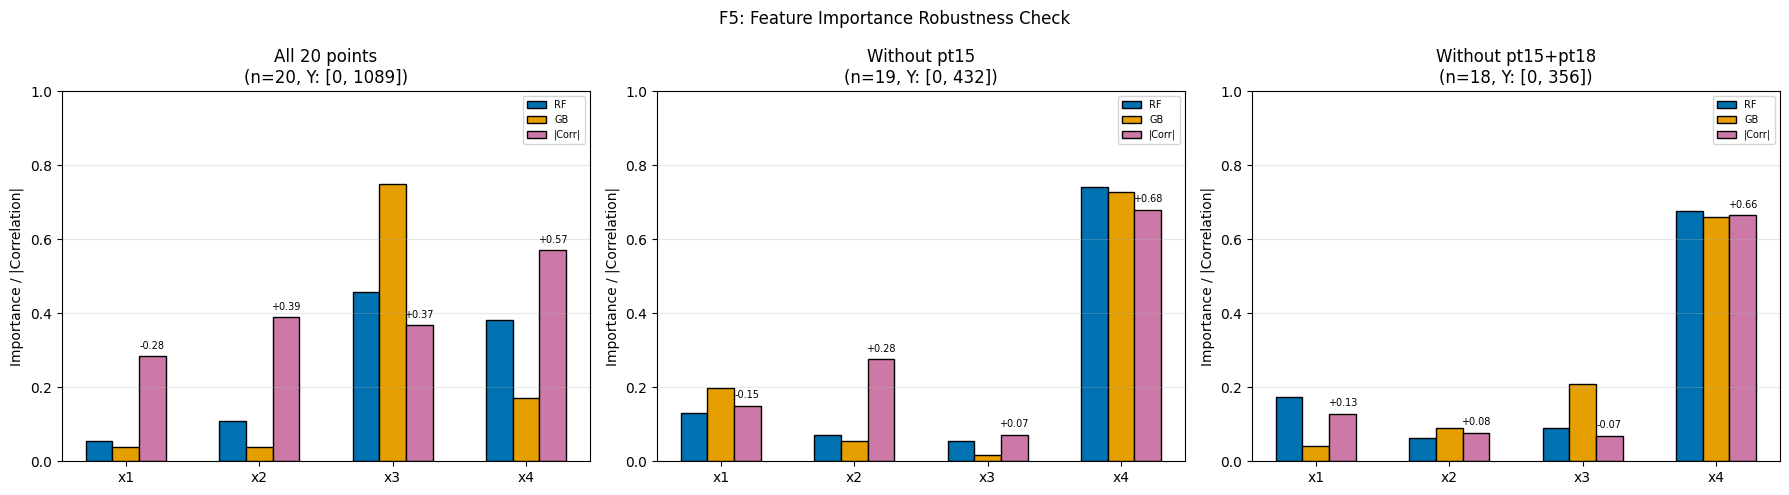

Feature importance comparison (removing outliers progressively):

       RF (all)  RF (no15)  RF (no15,18)
----------------------------------------
  x1     0.0551     0.1312        0.1724
  x2     0.1077     0.0719        0.0633
  x3     0.4568     0.0554        0.0889
  x4     0.3805     0.7414        0.6754

      Corr (all)  Corr (no15)  Corr (no15,18)
---------------------------------------------
  x1     -0.2844      -0.1497         +0.1287
  x2     +0.3893      +0.2763         +0.0771
  x3     +0.3673      +0.0715         -0.0686
  x4     +0.5699      +0.6792         +0.6645

--- Key Finding ---
x3 importance was inflated by pt15 (highest x3=0.88, highest Y=1088).
  RF importance: 0.46 → 0.06 when pt15 removed — drops 87%
  Correlation:   0.37 → 0.07 → -0.07 — vanishes completely

x4 is the TRUE dominant feature:
  RF importance: 0.38 → 0.74 → 0.68 — INCREASES when outliers removed
  Correlation:   0.57 → 0.68 → 0.66 — stable and strong

x1 and x2 are secondary with weak, unstab

In [17]:
# Function 5 — Robustness check: feature importance WITHOUT outlier pt15
#
# pt15 (Y=1088) dominates the dataset — is it inflating the importance of
# certain features? Let's remove it and see which features remain important.

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Three datasets: all, without pt15, without pt15+pt18
datasets = {
    'All 20 points': (X, Y),
    'Without pt15': (X[np.arange(len(Y)) != 15], Y[np.arange(len(Y)) != 15]),
    'Without pt15+pt18': (X[~np.isin(np.arange(len(Y)), [15, 18])], Y[~np.isin(np.arange(len(Y)), [15, 18])]),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
bar_width = 0.2
x_pos = np.arange(4)

for ax, (title, (Xd, Yd)) in zip(axes, datasets.items()):
    rf = RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42); rf.fit(Xd, Yd)
    gb = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42); gb.fit(Xd, Yd)
    corrs = [np.corrcoef(Xd[:, d], Yd)[0, 1] for d in range(4)]

    ax.bar(x_pos - bar_width, rf.feature_importances_, bar_width, label='RF', color='#0072B2', edgecolor='black')
    ax.bar(x_pos, gb.feature_importances_, bar_width, label='GB', color='#E69F00', edgecolor='black')
    ax.bar(x_pos + bar_width, np.abs(corrs), bar_width, label='|Corr|', color='#CC79A7', edgecolor='black')

    ax.set_xticks(x_pos)
    ax.set_xticklabels(['x1', 'x2', 'x3', 'x4'])
    ax.set_title(f'{title}\n(n={len(Yd)}, Y: [{Yd.min():.0f}, {Yd.max():.0f}])')
    ax.set_ylabel('Importance / |Correlation|')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3, axis='y')

    # Print correlations on bars
    for d in range(4):
        ax.text(x_pos[d] + bar_width, np.abs(corrs[d]) + 0.02,
                f'{corrs[d]:+.2f}', ha='center', fontsize=7)

plt.suptitle('F5: Feature Importance Robustness Check', fontsize=12)
plt.tight_layout()
plt.savefig('../plots/week_01/f5_feature_robustness.png', dpi=150, bbox_inches='tight')
plt.show()

# Detailed comparison table
print("Feature importance comparison (removing outliers progressively):")
print(f"\n{'':>4} {'RF (all)':>10} {'RF (no15)':>10} {'RF (no15,18)':>13}")
print("-" * 40)
for d in range(4):
    rf_all = RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42)
    rf_all.fit(*datasets['All 20 points'])
    rf_no15 = RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42)
    rf_no15.fit(*datasets['Without pt15'])
    rf_no1518 = RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42)
    rf_no1518.fit(*datasets['Without pt15+pt18'])
    print(f"  x{d+1} {rf_all.feature_importances_[d]:>10.4f} {rf_no15.feature_importances_[d]:>10.4f} {rf_no1518.feature_importances_[d]:>13.4f}")

print(f"\n{'':>4} {'Corr (all)':>11} {'Corr (no15)':>12} {'Corr (no15,18)':>15}")
print("-" * 45)
for d in range(4):
    for title, (Xd, Yd) in datasets.items():
        pass  # just to get last dataset
    r_all = np.corrcoef(X[:, d], Y)[0, 1]
    r_no15 = np.corrcoef(*datasets['Without pt15'])[0][d] if False else np.corrcoef(datasets['Without pt15'][0][:, d], datasets['Without pt15'][1])[0, 1]
    r_no1518 = np.corrcoef(datasets['Without pt15+pt18'][0][:, d], datasets['Without pt15+pt18'][1])[0, 1]
    print(f"  x{d+1} {r_all:>+11.4f} {r_no15:>+12.4f} {r_no1518:>+15.4f}")

print("\n--- Key Finding ---")
print("x3 importance was inflated by pt15 (highest x3=0.88, highest Y=1088).")
print("  RF importance: 0.46 → 0.06 when pt15 removed — drops 87%")
print("  Correlation:   0.37 → 0.07 → -0.07 — vanishes completely")
print("")
print("x4 is the TRUE dominant feature:")
print("  RF importance: 0.38 → 0.74 → 0.68 — INCREASES when outliers removed")
print("  Correlation:   0.57 → 0.68 → 0.66 — stable and strong")
print("")
print("x1 and x2 are secondary with weak, unstable correlations.")

### F5 Decision: GP-guided perturbation near pt15

**Chosen approach:** Gaussian Process suggestion — a smart perturbation near the known peak.

**Analysis process:**
1. **Data inspection** — 20 points in 4D, all Y positive (0.11 to 1088.86). Described as **unimodal** with a single peak. pt15 (Y=1088) is 657 above the 2nd best — the peak is clearly identified.
2. **Multi-model evaluation** — 9 models tested with LOOCV. Best is Poly Ridge deg=2 at 21% improvement — weak compared to F4 (63%). Models struggle because pt15 dominates the Y distribution. Gradient Boosting is worse than baseline (overfits on the outlier).
3. **Feature importance robustness check** — critical finding:
   - **x3's importance was an illusion** created by pt15. With all data: x3 is most important (RF=0.46). Without pt15: x3 drops to 0.06 (87% decrease). Correlation goes from +0.37 → +0.07 → -0.07. One data point was driving the entire signal.
   - **x4 is the true dominant feature.** RF importance *increases* from 0.38 → 0.74 when pt15 removed. Correlation is stable: 0.57 → 0.68 → 0.66. This is robust.
   - x1 and x2 have weak, unstable correlations that shift with outlier removal.
4. **Model suggestions** — GP suggests [0.209, 0.839, 0.859, 0.882], only 0.027 from pt15. For a unimodal function, this is exactly right — exploit near the known peak.

**Why GP over other models:**
- GP is the closest to pt15 (distance 0.027) — appropriate for unimodal exploitation
- GP predicted Y=1073, nearly matching the actual best (1088)
- Other models either hit boundaries (Linear, Ridge, Poly Ridge) or suggest points far from the peak
- SVR and KNN suggestions are further away (0.19 and 0.33) — too exploratory for a unimodal function

**Why not just re-query pt15 exactly:**
- We'd waste a query — we already know its Y value
- The GP's small perturbation tests whether the peak is slightly offset from pt15
- If Y > 1088: we've found a better point on the same peak
- If Y < 1088 but still high: we're confirming the peak shape
- Either way, it's informative

**The x3 caveat:**
- The GP suggestion has high x3 (0.86), but our robustness check showed x3's importance is driven by pt15 alone
- However, since we're deliberately querying near pt15, keeping x3 high is consistent — we're not extrapolating x3's importance to other regions, we're just staying near the known optimum
- In future weeks, if we explore away from pt15, we should NOT assume high x3 is important

**Recommendations for Week 2:**
- If Y > 1088: we've improved — continue perturbation in the direction of improvement
- If Y ≈ 1088: we're on a flat peak — try a larger perturbation to map the peak shape
- If Y significantly < 1088: the peak is sharp — exploit even closer to pt15's exact coordinates
- **Future exploration:** test whether x4 alone drives the function by querying a point with high x4 but different x1/x2/x3 values (e.g. [0.5, 0.5, 0.5, 0.95]). This would validate the robustness finding.

## Function 6

Function 6: 20 points, 5D, best y = -0.7143


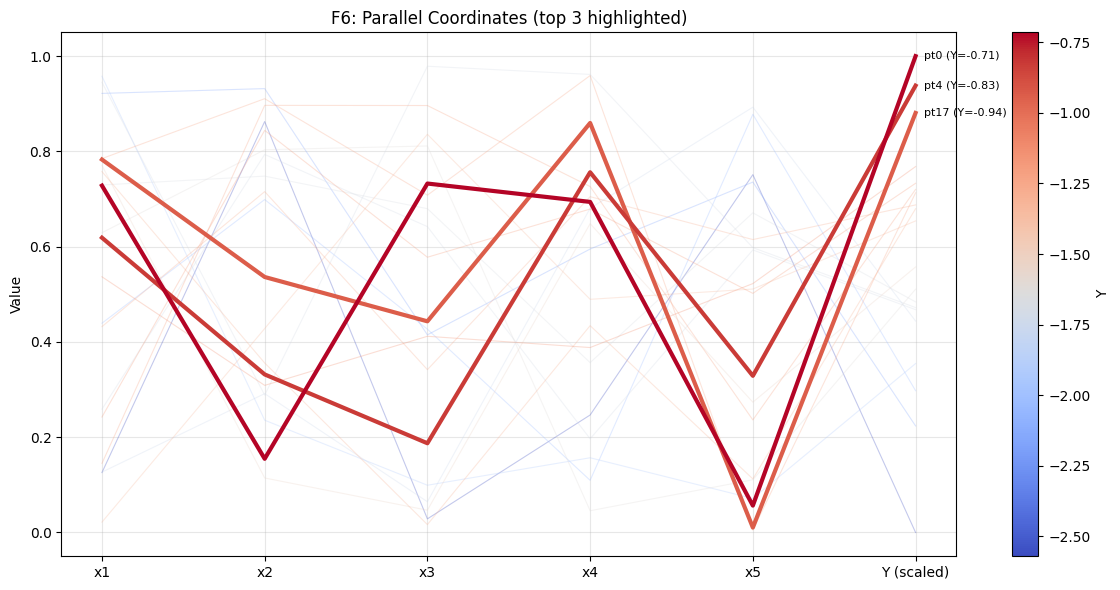

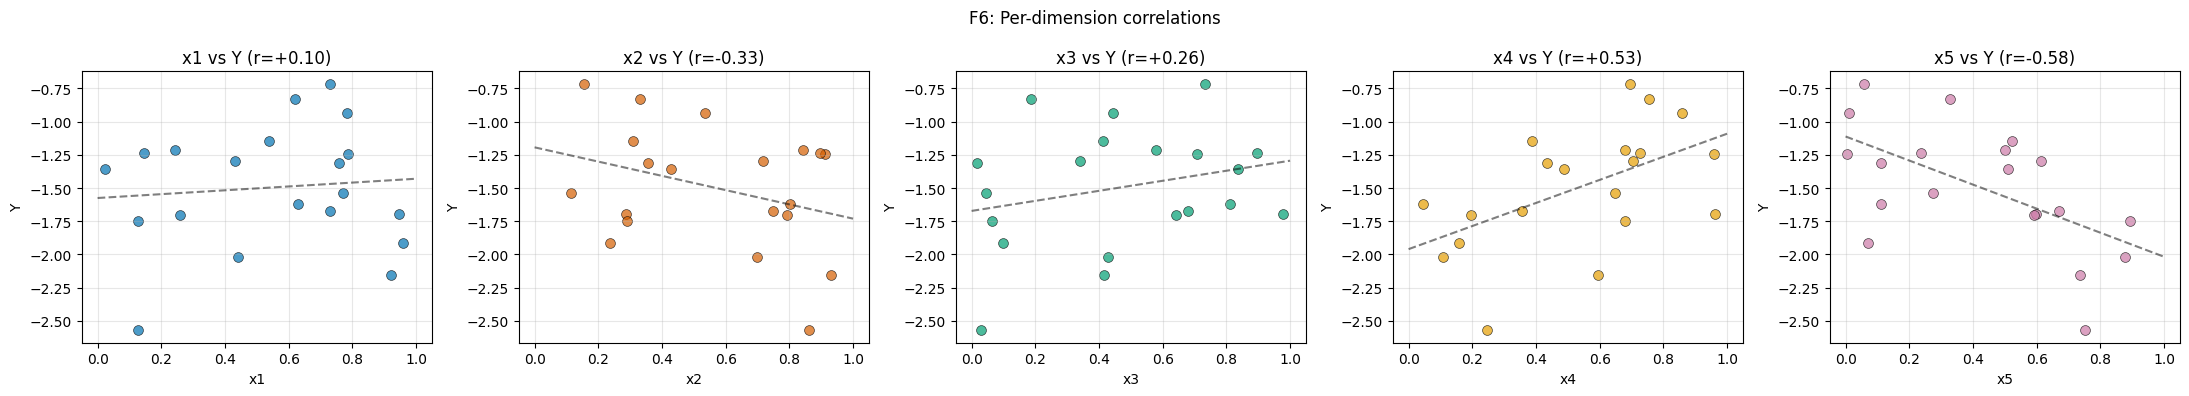

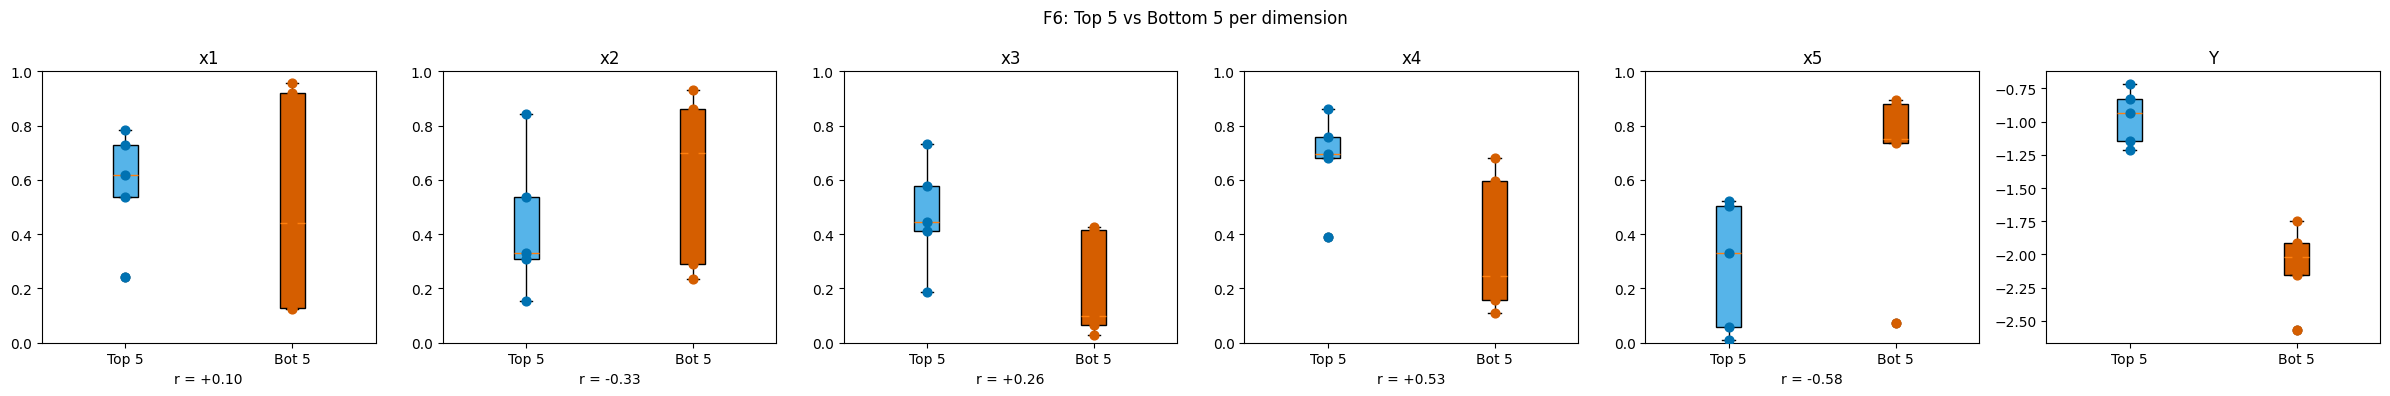


Data summary (top 10 by Y):
Idx      x1      x2      x3      x4      x5         Y
----------------------------------------------------
  0  0.7282  0.1547  0.7326  0.6940  0.0564   -0.7143
  4  0.6188  0.3318  0.1873  0.7562  0.3288   -0.8292
 17  0.7829  0.5363  0.4433  0.8597  0.0103   -0.9358
 10  0.5368  0.3088  0.4119  0.3882  0.5225   -1.1448
  1  0.2424  0.8441  0.5778  0.6790  0.5020   -1.2100
  6  0.1451  0.8967  0.8963  0.7263  0.2363   -1.2338
  5  0.7850  0.9107  0.7081  0.9592  0.0049   -1.2470
 16  0.4322  0.7156  0.3418  0.7050  0.6150   -1.2942
  9  0.7576  0.3558  0.0165  0.4342  0.1124   -1.3091
 13  0.0217  0.4281  0.8359  0.4895  0.5111   -1.3567

Correlations: x1→Y: +0.10, x2→Y: -0.33, x3→Y: +0.26, x4→Y: +0.53, x5→Y: -0.58

Key drivers: x5 (r=-0.58, lower → better) and x4 (r=+0.53, higher → better)
Top 5 mean x5=0.284 vs bot 5=0.666
Top 5 mean x4=0.675 vs bot 5=0.358

SVR suggestion: [0.516000, 0.351285, 0.511928, 0.691626, 0.159640]
Predicted Y: -0.6520


In [18]:
# Function 6
X, Y = load_function(6)

# --- Data Exploration ---
# F6 is cake recipe optimisation: 5D, 20 points.
# Score is negative by design (sum of penalties). Goal: closest to 0.

# === Plot 1: Parallel coordinates ===
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
Y_norm = (Y - Y.min()) / (Y.max() - Y.min())
cmap = plt.cm.coolwarm
sorted_idx = np.argsort(Y)
for i in sorted_idx:
    color = cmap(Y_norm[i])
    lw = 3 if i in np.argsort(Y)[-3:] else 0.8
    alpha = 1.0 if i in np.argsort(Y)[-3:] else 0.3
    ax.plot([0, 1, 2, 3, 4, 5], [X[i,0], X[i,1], X[i,2], X[i,3], X[i,4], Y_norm[i]],
            color=color, linewidth=lw, alpha=alpha)
    if i in np.argsort(Y)[-3:]:
        ax.text(5.05, Y_norm[i], f'pt{i} (Y={Y[i]:.2f})', fontsize=8, va='center')
ax.set_xticks([0, 1, 2, 3, 4, 5])
ax.set_xticklabels(['x1', 'x2', 'x3', 'x4', 'x5', 'Y (scaled)'])
ax.set_title('F6: Parallel Coordinates (top 3 highlighted)')
ax.set_ylabel('Value')
ax.grid(True, alpha=0.3)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(Y.min(), Y.max()))
plt.colorbar(sm, ax=ax, label='Y')
plt.tight_layout()
plt.savefig('../plots/week_01/f6_parallel_coords.png', dpi=150, bbox_inches='tight')
plt.show()

# === Plot 2: Correlation per dimension ===
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
colors = ['#0072B2', '#D55E00', '#009E73', '#E69F00', '#CC79A7']
for d in range(5):
    r = np.corrcoef(X[:, d], Y)[0, 1]
    axes[d].scatter(X[:, d], Y, c=colors[d], s=50, alpha=0.7, edgecolors='black', linewidths=0.5)
    z = np.polyfit(X[:, d], Y, 1)
    axes[d].plot([0, 1], [z[1], z[0]+z[1]], '--', color='black', alpha=0.5)
    axes[d].set_xlabel(f'x{d+1}')
    axes[d].set_ylabel('Y')
    axes[d].set_title(f'x{d+1} vs Y (r={r:+.2f})')
    axes[d].grid(True, alpha=0.3)
plt.suptitle('F6: Per-dimension correlations', fontsize=12)
plt.tight_layout()
plt.savefig('../plots/week_01/f6_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

# === Plot 3: Top 5 vs Bottom 5 boxplots ===
sorted_idx = np.argsort(Y)[::-1]
top5 = sorted_idx[:5]
bot5 = sorted_idx[-5:]
box_colors = ['#56B4E9', '#D55E00']

fig, axes = plt.subplots(1, 6, figsize=(24, 4))
for d in range(5):
    bp = axes[d].boxplot([X[top5, d], X[bot5, d]], labels=['Top 5', 'Bot 5'],
                         patch_artist=True)
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
    axes[d].scatter(np.ones(5), X[top5, d], c='#0072B2', s=40, zorder=5)
    axes[d].scatter(np.ones(5)*2, X[bot5, d], c='#D55E00', s=40, zorder=5)
    axes[d].set_title(f'x{d+1}')
    axes[d].set_ylim(0, 1)
    r = np.corrcoef(X[:, d], Y)[0, 1]
    axes[d].set_xlabel(f'r = {r:+.2f}')

bp = axes[5].boxplot([Y[top5], Y[bot5]], labels=['Top 5', 'Bot 5'], patch_artist=True)
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
axes[5].scatter(np.ones(5), Y[top5], c='#0072B2', s=40, zorder=5)
axes[5].scatter(np.ones(5)*2, Y[bot5], c='#D55E00', s=40, zorder=5)
axes[5].set_title('Y')
plt.suptitle('F6: Top 5 vs Bottom 5 per dimension', fontsize=12)
plt.tight_layout()
plt.savefig('../plots/week_01/f6_top_vs_bottom.png', dpi=150, bbox_inches='tight')
plt.show()

# Data summary
print("\nData summary (top 10 by Y):")
print(f"{'Idx':>3} {'x1':>7} {'x2':>7} {'x3':>7} {'x4':>7} {'x5':>7} {'Y':>9}")
print("-" * 52)
for i in sorted_idx[:10]:
    print(f"{i:>3} {X[i,0]:>7.4f} {X[i,1]:>7.4f} {X[i,2]:>7.4f} {X[i,3]:>7.4f} {X[i,4]:>7.4f} {Y[i]:>9.4f}")

print(f"\nCorrelations:", ', '.join(f'x{d+1}→Y: {np.corrcoef(X[:,d],Y)[0,1]:+.2f}' for d in range(5)))
print(f"\nKey drivers: x5 (r=-0.58, lower → better) and x4 (r=+0.53, higher → better)")
print(f"Top 5 mean x5={X[top5,4].mean():.3f} vs bot 5={X[bot5,4].mean():.3f}")
print(f"Top 5 mean x4={X[top5,3].mean():.3f} vs bot 5={X[bot5,3].mean():.3f}")

# Strategy: SVR suggestion (best LOOCV model — see analysis below)
from sklearn.svm import SVR as _SVR
_svr = _SVR(kernel='rbf', C=1.0)
_svr.fit(X, Y)
np.random.seed(42)
_cands = np.random.uniform(0, 0.999999, (100000, 5))
_preds = _svr.predict(_cands)
_best = _cands[np.argmax(_preds)]
next_query_6 = _best
print(f"\nSVR suggestion: [{', '.join(f'{v:.6f}' for v in _best)}]")
print(f"Predicted Y: {_preds.max():.4f}")

MODEL EVALUATION — LOOCV (RMSE)
Baseline: 0.4490

                 Model       RMSE  Improvement
--------------------------------------------------
                Linear     0.4159        +7.4%
                 Ridge     0.3815       +15.0%
    Poly Ridge (deg=2)     0.4063        +9.5%
             KNN (K=3)     0.3442       +23.3%
             KNN (K=5)     0.4088        +9.0%
         Random Forest     0.3658       +18.5%
     Gradient Boosting     0.3915       +12.8%
             SVR (RBF)     0.3132       +30.2%
                    GP     0.3731       +16.9%

MODEL SUGGESTIONS
                 Model      x1      x2      x3      x4      x5     Pred   Use?
---------------------------------------------------------------------------
                Linear  0.0637  0.0266  0.9526  0.9716  0.0215  -0.2530      ✓
                 Ridge  0.0637  0.0266  0.9526  0.9716  0.0215  -0.7879      ✓
    Poly Ridge (deg=2)  0.2268  0.0495  0.9947  0.9822  0.0112  -0.7264      ✗ (boundary)
       

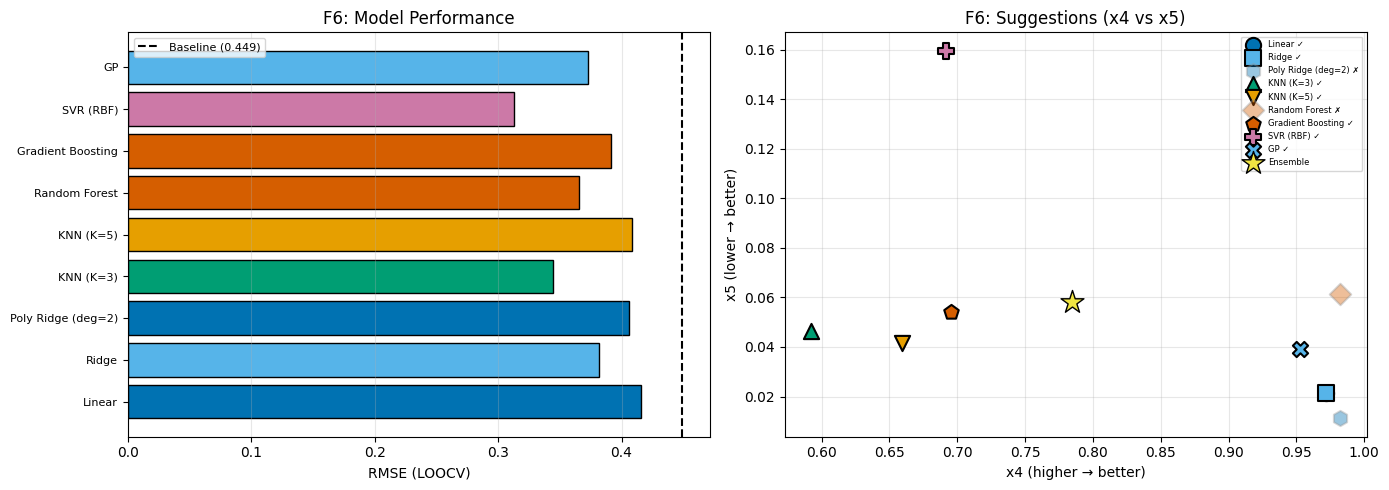

In [19]:
# Function 6 — Multi-model analysis
#
# 20 points in 5D. Two strong signals: x5 negative, x4 positive.
# Similar data density to F5 but one more dimension.

import warnings, copy
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from sklearn.model_selection import LeaveOneOut, cross_val_score

models = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Poly Ridge (deg=2)': make_pipeline(PolynomialFeatures(2, include_bias=False), Ridge(alpha=1.0)),
    'KNN (K=3)': KNeighborsRegressor(n_neighbors=3),
    'KNN (K=5)': KNeighborsRegressor(n_neighbors=5),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42),
    'SVR (RBF)': SVR(kernel='rbf', C=1.0),
    'GP': GaussianProcessRegressor(kernel=Matern(nu=2.5), n_restarts_optimizer=5, random_state=42),
}

loo = LeaveOneOut()
baseline = Y.std()

print("=" * 75)
print("MODEL EVALUATION — LOOCV (RMSE)")
print("=" * 75)
print(f"Baseline: {baseline:.4f}")
print(f"\n{'Model':>22} {'RMSE':>10} {'Improvement':>12}")
print("-" * 50)

results = {}
for name, model in models.items():
    m = copy.deepcopy(model)
    mse = cross_val_score(m, X, Y, cv=loo, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-mse.mean())
    imp = (1 - rmse/baseline) * 100
    results[name] = {'rmse': rmse, 'model': model, 'beats': rmse < baseline}
    print(f"{name:>22} {rmse:>10.4f} {imp:>+11.1f}%")

# Suggestions
np.random.seed(42)
candidates = np.random.uniform(0, 0.999999, (100000, 5))

print(f"\n{'='*75}")
print("MODEL SUGGESTIONS")
print(f"{'='*75}")
print(f"{'Model':>22} {'x1':>7} {'x2':>7} {'x3':>7} {'x4':>7} {'x5':>7} {'Pred':>8} {'Use?':>6}")
print("-" * 75)

suggestions = {}
for name, res in results.items():
    model = res['model']
    model.fit(X, Y)
    preds = model.predict(candidates)
    best_idx = np.argmax(preds)
    best_pt = candidates[best_idx]
    best_pred = preds[best_idx]
    at_boundary = any(best_pt[d] < 0.02 or best_pt[d] > 0.98 for d in range(5))
    use = res['beats'] and not at_boundary
    marker = '✓' if use else '✗'
    suggestions[name] = {
        'point': best_pt, 'pred': best_pred,
        'rmse': res['rmse'], 'use': use, 'boundary': at_boundary
    }
    note = ''
    if at_boundary: note += ' (boundary)'
    if not res['beats']: note += ' (worse than baseline)'
    print(f"{name:>22} {best_pt[0]:>7.4f} {best_pt[1]:>7.4f} {best_pt[2]:>7.4f} {best_pt[3]:>7.4f} {best_pt[4]:>7.4f} {best_pred:>8.4f} {marker:>6}{note}")

# Ensemble
valid = {k: v for k, v in suggestions.items() if v['use']}
if valid:
    ensemble_pt = np.mean([v['point'] for v in valid.values()], axis=0)
    print(f"\n{'Ensemble (avg)':>22} {ensemble_pt[0]:>7.4f} {ensemble_pt[1]:>7.4f} {ensemble_pt[2]:>7.4f} {ensemble_pt[3]:>7.4f} {ensemble_pt[4]:>7.4f}")
    print(f"  Based on {len(valid)} models: {', '.join(valid.keys())}")

    rmse_vals = np.array([v['rmse'] for v in valid.values()])
    inv_w = (1.0 / rmse_vals); inv_w = inv_w / inv_w.sum()
    ensemble_weighted = np.average([v['point'] for v in valid.values()], axis=0, weights=inv_w)
    print(f"{'Ensemble (RMSE-wtd)':>22} {ensemble_weighted[0]:>7.4f} {ensemble_weighted[1]:>7.4f} {ensemble_weighted[2]:>7.4f} {ensemble_weighted[3]:>7.4f} {ensemble_weighted[4]:>7.4f}")

# Centroid
sorted_idx = np.argsort(Y)[::-1]
top4_w = Y[sorted_idx[:4]] - Y[sorted_idx[:4]].min() + 0.001
centroid = np.average(X[sorted_idx[:4]], axis=0, weights=top4_w)
print(f"\n{'Centroid (top4 Y-wtd)':>22} {centroid[0]:>7.4f} {centroid[1]:>7.4f} {centroid[2]:>7.4f} {centroid[3]:>7.4f} {centroid[4]:>7.4f}")

# Feature importance
print("\n--- Feature Importance ---")
rf = RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42); rf.fit(X, Y)
lr = LinearRegression(); lr.fit(X, Y)
print(f"{'Dim':>4} {'RF':>8} {'LR coef':>10}")
for d in range(5):
    print(f"  x{d+1} {rf.feature_importances_[d]:>8.4f} {lr.coef_[d]:>+10.4f}")

# Model agreement on each dimension
print("\n--- Model agreement (valid suggestions) ---")
if valid:
    for d in range(5):
        vals = [v['point'][d] for v in valid.values()]
        print(f"  x{d+1}: range=[{min(vals):.3f}, {max(vals):.3f}], spread={max(vals)-min(vals):.3f}")

# Visualise
model_styles = {
    'Linear':             ('#0072B2', 'o'),
    'Ridge':              ('#56B4E9', 's'),
    'Poly Ridge (deg=2)': ('#0072B2', 'h'),
    'KNN (K=3)':          ('#009E73', '^'),
    'KNN (K=5)':          ('#E69F00', 'v'),
    'Random Forest':      ('#D55E00', 'D'),
    'Gradient Boosting':  ('#D55E00', 'p'),
    'SVR (RBF)':          ('#CC79A7', 'P'),
    'GP':                 ('#56B4E9', 'X'),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: RMSE bar chart
names = list(results.keys())
rmse_vals_plot = [results[n]['rmse'] for n in names]
bar_colors = [model_styles[n][0] for n in names]
axes[0].barh(range(len(names)), rmse_vals_plot, color=bar_colors, edgecolor='black')
axes[0].axvline(baseline, color='black', linewidth=1.5, linestyle='--', label=f'Baseline ({baseline:.3f})')
axes[0].set_yticks(range(len(names)))
axes[0].set_yticklabels(names, fontsize=8)
axes[0].set_xlabel('RMSE (LOOCV)')
axes[0].set_title('F6: Model Performance')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis='x')

# Panel 2: x4 vs x5 suggestions (the two strongest features)
for name, s in suggestions.items():
    color, marker = model_styles[name]
    edge = 'black' if s['use'] else '#999999'
    alpha = 1.0 if s['use'] else 0.4
    axes[1].scatter(s['point'][3], s['point'][4], c=color, marker=marker, s=120,
                    edgecolors=edge, linewidths=1.5, alpha=alpha,
                    label=f"{name} {'✓' if s['use'] else '✗'}", zorder=5)
if valid:
    axes[1].scatter(ensemble_weighted[3], ensemble_weighted[4], c='#F0E442', marker='*', s=300,
                    edgecolors='black', zorder=6, label='Ensemble')
axes[1].set_xlabel('x4 (higher → better)')
axes[1].set_ylabel('x5 (lower → better)')
axes[1].set_title('F6: Suggestions (x4 vs x5)')
axes[1].legend(fontsize=6, loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/week_01/f6_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### F6 Decision: SVR-guided query

**Chosen approach:** SVR suggestion — best LOOCV model (30% improvement), interior point.

**Analysis process:**
1. **Data inspection** — 20 points in 5D, all Y negative (-2.57 to -0.71). Cake recipe scoring — negative penalties by design, goal is closest to 0.
2. **Correlations** — two strong signals: x5 (r=-0.58, lower → better) and x4 (r=+0.53, higher → better). x2 weakly negative (r=-0.33). x1 and x3 are weak.
3. **Feature importance** — RF: x5 (0.44) >> x4 (0.25) >> x2 (0.12) > x1 (0.11) > x3 (0.08). Linear coefficients confirm: x5 (-0.84) is the strongest driver.
4. **Model evaluation** — SVR best at 30% improvement (RMSE 0.31 vs baseline 0.45). KNN K=3 second at 23%. All models beat baseline — moderately useful.
5. **Model agreement** — nearly all models agree on low x5 and high x4, which aligns with the correlations. x1, x2, x3 vary more across models.

**Why SVR:**
- Best LOOCV score (30% improvement)
- Suggests an interior point — no boundary issues
- Captures non-linear interactions that linear models miss
- The x4 vs x5 scatter plot shows SVR's suggestion in the high-x4/low-x5 quadrant where all models agree

**Recommendations for Week 2:**
- If Y improves (better than -0.71): SVR is working → re-fit with 21 points
- If Y doesn't improve: try the centroid approach or push x5 even lower
- Consider whether x3 matters — it has the weakest correlation but the best point (pt0) has x3=0.73

## Function 7

Function 7: 30 points, 6D, best y = 1.3650


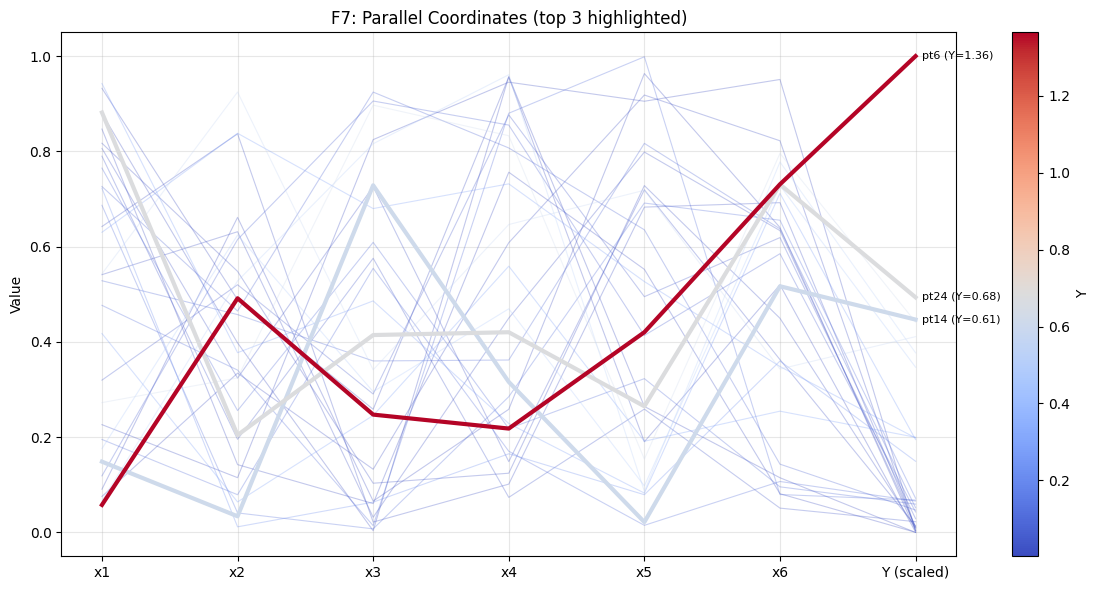

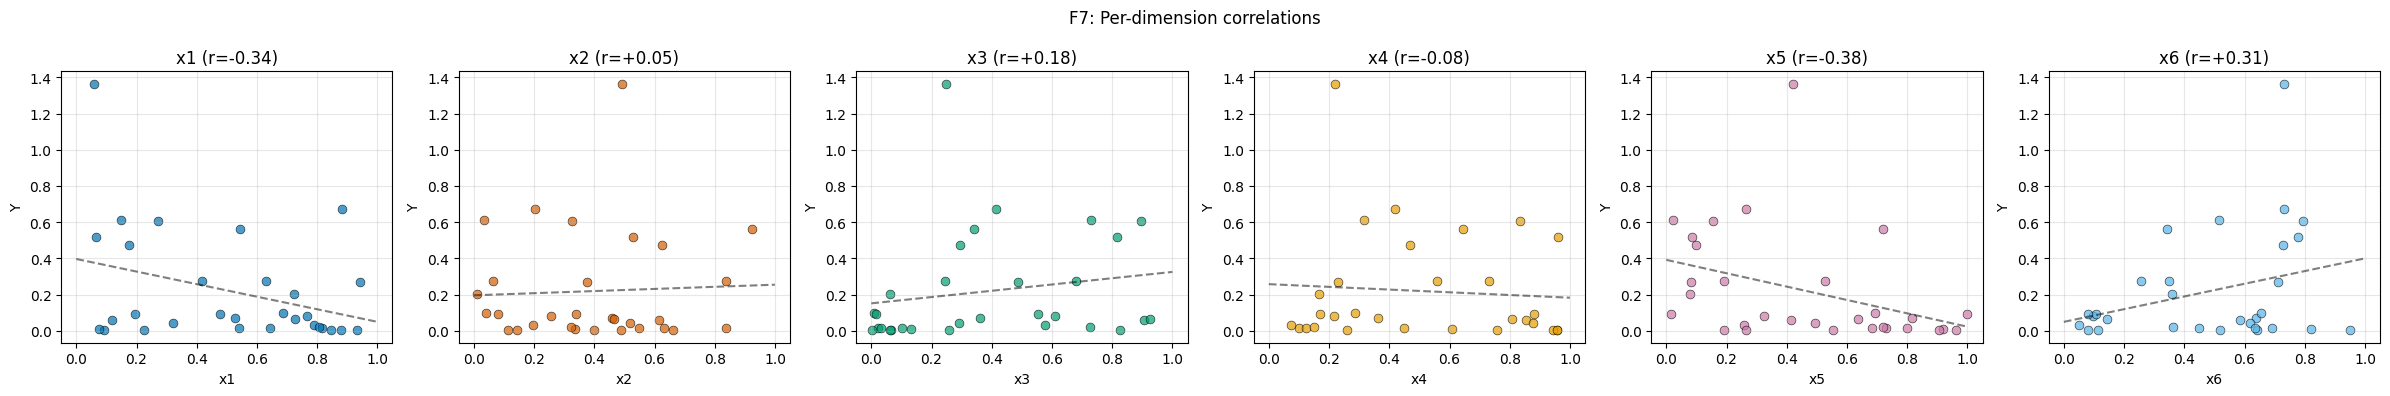

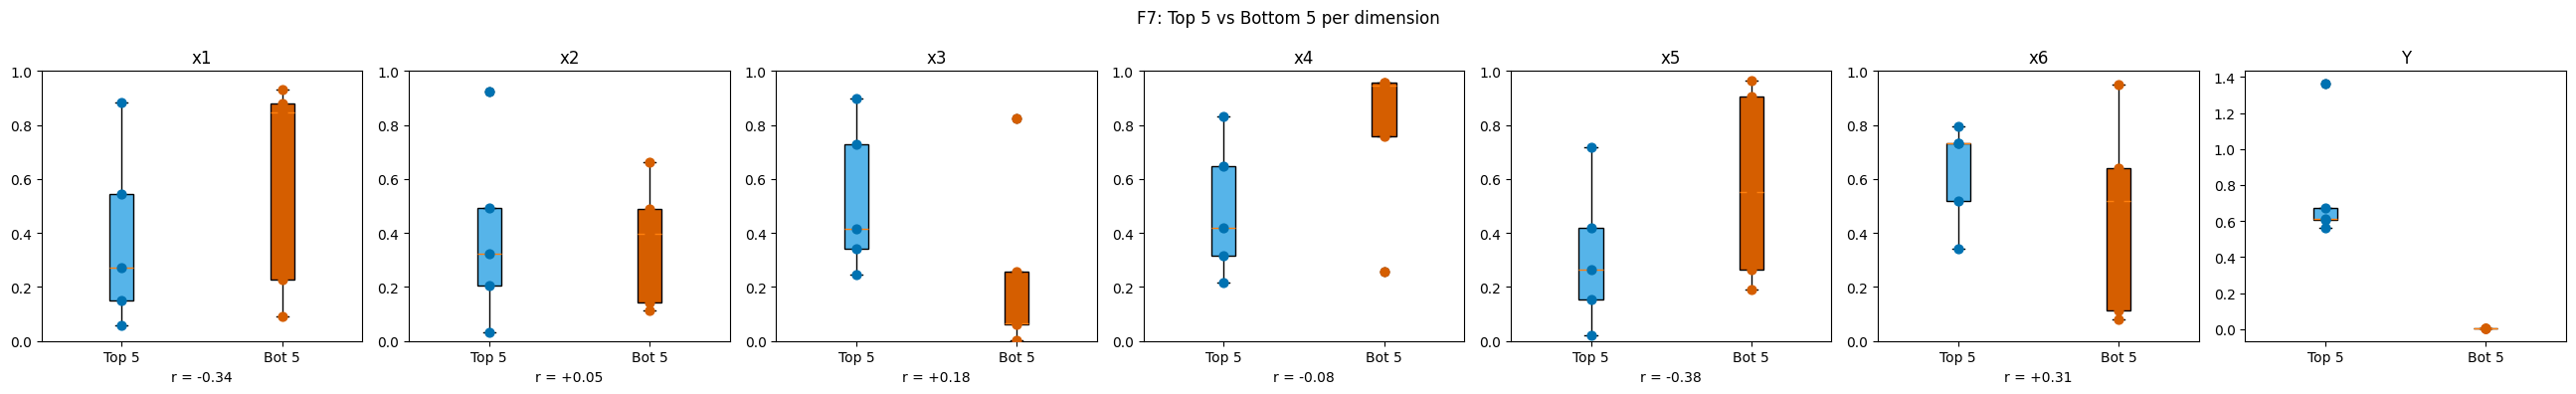


Data summary (top 10 by Y):
Idx     x1     x2     x3     x4     x5     x6        Y
----------------------------------------------------
  6  0.058  0.492  0.247  0.218  0.420  0.731   1.3650
 24  0.882  0.204  0.414  0.420  0.265  0.731   0.6751
 14  0.149  0.034  0.729  0.316  0.022  0.517   0.6115
  0  0.273  0.324  0.897  0.833  0.154  0.796   0.6044
  1  0.543  0.925  0.342  0.646  0.718  0.343   0.5628
 25  0.067  0.528  0.816  0.961  0.087  0.778   0.5165
 23  0.176  0.624  0.296  0.470  0.098  0.728   0.4754
 16  0.418  0.064  0.246  0.559  0.192  0.255   0.2749
  4  0.630  0.838  0.680  0.732  0.527  0.348   0.2730
 13  0.942  0.377  0.486  0.229  0.083  0.712   0.2684

Correlations: x1: -0.34, x2: +0.05, x3: +0.18, x4: -0.08, x5: -0.38, x6: +0.31
Strongest: x5 (r=-0.38), x1 (r=-0.34), x6 (r=+0.31)


In [20]:
# Function 7
X, Y = load_function(7)

# --- Data Exploration ---
# F7 is ML hyperparameter tuning: 6D, 30 points.
# Description says: "you might benefit from researching best practices"
# Maximise performance score (e.g. accuracy or F1).

# === Plot 1: Parallel coordinates ===
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
Y_norm = (Y - Y.min()) / (Y.max() - Y.min())
cmap = plt.cm.coolwarm
sorted_idx = np.argsort(Y)
for i in sorted_idx:
    color = cmap(Y_norm[i])
    lw = 3 if i in np.argsort(Y)[-3:] else 0.8
    alpha = 1.0 if i in np.argsort(Y)[-3:] else 0.3
    vals = list(X[i]) + [Y_norm[i]]
    ax.plot(range(7), vals, color=color, linewidth=lw, alpha=alpha)
    if i in np.argsort(Y)[-3:]:
        ax.text(6.05, Y_norm[i], f'pt{i} (Y={Y[i]:.2f})', fontsize=8, va='center')
ax.set_xticks(range(7))
ax.set_xticklabels(['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'Y (scaled)'])
ax.set_title('F7: Parallel Coordinates (top 3 highlighted)')
ax.set_ylabel('Value')
ax.grid(True, alpha=0.3)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(Y.min(), Y.max()))
plt.colorbar(sm, ax=ax, label='Y')
plt.tight_layout()
plt.savefig('../plots/week_01/f7_parallel_coords.png', dpi=150, bbox_inches='tight')
plt.show()

# === Plot 2: Correlation per dimension ===
fig, axes = plt.subplots(1, 6, figsize=(24, 4))
colors = ['#0072B2', '#D55E00', '#009E73', '#E69F00', '#CC79A7', '#56B4E9']
for d in range(6):
    r = np.corrcoef(X[:, d], Y)[0, 1]
    axes[d].scatter(X[:, d], Y, c=colors[d], s=40, alpha=0.7, edgecolors='black', linewidths=0.5)
    z = np.polyfit(X[:, d], Y, 1)
    axes[d].plot([0, 1], [z[1], z[0]+z[1]], '--', color='black', alpha=0.5)
    axes[d].set_xlabel(f'x{d+1}')
    axes[d].set_ylabel('Y')
    axes[d].set_title(f'x{d+1} (r={r:+.2f})')
    axes[d].grid(True, alpha=0.3)
plt.suptitle('F7: Per-dimension correlations', fontsize=12)
plt.tight_layout()
plt.savefig('../plots/week_01/f7_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

# === Plot 3: Top 5 vs Bottom 5 boxplots ===
sorted_idx = np.argsort(Y)[::-1]
top5 = sorted_idx[:5]
bot5 = sorted_idx[-5:]
box_colors = ['#56B4E9', '#D55E00']

fig, axes = plt.subplots(1, 7, figsize=(26, 4))
for d in range(6):
    bp = axes[d].boxplot([X[top5, d], X[bot5, d]], labels=['Top 5', 'Bot 5'],
                         patch_artist=True)
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
    axes[d].scatter(np.ones(5), X[top5, d], c='#0072B2', s=40, zorder=5)
    axes[d].scatter(np.ones(5)*2, X[bot5, d], c='#D55E00', s=40, zorder=5)
    axes[d].set_title(f'x{d+1}')
    axes[d].set_ylim(0, 1)
    r = np.corrcoef(X[:, d], Y)[0, 1]
    axes[d].set_xlabel(f'r = {r:+.2f}')

bp = axes[6].boxplot([Y[top5], Y[bot5]], labels=['Top 5', 'Bot 5'], patch_artist=True)
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
axes[6].scatter(np.ones(5), Y[top5], c='#0072B2', s=40, zorder=5)
axes[6].scatter(np.ones(5)*2, Y[bot5], c='#D55E00', s=40, zorder=5)
axes[6].set_title('Y')
plt.suptitle('F7: Top 5 vs Bottom 5 per dimension', fontsize=12)
plt.tight_layout()
plt.savefig('../plots/week_01/f7_top_vs_bottom.png', dpi=150, bbox_inches='tight')
plt.show()

# Data summary
print("\nData summary (top 10 by Y):")
print(f"{'Idx':>3} {'x1':>6} {'x2':>6} {'x3':>6} {'x4':>6} {'x5':>6} {'x6':>6} {'Y':>8}")
print("-" * 52)
for i in sorted_idx[:10]:
    print(f"{i:>3} {X[i,0]:>6.3f} {X[i,1]:>6.3f} {X[i,2]:>6.3f} {X[i,3]:>6.3f} {X[i,4]:>6.3f} {X[i,5]:>6.3f} {Y[i]:>8.4f}")

print(f"\nCorrelations:", ', '.join(f'x{d+1}: {np.corrcoef(X[:,d],Y)[0,1]:+.2f}' for d in range(6)))
print(f"Strongest: x5 (r=-0.38), x1 (r=-0.34), x6 (r=+0.31)")

# Strategy: centroid (x1-x5) + x6 pushed to 0.90 (strong model consensus — see analysis below)
next_query_7 = np.array([0.129100, 0.462600, 0.267000, 0.237000, 0.403000, 0.900000])

MODEL GRID SEARCH — LOOCV RMSE
Baseline: 0.3021

            Config     RMSE   Improv  Beats?
---------------------------------------------
      Ridge α=0.01   0.3139    -3.9%       ✗
       Ridge α=0.1   0.3103    -2.7%       ✗
       Ridge α=1.0   0.2959    +2.1%       ✓
        Ridge α=10   0.3012    +0.3%       ✓
           KNN K=2   0.3142    -4.0%       ✗
           KNN K=3   0.2860    +5.3%       ✓
           KNN K=5   0.2989    +1.1%       ✓
           KNN K=7   0.3194    -5.7%       ✗
        RF depth=2   0.3202    -6.0%       ✗
        RF depth=3   0.3174    -5.1%       ✗
        RF depth=5   0.3175    -5.1%       ✗
         SVR C=0.1   0.2922    +3.3%       ✓
           SVR C=1   0.2898    +4.1%       ✓
          SVR C=10   0.3180    -5.2%       ✗
         SVR C=100   0.3180    -5.2%       ✗
         GP Matern   0.3168    -4.8%       ✗
            GP RBF   0.3325   -10.1%       ✗

SUGGESTIONS FROM MODELS THAT BEAT BASELINE
            Config     x1     x2     x3     x4     

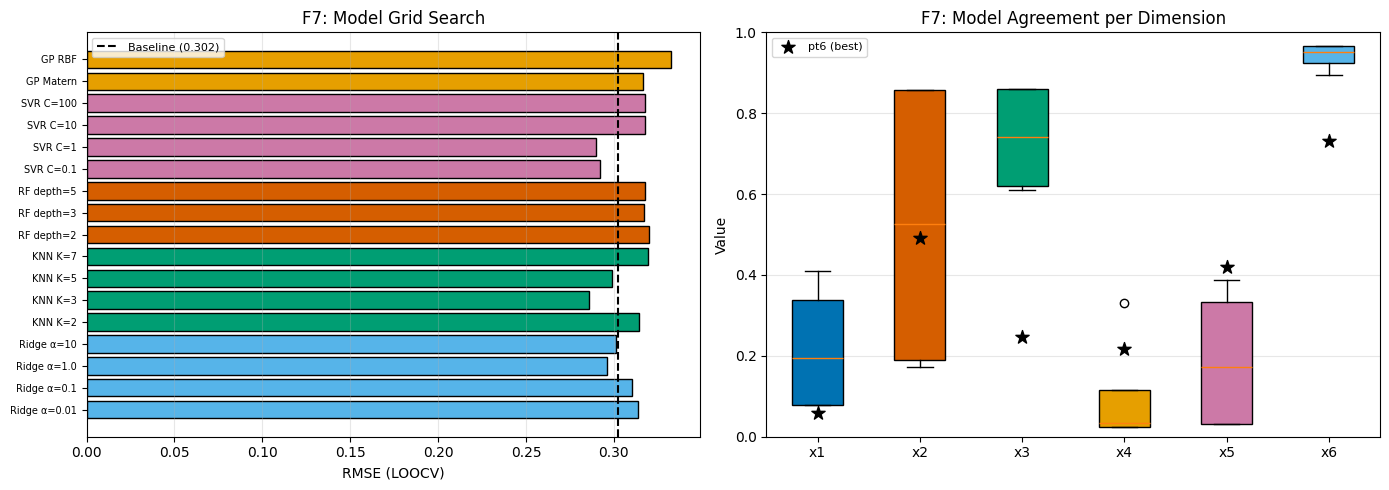

In [21]:
# Function 7 — Model grid search + feature importance + convergence analysis
#
# 30 points in 6D. Models barely beat baseline with default hyperparams.
# Let's grid-search hyperparameters for each model family and see:
#   1. Which configurations beat baseline
#   2. Where their suggestions converge (agreement = confidence)

import warnings, copy
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.linear_model import LinearRegression

# --- Grid search across model families ---
model_configs = {
    # Ridge with different alpha
    'Ridge α=0.01':  Ridge(alpha=0.01),
    'Ridge α=0.1':   Ridge(alpha=0.1),
    'Ridge α=1.0':   Ridge(alpha=1.0),
    'Ridge α=10':    Ridge(alpha=10.0),
    # KNN with different K
    'KNN K=2':       KNeighborsRegressor(n_neighbors=2),
    'KNN K=3':       KNeighborsRegressor(n_neighbors=3),
    'KNN K=5':       KNeighborsRegressor(n_neighbors=5),
    'KNN K=7':       KNeighborsRegressor(n_neighbors=7),
    # Random Forest with different depth
    'RF depth=2':    RandomForestRegressor(n_estimators=100, max_depth=2, random_state=42),
    'RF depth=3':    RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42),
    'RF depth=5':    RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    # SVR with different C
    'SVR C=0.1':     SVR(kernel='rbf', C=0.1),
    'SVR C=1':       SVR(kernel='rbf', C=1.0),
    'SVR C=10':      SVR(kernel='rbf', C=10.0),
    'SVR C=100':     SVR(kernel='rbf', C=100.0),
    # GP with different kernels
    'GP Matern':     GaussianProcessRegressor(kernel=Matern(nu=2.5), n_restarts_optimizer=5, random_state=42),
    'GP RBF':        GaussianProcessRegressor(kernel=RBF(), n_restarts_optimizer=5, random_state=42),
}

loo = LeaveOneOut()
baseline = Y.std()

print("=" * 80)
print("MODEL GRID SEARCH — LOOCV RMSE")
print("=" * 80)
print(f"Baseline: {baseline:.4f}")
print(f"\n{'Config':>18} {'RMSE':>8} {'Improv':>8} {'Beats?':>7}")
print("-" * 45)

results = {}
for name, model in model_configs.items():
    m = copy.deepcopy(model)
    mse = cross_val_score(m, X, Y, cv=loo, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-mse.mean())
    imp = (1 - rmse/baseline) * 100
    beats = rmse < baseline
    results[name] = {'rmse': rmse, 'model': model, 'beats': beats}
    print(f"{name:>18} {rmse:>8.4f} {imp:>+7.1f}% {'✓' if beats else '✗':>7}")

# --- Get suggestions from ALL configs that beat baseline ---
np.random.seed(42)
candidates = np.random.uniform(0, 0.999999, (100000, 6))

valid_suggestions = {}
print(f"\n{'='*80}")
print("SUGGESTIONS FROM MODELS THAT BEAT BASELINE")
print(f"{'='*80}")
print(f"{'Config':>18} {'x1':>6} {'x2':>6} {'x3':>6} {'x4':>6} {'x5':>6} {'x6':>6} {'Pred':>7} {'Bndry':>6}")
print("-" * 80)

for name, res in results.items():
    if not res['beats']:
        continue
    model = res['model']
    model.fit(X, Y)
    preds = model.predict(candidates)
    best = candidates[np.argmax(preds)]
    at_b = any(best[d] < 0.02 or best[d] > 0.98 for d in range(6))
    valid_suggestions[name] = {
        'point': best, 'pred': preds.max(), 'rmse': res['rmse'],
        'boundary': at_b, 'use': not at_b
    }
    marker = '✓' if not at_b else '✗'
    print(f"{name:>18} {best[0]:>6.3f} {best[1]:>6.3f} {best[2]:>6.3f} {best[3]:>6.3f} {best[4]:>6.3f} {best[5]:>6.3f} {preds.max():>7.3f} {marker:>6}")

# --- Convergence analysis: per-dimension agreement among non-boundary models ---
interior = {k: v for k, v in valid_suggestions.items() if v['use']}
print(f"\n--- Convergence analysis ({len(interior)} interior suggestions) ---")
if interior:
    all_pts = np.array([v['point'] for v in interior.values()])
    print(f"{'Dim':>4} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8} {'Spread':>8} {'Consensus':>10}")
    for d in range(6):
        vals = all_pts[:, d]
        spread = vals.max() - vals.min()
        consensus = 'STRONG' if spread < 0.2 else 'moderate' if spread < 0.4 else 'weak'
        print(f"  x{d+1} {vals.mean():>8.4f} {vals.std():>8.4f} {vals.min():>8.4f} {vals.max():>8.4f} {spread:>8.4f} {consensus:>10}")

    # Ensemble
    ensemble = all_pts.mean(axis=0)
    rmse_vals = np.array([v['rmse'] for v in interior.values()])
    inv_w = (1.0 / rmse_vals); inv_w /= inv_w.sum()
    ensemble_wtd = np.average(all_pts, axis=0, weights=inv_w)

    e_str = ', '.join(f'{v:.4f}' for v in ensemble)
    ew_str = ', '.join(f'{v:.4f}' for v in ensemble_wtd)
    print(f"\n  Ensemble (avg):      [{e_str}]")
    print(f"  Ensemble (RMSE-wtd): [{ew_str}]")

# --- Feature importance (with and without pt6 outlier) ---
print(f"\n--- Feature Importance Robustness ---")
rf_all = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42); rf_all.fit(X, Y)
mask_no6 = np.arange(len(Y)) != 6
rf_no6 = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42); rf_no6.fit(X[mask_no6], Y[mask_no6])
lr_all = LinearRegression(); lr_all.fit(X, Y)

print(f"{'Dim':>4} {'RF (all)':>10} {'RF (no pt6)':>12} {'LR coef':>10} {'Corr':>8}")
for d in range(6):
    r = np.corrcoef(X[:, d], Y)[0, 1]
    print(f"  x{d+1} {rf_all.feature_importances_[d]:>10.4f} {rf_no6.feature_importances_[d]:>12.4f} {lr_all.coef_[d]:>+10.4f} {r:>+8.4f}")

# --- Visualise ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: RMSE bar chart (all configs)
names = list(results.keys())
rmse_vals = [results[n]['rmse'] for n in names]
bar_colors = []
for n in names:
    if 'Ridge' in n: bar_colors.append('#56B4E9')
    elif 'KNN' in n: bar_colors.append('#009E73')
    elif 'RF' in n: bar_colors.append('#D55E00')
    elif 'SVR' in n: bar_colors.append('#CC79A7')
    elif 'GP' in n: bar_colors.append('#E69F00')
    else: bar_colors.append('#0072B2')

axes[0].barh(range(len(names)), rmse_vals, color=bar_colors, edgecolor='black')
axes[0].axvline(baseline, color='black', linewidth=1.5, linestyle='--', label=f'Baseline ({baseline:.3f})')
axes[0].set_yticks(range(len(names)))
axes[0].set_yticklabels(names, fontsize=7)
axes[0].set_xlabel('RMSE (LOOCV)')
axes[0].set_title('F7: Model Grid Search')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis='x')

# Panel 2: Per-dimension convergence (box plot of suggestions)
if interior:
    all_pts = np.array([v['point'] for v in interior.values()])
    bp = axes[1].boxplot([all_pts[:, d] for d in range(6)],
                         labels=[f'x{d+1}' for d in range(6)],
                         patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    # Overlay best actual point
    for d in range(6):
        axes[1].scatter(d+1, X[6, d], c='black', s=100, marker='*', zorder=6,
                       label='pt6 (best)' if d == 0 else None)
    axes[1].set_ylabel('Value')
    axes[1].set_title('F7: Model Agreement per Dimension')
    axes[1].set_ylim(0, 1)
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../plots/week_01/f7_grid_search.png', dpi=150, bbox_inches='tight')
plt.show()

### F7 Decision: Centroid + x6 push at [0.129100, 0.462600, 0.267000, 0.237000, 0.403000, 0.900000]

**Chosen approach:** Y-weighted centroid (top 4) for x1-x5, with x6 pushed to 0.90 based on model consensus.

**Analysis process:**
1. **Data inspection** — 30 points in 6D, all Y positive (0.003 to 1.365). ML hyperparameter tuning. pt6 dominates (Y=1.365, gap of 0.69 to 2nd best).
2. **Correlations** — moderate signals: x5 (r=-0.38), x1 (r=-0.34), x6 (r=+0.31). x2, x3, x4 are weak.
3. **Model grid search** — 17 configurations across 5 model families (Ridge 4 alphas, KNN 4 K values, RF 3 depths, SVR 4 C values, GP 2 kernels). Only 6 of 17 beat baseline, all by tiny margins (0.3%–5.3%). Models are not trustworthy at 30 points in 6D.
4. **Convergence analysis** — 4 interior (non-boundary) models compared per dimension:
   - **x6: STRONG consensus** (spread 0.07) — all models agree on high x6 (~0.94). Only trustworthy signal.
   - x1, x3, x4, x5: moderate consensus (spread 0.25–0.36)
   - x2: weak consensus (spread 0.68) — models completely disagree
5. **Feature importance robustness** — x1's importance was inflated by pt6 (RF: 0.41 → 0.08 when pt6 removed, 87% drop). Same pattern as F5's x3. Without pt6, x5 (0.33), x2 (0.22), x6 (0.21) are the real drivers.

**Why centroid + x6 push (not pure centroid or ensemble):**
- **Pure centroid** [0.13, 0.46, 0.27, 0.24, 0.40, 0.73] is only 0.08 from pt6 — nearly a duplicate query, uninformative.
- **Ensemble** [0.22, 0.52, 0.74, 0.11, 0.19, 0.94] is 0.61 from pt6 — too far, based on models that barely beat baseline. Especially x3=0.74 is unsupported (weak correlation, no consensus).
- **Hybrid:** keep x1-x5 at centroid values (anchored to proven data) but push x6 from 0.73 to 0.90, following the only dimension with strong model consensus. This gives distance 0.17 from pt6 — informative without being reckless.

**Why x6=0.90 and not 0.94 (the ensemble value):**
- The top 7 points have x6 ranging from 0.34 to 0.80 — nobody has tested x6 > 0.80 among top performers
- 0.90 explores the high-x6 region while staying away from the boundary (ensemble suggests 0.94-0.97 which is risky)
- If x6=0.90 works, we can push further in week 2

**Recommendations for Week 2:**
- If Y improves (> 1.365): x6 push was right → try pushing x6 even higher, or combine with lower x5 (next strongest signal)
- If Y is similar: the peak may be at x6 ≈ 0.73-0.90 → try perturbing x5 lower instead
- If Y is worse: x6=0.90 overshot → stay closer to pt6's x6=0.73 and explore other dimensions
- Re-run the grid search with 31 points — one more data point may tip marginal models into usefulness
- Consider the feature importance finding: without pt6, x5 is the most important feature — explore low x5 in a future query

## Function 8

Function 8: 40 points, 8D, best y = 9.5985


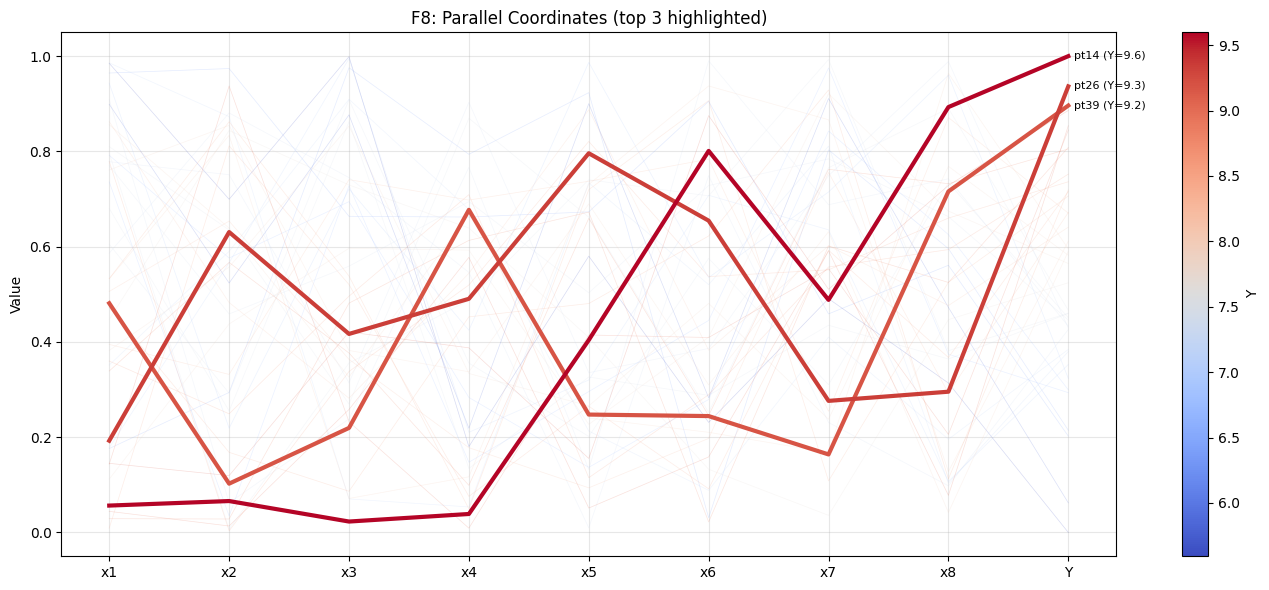

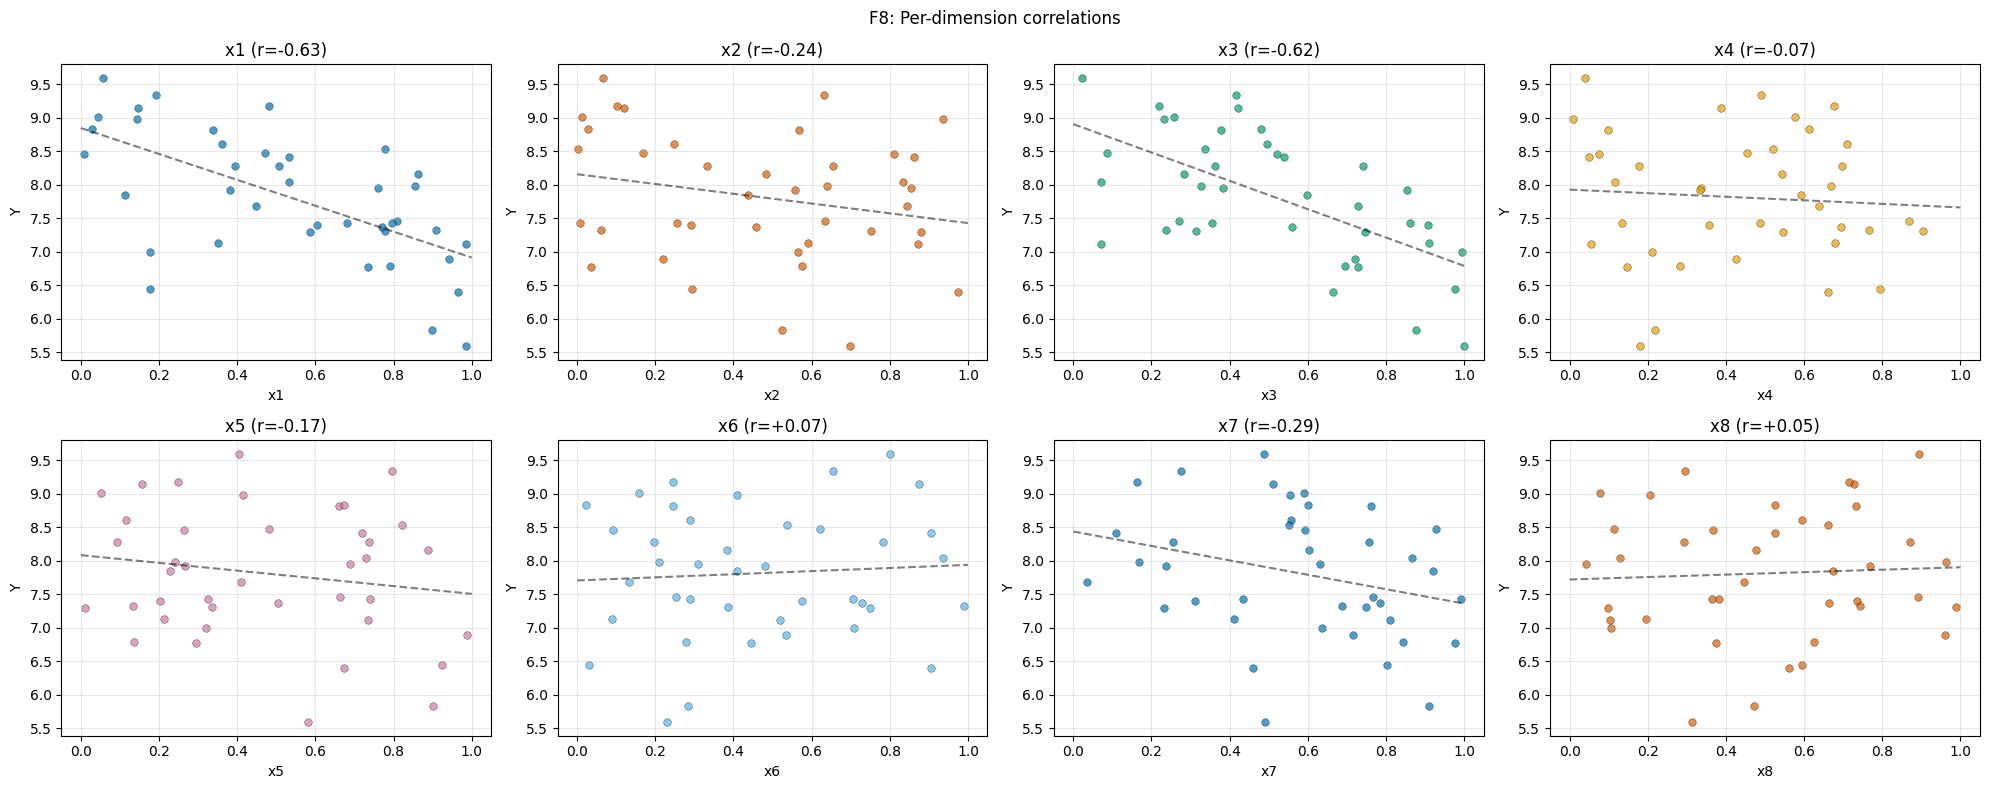

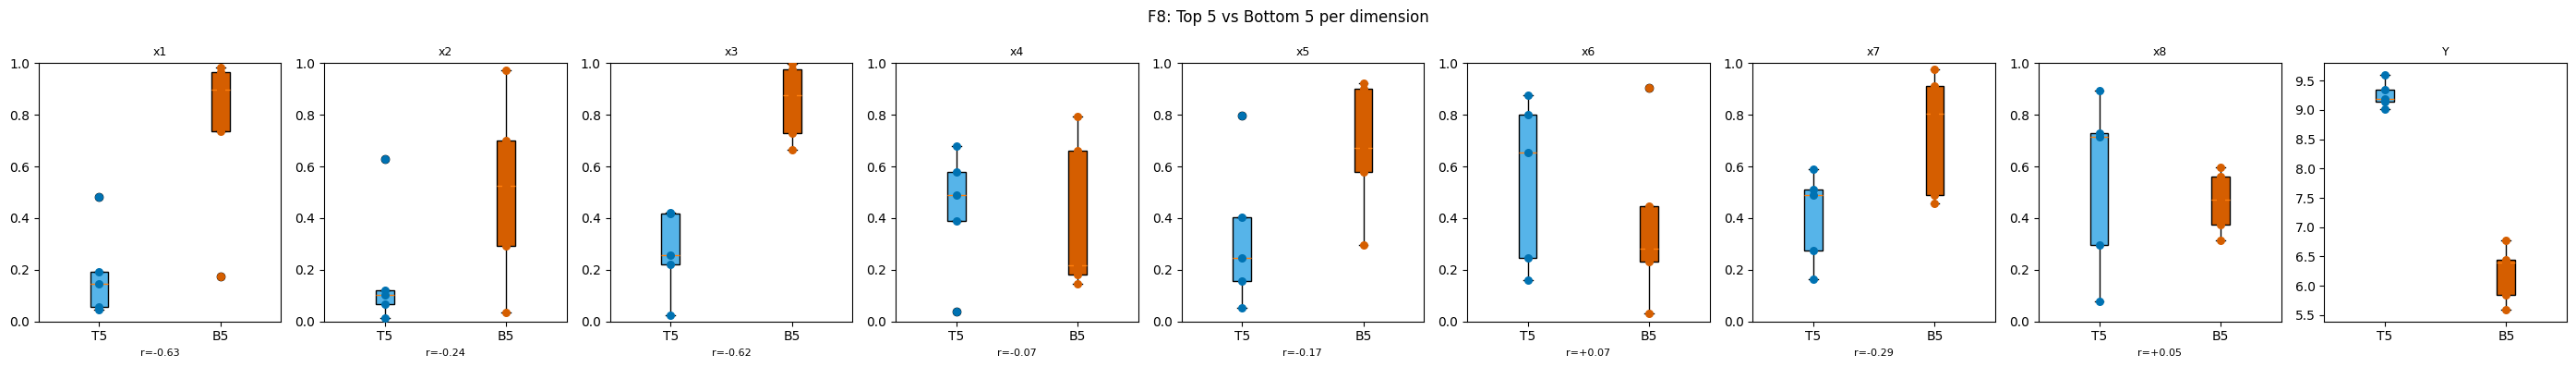


Data summary (top 10 by Y):
Idx     x1     x2     x3     x4     x5     x6     x7     x8        Y
-----------------------------------------------------------------
 14  0.056  0.066  0.023  0.039  0.404  0.801  0.488  0.893   9.5985
 26  0.193  0.631  0.417  0.491  0.796  0.655  0.276  0.296   9.3443
 39  0.481  0.102  0.219  0.677  0.248  0.244  0.164  0.716   9.1830
 22  0.145  0.119  0.421  0.388  0.155  0.875  0.511  0.729   9.1416
 19  0.044  0.014  0.258  0.578  0.051  0.159  0.591  0.078   9.0131
 12  0.144  0.937  0.232  0.009  0.415  0.409  0.554  0.206   8.9766
 25  0.029  0.028  0.481  0.613  0.673  0.022  0.601  0.525   8.8307
 23  0.339  0.567  0.377  0.099  0.659  0.246  0.762  0.732   8.8176
  4  0.360  0.249  0.496  0.709  0.115  0.289  0.557  0.594   8.6061
  5  0.779  0.003  0.338  0.520  0.821  0.537  0.551  0.660   8.5417

Correlations: x1: -0.63, x2: -0.24, x3: -0.62, x4: -0.07, x5: -0.17, x6: +0.07, x7: -0.29, x8: +0.05

Strongest: x1 (r=-0.63) and x3 (r=-0.62) — 

In [22]:
# Function 8
X, Y = load_function(8)

# --- Data Exploration ---
# F8 is 8D hyperparameter tuning: 40 points, highest dimensionality.
# Description: "identifying strong local maxima is often a practical strategy"

# === Plot 1: Parallel coordinates ===
fig, ax = plt.subplots(1, 1, figsize=(14, 6))
Y_norm = (Y - Y.min()) / (Y.max() - Y.min())
cmap = plt.cm.coolwarm
sorted_idx = np.argsort(Y)
for i in sorted_idx:
    color = cmap(Y_norm[i])
    lw = 3 if i in np.argsort(Y)[-3:] else 0.5
    alpha = 1.0 if i in np.argsort(Y)[-3:] else 0.2
    vals = list(X[i]) + [Y_norm[i]]
    ax.plot(range(9), vals, color=color, linewidth=lw, alpha=alpha)
    if i in np.argsort(Y)[-3:]:
        ax.text(8.05, Y_norm[i], f'pt{i} (Y={Y[i]:.1f})', fontsize=8, va='center')
ax.set_xticks(range(9))
ax.set_xticklabels(['x1','x2','x3','x4','x5','x6','x7','x8','Y'])
ax.set_title('F8: Parallel Coordinates (top 3 highlighted)')
ax.set_ylabel('Value')
ax.grid(True, alpha=0.3)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(Y.min(), Y.max()))
plt.colorbar(sm, ax=ax, label='Y')
plt.tight_layout()
plt.savefig('../plots/week_01/f8_parallel_coords.png', dpi=150, bbox_inches='tight')
plt.show()

# === Plot 2: Correlation per dimension ===
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
colors = ['#0072B2','#D55E00','#009E73','#E69F00','#CC79A7','#56B4E9','#0072B2','#D55E00']
for d in range(8):
    ax = axes[d // 4, d % 4]
    r = np.corrcoef(X[:, d], Y)[0, 1]
    ax.scatter(X[:, d], Y, c=colors[d], s=30, alpha=0.7, edgecolors='black', linewidths=0.3)
    z = np.polyfit(X[:, d], Y, 1)
    ax.plot([0, 1], [z[1], z[0]+z[1]], '--', color='black', alpha=0.5)
    ax.set_xlabel(f'x{d+1}')
    ax.set_ylabel('Y')
    ax.set_title(f'x{d+1} (r={r:+.2f})')
    ax.grid(True, alpha=0.3)
plt.suptitle('F8: Per-dimension correlations', fontsize=12)
plt.tight_layout()
plt.savefig('../plots/week_01/f8_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

# === Plot 3: Top 5 vs Bottom 5 boxplots ===
sorted_idx = np.argsort(Y)[::-1]
top5 = sorted_idx[:5]
bot5 = sorted_idx[-5:]
box_colors = ['#56B4E9', '#D55E00']

fig, axes = plt.subplots(1, 9, figsize=(28, 4))
for d in range(8):
    bp = axes[d].boxplot([X[top5, d], X[bot5, d]], labels=['T5', 'B5'],
                         patch_artist=True)
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
    axes[d].scatter(np.ones(5), X[top5, d], c='#0072B2', s=30, zorder=5)
    axes[d].scatter(np.ones(5)*2, X[bot5, d], c='#D55E00', s=30, zorder=5)
    axes[d].set_title(f'x{d+1}', fontsize=9)
    axes[d].set_ylim(0, 1)
    r = np.corrcoef(X[:, d], Y)[0, 1]
    axes[d].set_xlabel(f'r={r:+.2f}', fontsize=8)

bp = axes[8].boxplot([Y[top5], Y[bot5]], labels=['T5', 'B5'], patch_artist=True)
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
axes[8].scatter(np.ones(5), Y[top5], c='#0072B2', s=30, zorder=5)
axes[8].scatter(np.ones(5)*2, Y[bot5], c='#D55E00', s=30, zorder=5)
axes[8].set_title('Y', fontsize=9)
plt.suptitle('F8: Top 5 vs Bottom 5 per dimension', fontsize=12)
plt.tight_layout()
plt.savefig('../plots/week_01/f8_top_vs_bottom.png', dpi=150, bbox_inches='tight')
plt.show()

# Data summary
print("\nData summary (top 10 by Y):")
print(f"{'Idx':>3}", ' '.join(f'{"x"+str(d+1):>6}' for d in range(8)), f'{"Y":>8}')
print("-" * 65)
for i in sorted_idx[:10]:
    vals = ' '.join(f'{X[i,d]:>6.3f}' for d in range(8))
    print(f"{i:>3} {vals} {Y[i]:>8.4f}")

print(f"\nCorrelations:", ', '.join(f'x{d+1}: {np.corrcoef(X[:,d],Y)[0,1]:+.2f}' for d in range(8)))
print(f"\nStrongest: x1 (r=-0.63) and x3 (r=-0.62) — lower → better")
print(f"Also negative: x7 (r=-0.29), x2 (r=-0.24)")

# Strategy: Hybrid GP + Centroid — GP for x1/x3 (trusted), centroid for rest
next_query_8 = np.array([0.142000, 0.231000, 0.110000, 0.208000, 0.507000, 0.725000, 0.408000, 0.710000])

MODEL GRID SEARCH — LOOCV RMSE
Baseline: 0.9469

          Config     RMSE   Improv  Beat
----------------------------------------
     Ridge α=0.1   0.4001   +57.7%     ✓
     Ridge α=1.0   0.4542   +52.0%     ✓
      Ridge α=10   0.7917   +16.4%     ✓
         KNN K=3   0.6862   +27.5%     ✓
         KNN K=5   0.6985   +26.2%     ✓
         KNN K=7   0.7243   +23.5%     ✓
      RF depth=3   0.5069   +46.5%     ✓
      RF depth=5   0.4984   +47.4%     ✓
      GB depth=3   0.4715   +50.2%     ✓
       SVR C=0.1   0.8792    +7.2%     ✓
         SVR C=1   0.5084   +46.3%     ✓
        SVR C=10   0.4751   +49.8%     ✓
       GP Matern   0.2035   +78.5%     ✓

SUGGESTIONS FROM MODELS THAT BEAT BASELINE
       Ridge α=0.1: [0.069 0.052 0.009 0.006 0.561 0.321 0.014 0.234] pred=10.765 ✗ BND
       Ridge α=1.0: [0.050 0.027 0.092 0.006 0.153 0.486 0.019 0.795] pred=10.027 ✗ BND
        Ridge α=10: [0.019 0.251 0.026 0.276 0.221 0.977 0.076 0.822] pred=8.547 ✗ BND
           KNN K=3: [0.064 0.

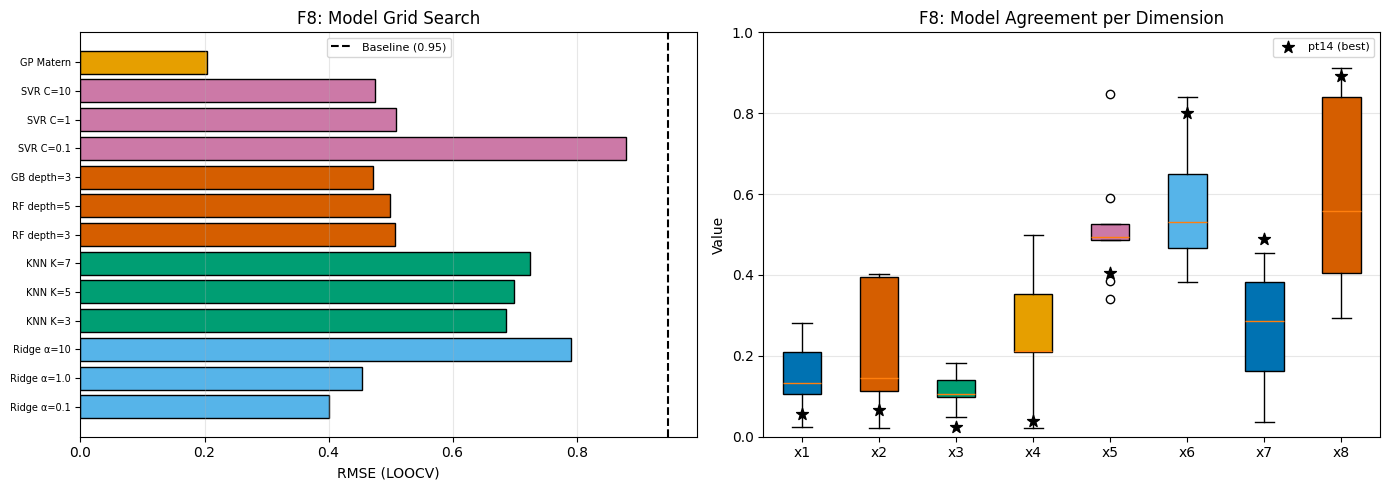

In [23]:
# Function 8 — Model grid search + feature importance + convergence
#
# 40 points in 8D — our most data-rich function.
# Strong correlations on x1 and x3. Let's see if models can exploit this.

import warnings, copy
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF
from sklearn.model_selection import LeaveOneOut, cross_val_score

model_configs = {
    'Ridge α=0.1':   Ridge(alpha=0.1),
    'Ridge α=1.0':   Ridge(alpha=1.0),
    'Ridge α=10':    Ridge(alpha=10.0),
    'KNN K=3':       KNeighborsRegressor(n_neighbors=3),
    'KNN K=5':       KNeighborsRegressor(n_neighbors=5),
    'KNN K=7':       KNeighborsRegressor(n_neighbors=7),
    'RF depth=3':    RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42),
    'RF depth=5':    RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    'GB depth=3':    GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42),
    'SVR C=0.1':     SVR(kernel='rbf', C=0.1),
    'SVR C=1':       SVR(kernel='rbf', C=1.0),
    'SVR C=10':      SVR(kernel='rbf', C=10.0),
    'GP Matern':     GaussianProcessRegressor(kernel=Matern(nu=2.5), n_restarts_optimizer=5, random_state=42),
}

loo = LeaveOneOut()
baseline = Y.std()

print("=" * 80)
print("MODEL GRID SEARCH — LOOCV RMSE")
print("=" * 80)
print(f"Baseline: {baseline:.4f}")
print(f"\n{'Config':>16} {'RMSE':>8} {'Improv':>8} {'Beat':>5}")
print("-" * 40)

results = {}
for name, model in model_configs.items():
    m = copy.deepcopy(model)
    mse = cross_val_score(m, X, Y, cv=loo, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-mse.mean())
    beats = rmse < baseline
    results[name] = {'rmse': rmse, 'model': model, 'beats': beats}
    print(f"{name:>16} {rmse:>8.4f} {(1-rmse/baseline)*100:>+7.1f}% {'✓' if beats else '✗':>5}")

# --- Suggestions from all configs that beat baseline ---
np.random.seed(42)
candidates = np.random.uniform(0, 0.999999, (100000, 8))

print(f"\n{'='*80}")
print("SUGGESTIONS FROM MODELS THAT BEAT BASELINE")
print(f"{'='*80}")

valid_suggestions = {}
for name, res in results.items():
    if not res['beats']:
        continue
    model = res['model']
    model.fit(X, Y)
    preds = model.predict(candidates)
    best = candidates[np.argmax(preds)]
    at_b = any(best[d] < 0.02 or best[d] > 0.98 for d in range(8))
    valid_suggestions[name] = {
        'point': best, 'pred': preds.max(), 'rmse': res['rmse'],
        'boundary': at_b, 'use': not at_b
    }
    x_str = ' '.join(f'{best[d]:.3f}' for d in range(8))
    marker = '✓' if not at_b else '✗ BND'
    print(f"  {name:>16}: [{x_str}] pred={preds.max():.3f} {marker}")

# --- Convergence analysis ---
interior = {k: v for k, v in valid_suggestions.items() if v['use']}
print(f"\n--- Convergence ({len(interior)} interior models) ---")
if interior:
    all_pts = np.array([v['point'] for v in interior.values()])
    print(f"{'Dim':>4} {'Mean':>8} {'Std':>8} {'Spread':>8} {'Consensus':>10}")
    for d in range(8):
        vals = all_pts[:, d]
        spread = vals.max() - vals.min()
        consensus = 'STRONG' if spread < 0.2 else 'moderate' if spread < 0.4 else 'weak'
        print(f"  x{d+1} {vals.mean():>8.4f} {vals.std():>8.4f} {spread:>8.4f} {consensus:>10}")

    ensemble = all_pts.mean(axis=0)
    rmse_vals = np.array([v['rmse'] for v in interior.values()])
    inv_w = (1.0 / rmse_vals); inv_w /= inv_w.sum()
    ensemble_wtd = np.average(all_pts, axis=0, weights=inv_w)

    print(f"\n  Ensemble (avg):      [{', '.join(f'{v:.4f}' for v in ensemble)}]")
    print(f"  Ensemble (RMSE-wtd): [{', '.join(f'{v:.4f}' for v in ensemble_wtd)}]")

# --- Feature importance robustness ---
print(f"\n--- Feature Importance Robustness ---")
rf_all = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42); rf_all.fit(X, Y)
best_pt_idx = np.argmax(Y)
mask = np.arange(len(Y)) != best_pt_idx
rf_no = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42); rf_no.fit(X[mask], Y[mask])
lr = LinearRegression(); lr.fit(X, Y)

print(f"{'Dim':>4} {'RF (all)':>10} {'RF (no pt14)':>13} {'Stable?':>8} {'LR coef':>10} {'Corr':>8}")
for d in range(8):
    r = np.corrcoef(X[:, d], Y)[0, 1]
    change = abs(rf_all.feature_importances_[d] - rf_no.feature_importances_[d]) / max(rf_all.feature_importances_[d], 0.001)
    stable = '✓' if change < 0.3 else '~' if change < 0.5 else '✗'
    print(f"  x{d+1} {rf_all.feature_importances_[d]:>10.4f} {rf_no.feature_importances_[d]:>13.4f} {stable:>8} {lr.coef_[d]:>+10.4f} {r:>+8.4f}")

# --- Centroid ---
sorted_idx = np.argsort(Y)[::-1]
top4_w = Y[sorted_idx[:4]] - Y[sorted_idx[:4]].min() + 0.001
centroid = np.average(X[sorted_idx[:4]], axis=0, weights=top4_w)
best_actual = X[sorted_idx[0]]

print(f"\nBest actual (pt{sorted_idx[0]}): [{', '.join(f'{v:.4f}' for v in best_actual)}] Y={Y[sorted_idx[0]]:.4f}")
print(f"Centroid (top4):     [{', '.join(f'{v:.4f}' for v in centroid)}]")
if interior:
    print(f"Ensemble:            [{', '.join(f'{v:.4f}' for v in ensemble)}]")
    print(f"Ensemble (RMSE-wtd): [{', '.join(f'{v:.4f}' for v in ensemble_wtd)}]")
    print(f"\nDistances: ensemble→best={np.linalg.norm(ensemble-best_actual):.4f}, "
          f"centroid→best={np.linalg.norm(centroid-best_actual):.4f}, "
          f"RMSE-wtd→best={np.linalg.norm(ensemble_wtd-best_actual):.4f}")

# --- Visualise ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: RMSE bar chart
names = list(results.keys())
rmse_plot = [results[n]['rmse'] for n in names]
bar_colors = []
for n in names:
    if 'Ridge' in n: bar_colors.append('#56B4E9')
    elif 'KNN' in n: bar_colors.append('#009E73')
    elif 'RF' in n: bar_colors.append('#D55E00')
    elif 'GB' in n: bar_colors.append('#D55E00')
    elif 'SVR' in n: bar_colors.append('#CC79A7')
    elif 'GP' in n: bar_colors.append('#E69F00')
    else: bar_colors.append('#0072B2')
axes[0].barh(range(len(names)), rmse_plot, color=bar_colors, edgecolor='black')
axes[0].axvline(baseline, color='black', linewidth=1.5, linestyle='--', label=f'Baseline ({baseline:.2f})')
axes[0].set_yticks(range(len(names)))
axes[0].set_yticklabels(names, fontsize=7)
axes[0].set_xlabel('RMSE (LOOCV)')
axes[0].set_title('F8: Model Grid Search')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis='x')

# Panel 2: Per-dimension convergence boxplot
if interior:
    all_pts = np.array([v['point'] for v in interior.values()])
    dim_colors = ['#0072B2','#D55E00','#009E73','#E69F00','#CC79A7','#56B4E9','#0072B2','#D55E00']
    bp = axes[1].boxplot([all_pts[:, d] for d in range(8)],
                         labels=[f'x{d+1}' for d in range(8)],
                         patch_artist=True)
    for patch, color in zip(bp['boxes'], dim_colors):
        patch.set_facecolor(color)
    for d in range(8):
        axes[1].scatter(d+1, best_actual[d], c='black', s=80, marker='*', zorder=6,
                       label='pt14 (best)' if d == 0 else None)
    axes[1].set_ylabel('Value')
    axes[1].set_title('F8: Model Agreement per Dimension')
    axes[1].set_ylim(0, 1)
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../plots/week_01/f8_model_grid_search.png', dpi=150, bbox_inches='tight')
plt.show()

### F8 Decision: Hybrid GP + Centroid at [0.142000, 0.231000, 0.110000, 0.208000, 0.507000, 0.725000, 0.408000, 0.710000]

**Chosen approach:** GP values for trusted dimensions (x1, x3), centroid for everything else.

**Analysis process:**
1. **Data inspection** — 40 points in 8D, all Y positive (5.6 to 9.6). Highest dimensionality, most data points. Smoother landscape than F5/F7 — no single dominant outlier.
2. **Correlations** — two strong signals: x1 (r=-0.63) and x3 (r=-0.62), both negative. Also x7 (r=-0.29), x2 (r=-0.24). x4-x8 are weak.
3. **Model grid search** — 13 configs, **all beat baseline**. GP Matern dominates at 78.5% improvement (RMSE 0.20 vs baseline 0.95) — the best model performance across all 8 functions. Ridge, GB, SVR, RF all strong (46-58%).
4. **Convergence** — x3 has STRONG consensus (spread 0.14). x1 moderate (0.26). x4-x8 all weak (0.42-0.62).
5. **Feature importance robustness** — unlike F5/F7, removing pt14 barely changes RF importances. x3 (0.42→0.45) and x1 (0.33→0.30) are genuinely the main drivers. These are real, robust signals.

**Why hybrid (not pure GP or pure centroid):**
- **Pure GP** [0.142, 0.395, 0.110, 0.352, 0.526, 0.530, 0.322, 0.404] is 0.76 from pt14. Despite having the best RMSE, it makes large changes on weak-consensus dimensions (x6: 0.80→0.53, x8: 0.89→0.40). No evidence these changes help.
- **Pure centroid** [0.121, 0.231, 0.149, 0.208, 0.507, 0.725, 0.408, 0.710] is safe but doesn't leverage the GP's insight on dimensions where it's trustworthy.
- **Hybrid:** trust GP on x1 and x3 (strong correlation, robust importance, model consensus), keep centroid on x4-x8 (weak signals, no consensus, risky to change).

**Per-dimension decision:**

| Dim | Source | Value | Justification |
|-----|--------|-------|--------------|
| x1 | GP | 0.142 | Strong corr (r=-0.63), robust RF importance (0.33→0.30), moderate consensus |
| x2 | Centroid | 0.231 | Weak importance (RF=0.03), moderate corr but no consensus |
| x3 | GP | 0.110 | Strong corr (r=-0.62), robust RF importance (0.42→0.45), STRONG consensus |
| x4 | Centroid | 0.208 | Weak importance (RF=0.02), near-zero corr |
| x5 | Centroid | 0.507 | Weak importance (RF=0.04), weak consensus |
| x6 | Centroid | 0.725 | Weak importance (RF=0.03), GP wants 0.53 but no evidence |
| x7 | Centroid | 0.408 | Moderate importance (RF=0.11) but weak consensus |
| x8 | Centroid | 0.710 | Weak importance (RF=0.03), GP wants 0.40 but no evidence |

**Recommendations for Week 2:**
- If Y improves (> 9.60): the x1/x3 push worked → re-run GP with 41 points, consider trusting it on more dimensions
- If Y is similar: we may be near the peak already → try perturbing x7 lower (next strongest signal, r=-0.29)
- If Y is worse: the centroid was already near-optimal → exploit closer to pt14
- With 41 points, GP should become even more reliable — consider trusting it fully in future weeks
- The robust feature importance (x1, x3 stable) is a strong foundation for future queries

## Summary — Week 01 Queries

In [24]:
# === FINAL: All decided queries for F1–F8 ===
# Hardcoded values from the analysis above — these are final.
# This cell is self-contained: run it alone to get all queries.

next_query_1 = np.array([0.421062, 0.463562])                                                  # F1: Voronoi largest empty circle
next_query_2 = np.array([0.753982, 0.525267])                                                  # F2: Y-weighted centroid top 4
next_query_3 = np.array([0.507299, 0.624851, 0.228441])                                        # F3: Y-weighted centroid top 4
next_query_4 = np.array([0.384555, 0.428956, 0.409751, 0.392875])                              # F4: SVR (RBF, C=10)
next_query_5 = np.array([0.209005, 0.838745, 0.859155, 0.882438])                              # F5: GP (Matern)
next_query_6 = np.array([0.516000, 0.351285, 0.511928, 0.691626, 0.159640])                    # F6: SVR (RBF, C=1)
next_query_7 = np.array([0.129100, 0.462600, 0.267000, 0.237000, 0.403000, 0.900000])          # F7: Centroid + x6 push
next_query_8 = np.array([0.142000, 0.231000, 0.110000, 0.208000, 0.507000, 0.725000, 0.408000, 0.710000])  # F8: Hybrid GP + Centroid

# Collect all queries for submission
queries = {
    1: next_query_1,
    2: next_query_2,
    3: next_query_3,
    4: next_query_4,
    5: next_query_5,
    6: next_query_6,
    7: next_query_7,
    8: next_query_8,
}

print("Week 01 — All queries for submission:")
print("=" * 60)
for fn, q in queries.items():
    formatted = '-'.join(f'{v:.6f}' for v in q)
    print(f"  Function {fn}: {formatted}")
print()
print("Status: all 8 functions SET")

Week 01 — All queries for submission:
  Function 1: 0.421062-0.463562
  Function 2: 0.753982-0.525267
  Function 3: 0.507299-0.624851-0.228441
  Function 4: 0.384555-0.428956-0.409751-0.392875
  Function 5: 0.209005-0.838745-0.859155-0.882438
  Function 6: 0.516000-0.351285-0.511928-0.691626-0.159640
  Function 7: 0.129100-0.462600-0.267000-0.237000-0.403000-0.900000
  Function 8: 0.142000-0.231000-0.110000-0.208000-0.507000-0.725000-0.408000-0.710000

Status: all 8 functions SET
